In [3]:
import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib as mpl
#mpl.use('Agg')
import matplotlib.pyplot as plt
from matplotlib.pyplot import cm
import seaborn as sns
from scipy.ndimage import gaussian_filter1d
sns.set_style("white")
sns.set_style("ticks") 

from moviepy.editor import VideoClip
from moviepy.video.io.bindings import mplfig_to_npimage

from scipy.stats import ttest_ind
from scipy.stats import pearsonr
from sklearn.metrics import mean_squared_error

import matlab.engine
eng = matlab.engine.start_matlab()
import sys

# Data Import From CSV

In [6]:
step = 10
def downsamp(TxTip, step):
    TxTip_downsamp = [TxTip[0]]
    for i in range(step+1,len(TxTip),step):
        TxTip_downsamp.append(TxTip[i])
    return TxTip_downsamp
        
def interpolate(temp_deriv_downsamp_per_sec, final_length, step):
    temp_deriv_downsamp_per_sec_interp = [temp_deriv_downsamp_per_sec[0]]
    for i in range(1,len(temp_deriv_downsamp_per_sec)):
        for j in range(step):
            temp_deriv_downsamp_per_sec_interp.append(temp_deriv_downsamp_per_sec[i-1]+((temp_deriv_downsamp_per_sec[i]-temp_deriv_downsamp_per_sec[i-1])/step)*j)
    final_temp_deriv_downsamp_per_sec = temp_deriv_downsamp_per_sec[len(temp_deriv_downsamp_per_sec)-1]
    dum = temp_deriv_downsamp_per_sec_interp[len(temp_deriv_downsamp_per_sec_interp)-1]
    add_step = (final_temp_deriv_downsamp_per_sec - dum)/(len(temp_deriv_downsamp_per_sec)-max(range(step+1,len(temp_deriv_downsamp_per_sec),step)))
    for i in range((final_length-max(range(step+1,final_length,step)))):
        dum += add_step
        temp_deriv_downsamp_per_sec_interp.append(dum)
    return temp_deriv_downsamp_per_sec_interp

def comp_call_revs_pos_runs(xVal, yVal, TxTip, Time_sorted, step, heading_plot = "False"):
    
    xVal_downsamp = downsamp(xVal, step)
    xVal_downsamp_interp = interpolate(xVal_downsamp, len(xVal), step)

    yVal_downsamp = downsamp(yVal, step)
    yVal_downsamp_interp = interpolate(yVal_downsamp, len(yVal), step)

#Comp Calling Reversals ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
    f2f_heading = [0]
    for i in range(1,len(xVal_downsamp_interp)):
        f2f_heading.append(np.arctan2((yVal_downsamp_interp[i]-yVal_downsamp_interp[i-1]),(xVal_downsamp_interp[i]-xVal_downsamp_interp[i-1])))

    f2f_heading_deriv = np.append([0], np.diff(f2f_heading))
        
    import math

    rev_thresh_denom = 2

    comp_reversals_temp = []
    rev_interval = 21
    rev_thresh = (rev_thresh_denom-1)*math.pi/rev_thresh_denom
    rev_thresh2 = 4
    rev_max = (rev_thresh_denom+1)*math.pi/rev_thresh_denom
    velo_thresh = 0
    duration_thresh = 10
    proximity_thresh = 30


    for i in range(len(f2f_heading_deriv)-rev_interval):
        if rev_thresh < max(f2f_heading_deriv[i:i+rev_interval]) < rev_max\
        and -rev_thresh > min(f2f_heading_deriv[i:i+rev_interval]) > -rev_max\
        and max(f2f_heading_deriv[i:i+rev_interval])-min(f2f_heading_deriv[i:i+rev_interval]) > rev_thresh2:
            start_index = i + min(list(f2f_heading_deriv[i:i+rev_interval]).index(min(f2f_heading_deriv[i:i+rev_interval])), list(f2f_heading_deriv[i:i+rev_interval]).index(max(f2f_heading_deriv[i:i+rev_interval])))
            stop_index = i + max(list(f2f_heading_deriv[i:i+rev_interval]).index(min(f2f_heading_deriv[i:i+rev_interval])), list(f2f_heading_deriv[i:i+rev_interval]).index(max(f2f_heading_deriv[i:i+rev_interval]))) + 1
            if (stop_index-start_index)>duration_thresh:
                comp_reversals_temp.append((start_index,stop_index))

    comp_reversals = []
    dum_counted = []
    for i in range(len(comp_reversals_temp)-1):
        if comp_reversals_temp[i] in dum_counted:
            continue
        elif (comp_reversals_temp[i+1][0]-comp_reversals_temp[i][1]) < proximity_thresh:
            comp_reversals.append((comp_reversals_temp[i][0], comp_reversals_temp[i+1][1]))
            dum_counted.append(comp_reversals_temp[i])
            dum_counted.append(comp_reversals_temp[i+1])
        else:
            comp_reversals.append((comp_reversals_temp[i][0], comp_reversals_temp[i][1]))
    comp_reversals.append(comp_reversals_temp[len(comp_reversals_temp)-1])

    if heading_plot == "True":
        frame_start = 5850
        frame_stop = 6450
        plt.clf()
        fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize=(5,4), dpi=300)
        plt.plot(Time_sorted[frame_start:frame_stop], f2f_heading_deriv[frame_start:frame_stop], c='gray', lw=2)
        #plt.plot(Time_sorted[frame_start:frame_stop], smoothed_f2f_heading_deriv[frame_start:frame_stop], c='k', lw=5)
        for i in comp_reversals:
            if frame_start < i[0] < frame_stop or frame_start < i[1] < frame_stop:
                #plt.plot(Time_sorted[start:stop], smoothed_f2f_heading_deriv[start:stop], c='c', lw=2)
                plt.plot(Time_sorted[i[0]:i[1]], f2f_heading_deriv[i[0]:i[1]], c='c', lw=1)
                
        plt.xlabel('Time (s)', fontsize = 15)
        plt.ylabel('Change in Heading (Rad)', fontsize = 15)
                
        plt.tick_params(axis = 'both', labelsize=10)
        plt.tight_layout()
        plt.show()
        plt.close()

#Comp Calling Positive Runs ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

    TxTip_downsamp = downsamp(TxTip, step)
    Time_sorted_downsamp = downsamp(Time_sorted, step)

    temp_deriv_downsamp = np.append([0], np.diff(TxTip_downsamp))
    temp_deriv_downsamp_per_sec = [0]
    for i in range(1, len(temp_deriv_downsamp)):
        temp_deriv_downsamp_per_sec.append(temp_deriv_downsamp[i]/(Time_sorted_downsamp[i]-Time_sorted_downsamp[i-1]))

    temp_deriv_downsamp_per_sec_interp = interpolate(temp_deriv_downsamp_per_sec, len(TxTip), step)
    smoothed_temp_deriv_downsamp_per_sec_interp = gaussian_filter1d(temp_deriv_downsamp_per_sec_interp, sigma=10)

    velocity_downsamp = [0]
    for i in range(step+1,len(yVal_downsamp_interp),step):
        velocity_downsamp.append((np.sqrt((yVal_downsamp_interp[i]-yVal_downsamp_interp[i-step])**2 + (xVal_downsamp_interp[i]-xVal_downsamp_interp[i-step])**2))/(Time_sorted[i]-Time_sorted[i-step]))

    velocity_downsamp_interp = [0]
    for i in range(1,len(velocity_downsamp)):
        for j in range(step):
            velocity_downsamp_interp.append(velocity_downsamp[i-1]+((velocity_downsamp[i]-velocity_downsamp[i-1])/step)*j)
    final_velo = (np.sqrt((yVal_downsamp_interp[len(yVal_downsamp_interp)-1]-yVal_downsamp_interp[max(range(step+1,len(yVal_downsamp_interp),step))])**2 + (xVal_downsamp_interp[len(yVal_downsamp_interp)-1]-xVal_downsamp_interp[max(range(step+1,len(yVal_downsamp_interp),step))])**2))/(Time_sorted[len(yVal_downsamp_interp)-1]-Time_sorted[max(range(step+1,len(yVal_downsamp_interp),step))])        
    for i in range((len(yVal_downsamp_interp)-max(range(step+1,len(yVal_downsamp_interp),step)))):
        velocity_downsamp_interp.append(velocity_downsamp_interp[len(velocity_downsamp_interp)-1]+((final_velo-velocity_downsamp_interp[len(velocity_downsamp_interp)-1])/(len(yVal_downsamp_interp)-max(range(step+1,len(yVal_downsamp_interp))))*i))

    smoothed_velocity_downsamp_interp = gaussian_filter1d(velocity_downsamp_interp, sigma=10)

    comp_run_east_video_temp = []
    run_interval = 80
    velo_thresh = 60
    temp_deriv_thresh = 0
    proximity_thresh = 30

    run_e_start = 0
    run_e_end = 0
    for i in range(len(smoothed_temp_deriv_downsamp_per_sec_interp)-run_interval):
        if i <= run_e_end:
            continue
        else:
            rev_check = 0
            for j in comp_reversals:
                if i<j[0]<(i+run_interval) or i<j[1]<(i+run_interval):
                    rev_check = 1
                    break
            if rev_check == 1:
                continue
            elif smoothed_temp_deriv_downsamp_per_sec_interp[i] > temp_deriv_thresh \
            and all(j>temp_deriv_thresh for j in smoothed_temp_deriv_downsamp_per_sec_interp[i:i+run_interval]) \
            and all(j>velo_thresh for j in smoothed_velocity_downsamp_interp[i:i+run_interval]):
                run_e_start = i
                for k in range(i+run_interval,len(smoothed_temp_deriv_downsamp_per_sec_interp)):
                    if smoothed_temp_deriv_downsamp_per_sec_interp[k] < temp_deriv_thresh:
                        run_e_end = k
                        break
                    elif k == (len(smoothed_temp_deriv_downsamp_per_sec_interp)-1):
                        run_e_end = k
                        break
                comp_run_east_video_temp.append((run_e_start,run_e_end))

    comp_run_east_video = []
    dum_counted = []
    for i in range(len(comp_run_east_video_temp)-1):
        if comp_run_east_video_temp[i] in dum_counted:
            continue
        elif (comp_run_east_video_temp[i+1][0]-comp_run_east_video_temp[i][1]) < proximity_thresh:
            comp_run_east_video.append((comp_run_east_video_temp[i][0], comp_run_east_video_temp[i+1][1]))
            dum_counted.append(comp_run_east_video_temp[i])
            dum_counted.append(comp_run_east_video_temp[i+1])
        else:
            comp_run_east_video.append((comp_run_east_video_temp[i][0], comp_run_east_video_temp[i][1]))
    comp_run_east_video.append(comp_run_east_video_temp[len(comp_run_east_video_temp)-1])
    
    return comp_reversals, comp_run_east_video

def find_start_stop(i, frame_list_sorted):
    start = 0
    stop = 0
    if i[0] in frame_list_sorted and i[1] in frame_list_sorted:
        start = frame_list_sorted.index(i[0])
        stop = frame_list_sorted.index(i[1])
    elif i[0] not in frame_list_sorted:
        dum_range = 1
        check = 0
        while check == 0:
            if (i[0]-dum_range) in frame_list_sorted:
                start = frame_list_sorted.index(i[0]-dum_range)
                stop = frame_list_sorted.index(i[1])
                check = 1
            else:
                dum_range += 1
    elif i[1] not in frame_list_sorted:
        dum_range = 1
        check = 0
        while check == 0:
            if (i[1]-dum_range) in frame_list_sorted:
                start = frame_list_sorted.index(i[0])
                stop = frame_list_sorted.index(i[1]-dum_range)
                check = 1
            else:
                dum_range += 1
    else:
        print(i[0],'issue')
    
    return start,stop

# Steep

## 3_4_20 

In [7]:
reversals_steep_3_4_20 = [ (15,30), (60,105), (180,210), (225,240), (255,280), (525,555), (585,595), (765,795), (845,875), (885,900), (915,930), (960,1005), (1030,1050), (1065,1090), (1290,1305), (1350,1365), (1740,1755), (1770,1785), (1800,1855), (2130,2230), (2230,2260), (2260,2340), (2430,2455), (2490,2530), (2775,2790), (2810,2850), 
             (2910,3000), (3105,3120), (3150,3165), (3195,3210), (3225,3255), (3525,3550), (3600,3620), (3650,3680), (3885,3955), (3975,4045), (4045,4085), (4220,4240), (4325,4340), (4355,4370), (4530,4560), (4645,4665), (4680,4695), (4930,4965), (5110,5180), (5190,5235), (5480,5505), (5520,5560), (5575,5625),
             (5690,5720), (5730,5805), (5835,5850), (5865,5925), (6150,6175), (6305,6315), (6350,6370), (6555,6570), (6675,6700), (6725,6800), (6800,6825), (6900,6925), (7025,7055), (7170,7230), (7260,7280), (7560,7620), (7660,7720), (7820,7850), (7905,7935), (8160,8185), (8205,8300), (8310,8350), (8360,8380), (8400,8430),
            (8520,8550), (8645,8695), (8715,8745), (8925,8935), (8955,8970), (9150,9165), (9185,9210), (9255,9290), (9300,9320), (9345,9360), (9375,9390), (9700,9765), (9780,9800), (9810,9855)
]

omega_turns_steep_3_4_20 = [ (105,150), (280,310), (2530,2550), (3255,3310), (4085,4160), (5560,5575), (5625,5690), (5720,5730), (5805,5835), (5925,5980), (7720,7760), (7850,7905), (8380,8400), (8430,8470),
]
run_east_video_steep_3_4_20 = [
    (310,525), (595,765), (795,845), (1185,1290), (1305,1350), (1365,1560), (1625,1750), (1855,2130), (3310,3525), (3570,3600), (3680,3830), (4370,4530), (4665,4680), (4695,4930), (5040,5110), (5980,6150), (6175,6350), (6370,6555), (6570,6655), (7350,7560), (7935,8040), (8040,8160), (8805,8925), (9035,9150), (9390,9700), (9855,9990),
]
run_not_e_video_steep_3_4_20 = [
    (1,15), (150,180), (875,885), (900,915), (1090,1185), (2655,2775), (2850,2910), (3000,3105), (3120,3150), (3165,3195), (4160,4220), (5260,5480), (8040,8160)
]
pause_explore_bend_steep_3_4_20 = [
    (30,60), (210,225), (240,255), (555,585), (930,960), (1005,1030), (1050,1065), (1560,1625), (1755,1770), (1785,1800), (2340,2430), (2455,2490), (2550,2655), (2790,2810), (3210,3225), (3550,3570), (3620,3650), (3830,3885), (3955,3975), (4240,4325), (4340,4355), (4560,4625), (4625,4645), (4965,5040),
    (5180,5190), (5235,5260), (5505,5520), (5850,5865), (5850,5865), (6655,6675), (6700,6725), (6825,6900), (6925,6960), (6960,7025), (7055,7095), (7095,7170), (7230,7260), (7280,7350), (7620,7660), (7760,7820), (8185,8205), (8300,8310), (8350,8360), (8470,8520), (8550,8620), (8620,8645), (8695,8715), 
    (8745,8805),  (8935,8955),  (8970,9035),  (9165,9185),  (9210,9255),  (9290,9300),  (9320,9345), (9360,9375), (9765,9780), (9800,9810)
]

plateaus_steep_3_4_20 = [(700,850),(1500,2100), (3450,3800), (4500,4900), (6000,6500)]

In [13]:
source = "csv"
if source == "csv": 
    # Load the CSV file
    pref = "C:/Users/dgmdi\OneDrive - Yale University/Documents/AFD Range of Thermal Perception/"
    file_path = pref + "Steep_8p1_3_4_20_1_data.csv"
    file_path2 = pref + "Steep_8p1_3_4_20_1_data_wUnsmoothed.csv"  
    df = pd.read_csv(file_path)
    df2 = pd.read_csv(file_path2)
    
    # Store each column in its own list
    Ycoord_steep_3_4_20       = df['y'].tolist()
    Xcoord_steep_3_4_20       = df['x'].tolist()
    Temp_steep_3_4_20    = df['Temp'].tolist()
    Time_steep_3_4_20    = df['Time'].tolist()
    Frames_steep_3_4_20  = df['frames'].tolist()
    DeltaR_steep_3_4_20 = df['Delta_R'].tolist()
    DeltaR_steep_3_4_20_unsmoothed = df2['Delta_R_unsmoothed'].tolist()
    Soma_Ratio_3_4_20_unsmoothed = df2['Soma_Ratio_unsmoothed'].tolist()
    Xcoord_Norm_steep_3_4_20       = df2['x_Normalized_um_unsmoothed'].tolist()
    

<Figure size 640x480 with 0 Axes>

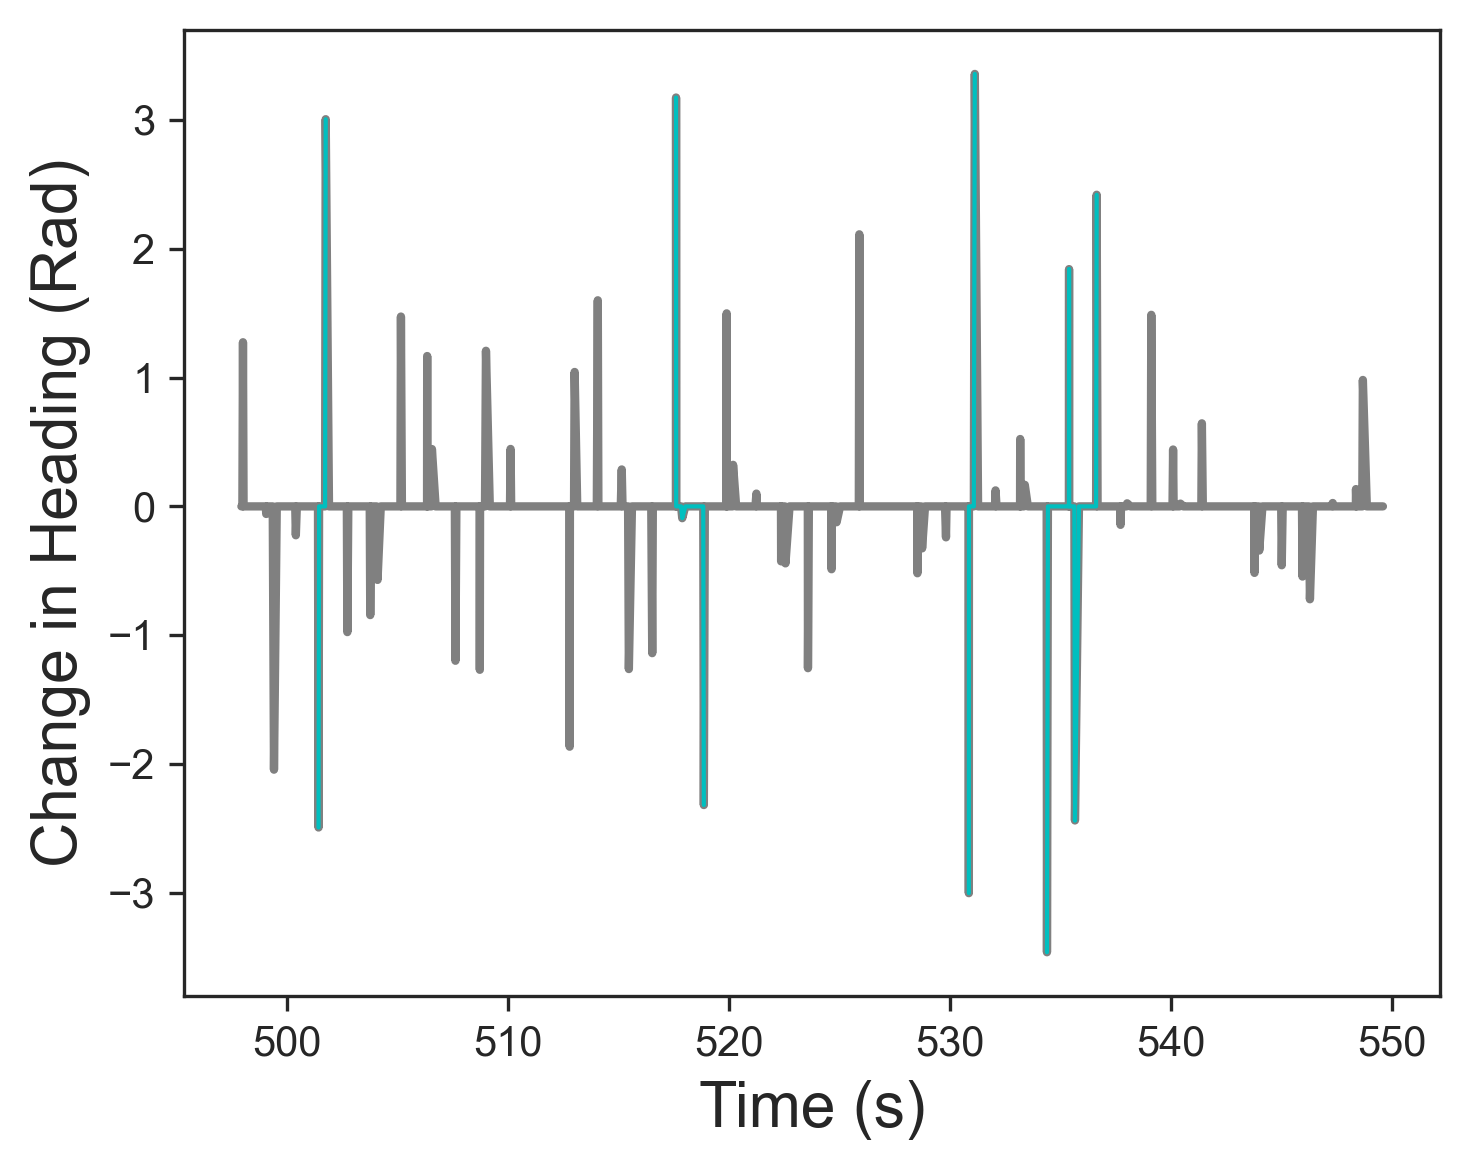

In [14]:
comp_reversals_steep_3_4_20, comp_run_east_video_steep_3_4_20 = comp_call_revs_pos_runs(
    Xcoord_steep_3_4_20, Ycoord_steep_3_4_20, Temp_steep_3_4_20, Time_steep_3_4_20, step=10, heading_plot = "True")


<Figure size 640x480 with 0 Axes>

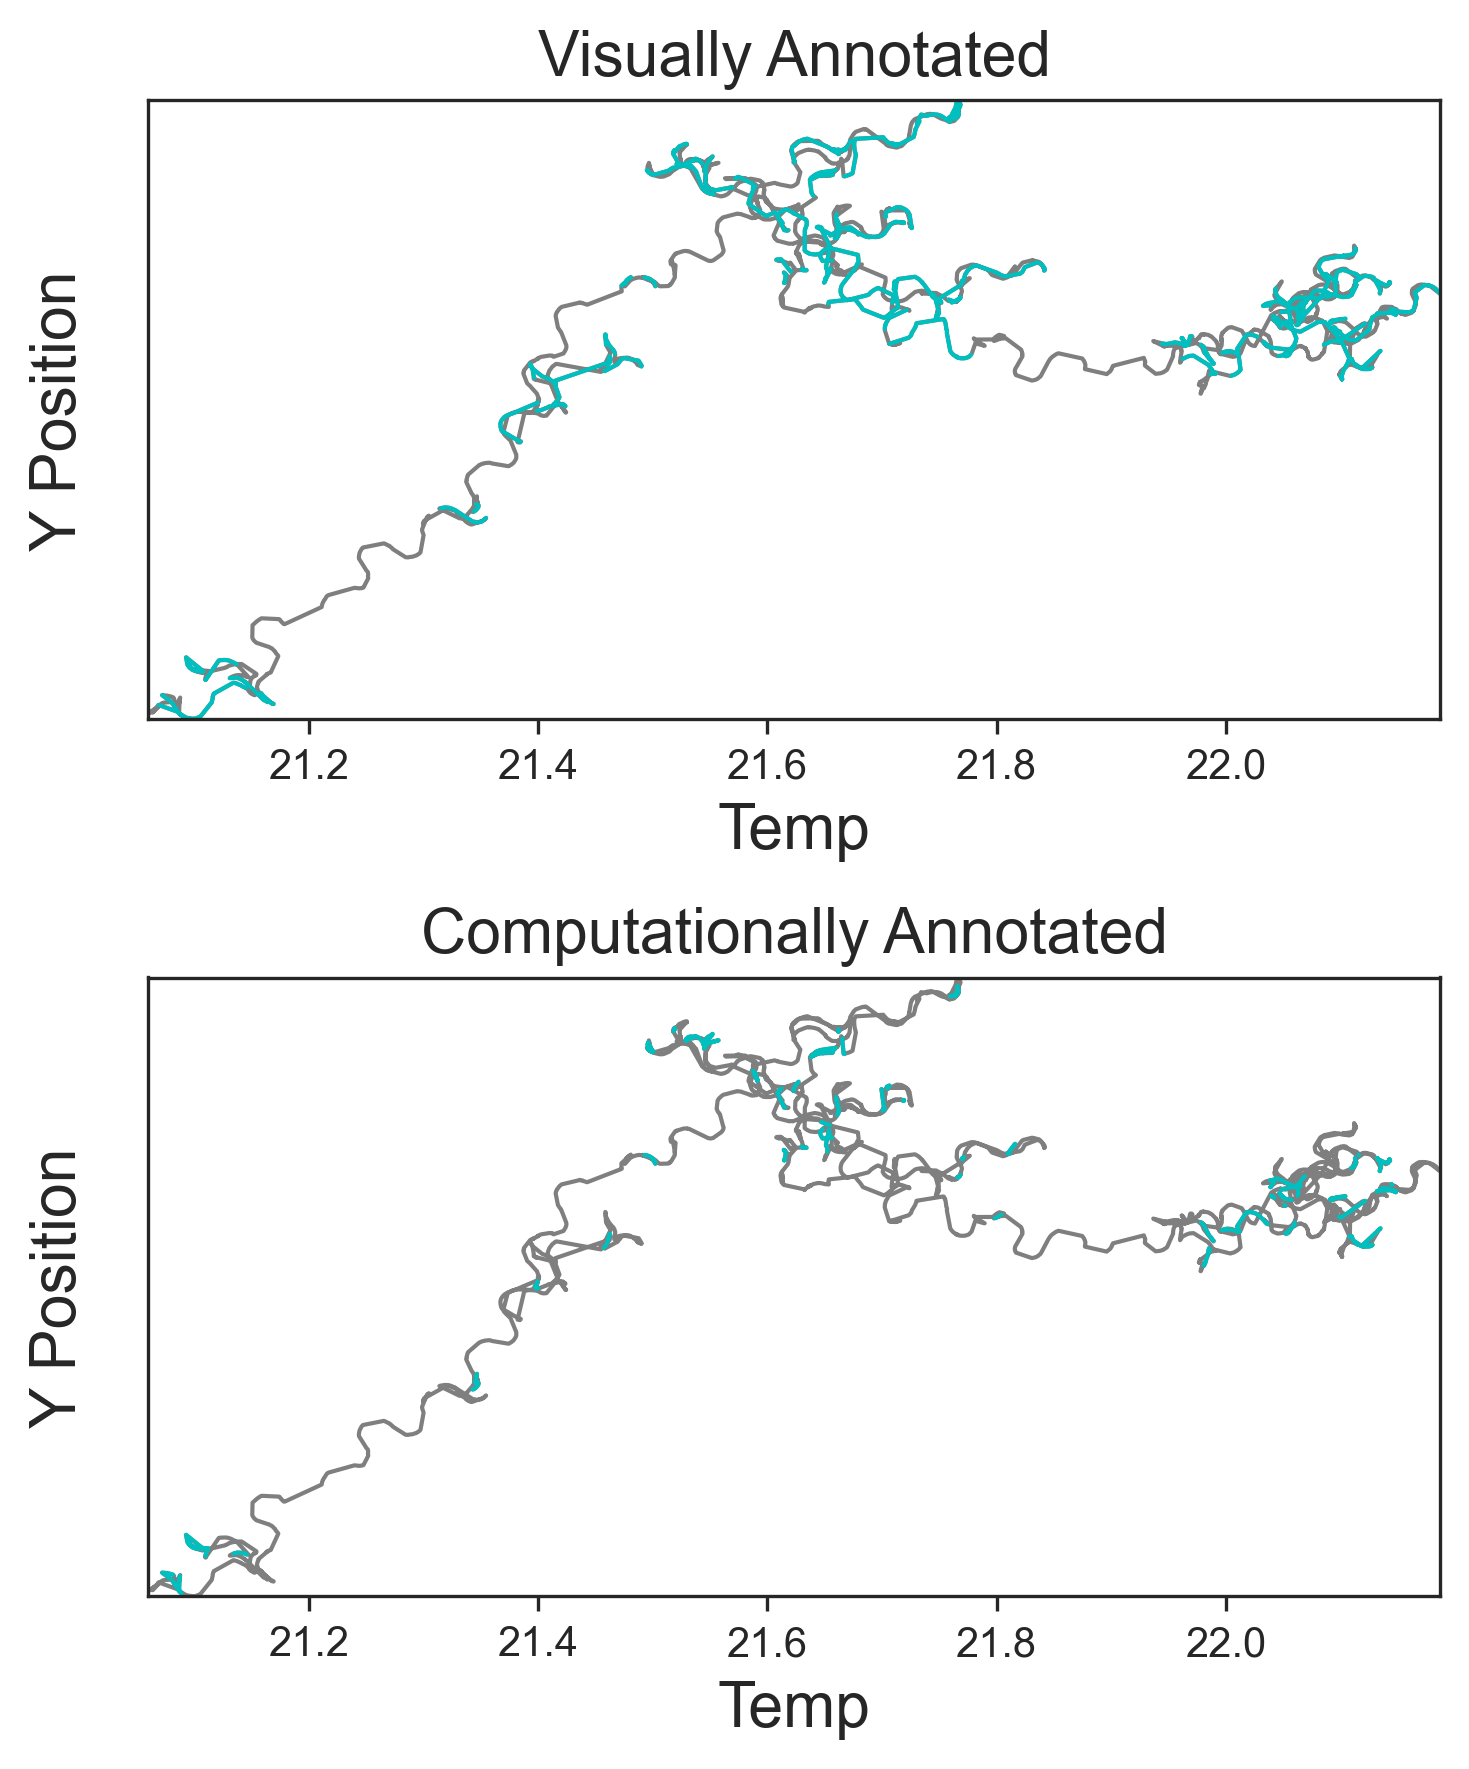

In [16]:
plt.clf()

fig, ax = plt.subplots(nrows = 2, ncols = 1, figsize=(5,6), dpi=300)
ax1 = plt.subplot(2,1,1)

plt.title('Parsed Behavior', fontsize=15)
ax2 = plt.subplot(2,1,2)

ax1.plot(Temp_steep_3_4_20, Ycoord_steep_3_4_20, c='k', lw=1, alpha=0.5)
ax2.plot(Temp_steep_3_4_20, Ycoord_steep_3_4_20, c='k', lw=1, alpha=0.5)

for i in reversals_steep_3_4_20:
    start, stop = find_start_stop(i, Frames_steep_3_4_20)
    ax1.plot(Temp_steep_3_4_20[start:stop], Ycoord_steep_3_4_20[start:stop], c='c', lw=1)
for i in comp_reversals_steep_3_4_20:
    ax2.plot(Temp_steep_3_4_20[i[0]:i[1]], Ycoord_steep_3_4_20[i[0]:i[1]], c='c', lw=1)

ax1.set_xlim(xmin=min(Temp_steep_3_4_20),xmax=max(Temp_steep_3_4_20))
ax1.set_ylim(ymin=min(Ycoord_steep_3_4_20),ymax=max(Ycoord_steep_3_4_20))
ax1.set_ylabel('Y Position', fontsize=15)
ax1.set_xlabel('Temp', fontsize=15)
ax1.set_title('Visually Annotated', fontsize=15)

ax1.tick_params(axis='y', colors='white', labelsize=0)
ax1.tick_params(axis='x', labelsize=10)

ax2.tick_params(axis = 'both', labelsize=15)
ax2.set_xlim(xmin=min(Temp_steep_3_4_20),xmax=max(Temp_steep_3_4_20))
ax2.set_ylim(ymin=min(Ycoord_steep_3_4_20),ymax=max(Ycoord_steep_3_4_20))
ax2.set_ylabel('Y Position', fontsize=15)
ax2.set_xlabel('Temp', fontsize=15)
ax2.set_title('Computationally Annotated', fontsize=15)

ax2.tick_params(axis='y', colors='white', labelsize=0)
ax2.tick_params(axis='x', labelsize=10)

plt.tight_layout()


plt.show()

<Figure size 640x480 with 0 Axes>

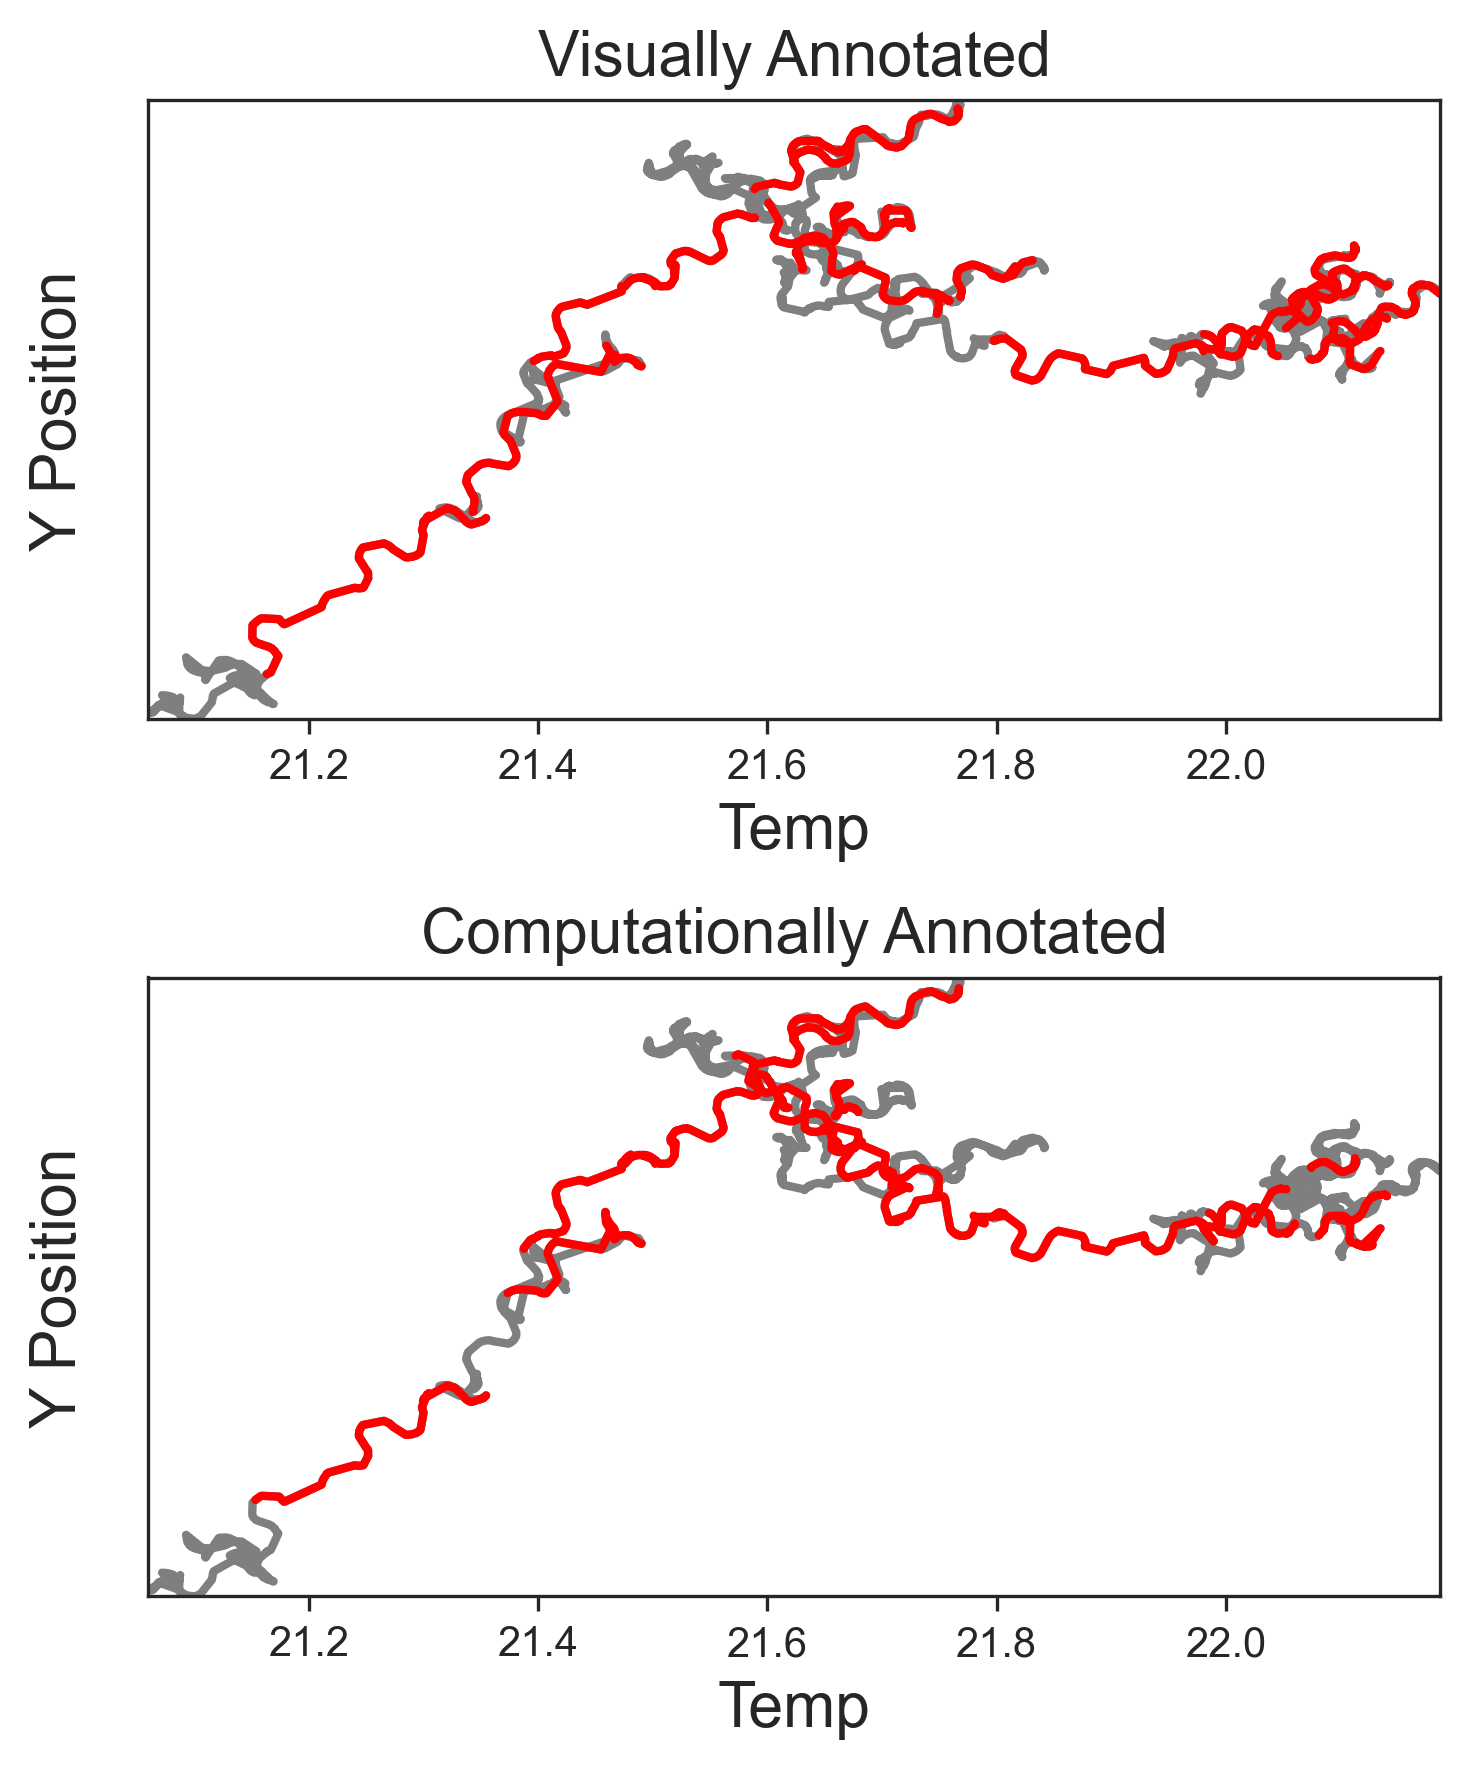

In [17]:
plt.clf()

fig, ax = plt.subplots(nrows = 2, ncols = 1, figsize=(5,6), dpi=300)
ax1 = plt.subplot(2,1,1)

plt.title('Parsed Behavior', fontsize=15)
ax2 = plt.subplot(2,1,2)

ax1.plot(Temp_steep_3_4_20, Ycoord_steep_3_4_20, c='k', lw=2, alpha=0.5)
ax2.plot(Temp_steep_3_4_20, Ycoord_steep_3_4_20, c='k', lw=2, alpha=0.5)

for i in run_east_video_steep_3_4_20:
    start, stop = find_start_stop(i, Frames_steep_3_4_20)
    ax1.plot(Temp_steep_3_4_20[start:stop], Ycoord_steep_3_4_20[start:stop], c='r', lw=2)
for i in comp_run_east_video_steep_3_4_20:
    ax2.plot(Temp_steep_3_4_20[i[0]:i[1]], Ycoord_steep_3_4_20[i[0]:i[1]], c='r', lw=2)

#for i in plateaus_steep_3_4_20:
#    ax1.plot(Temp_steep_3_4_20[i[0]:i[1]], Ycoord_steep_3_4_20[i[0]:i[1]],color='g', lw=2)
#    ax2.plot(Temp_steep_3_4_20[i[0]:i[1]], Ycoord_steep_3_4_20[i[0]:i[1]],color='g', lw=2)
    
    
ax1.set_xlim(xmin=min(Temp_steep_3_4_20),xmax=max(Temp_steep_3_4_20))
ax1.set_ylim(ymin=min(Ycoord_steep_3_4_20),ymax=max(Ycoord_steep_3_4_20))
ax1.set_ylabel('Y Position', fontsize=15)
ax1.set_xlabel('Temp', fontsize=15)
ax1.set_title('Visually Annotated', fontsize=15)

ax1.tick_params(axis='y', colors='white', labelsize=0)
ax1.tick_params(axis='x', labelsize=10)

ax2.tick_params(axis = 'both', labelsize=15)
ax2.set_xlim(xmin=min(Temp_steep_3_4_20),xmax=max(Temp_steep_3_4_20))
ax2.set_ylim(ymin=min(Ycoord_steep_3_4_20),ymax=max(Ycoord_steep_3_4_20))
ax2.set_ylabel('Y Position', fontsize=15)
ax2.set_xlabel('Temp', fontsize=15)
ax2.set_title('Computationally Annotated', fontsize=15)

ax2.tick_params(axis='y', colors='white', labelsize=0)
ax2.tick_params(axis='x', labelsize=10)

plt.tight_layout()


plt.show()

<Figure size 640x480 with 0 Axes>

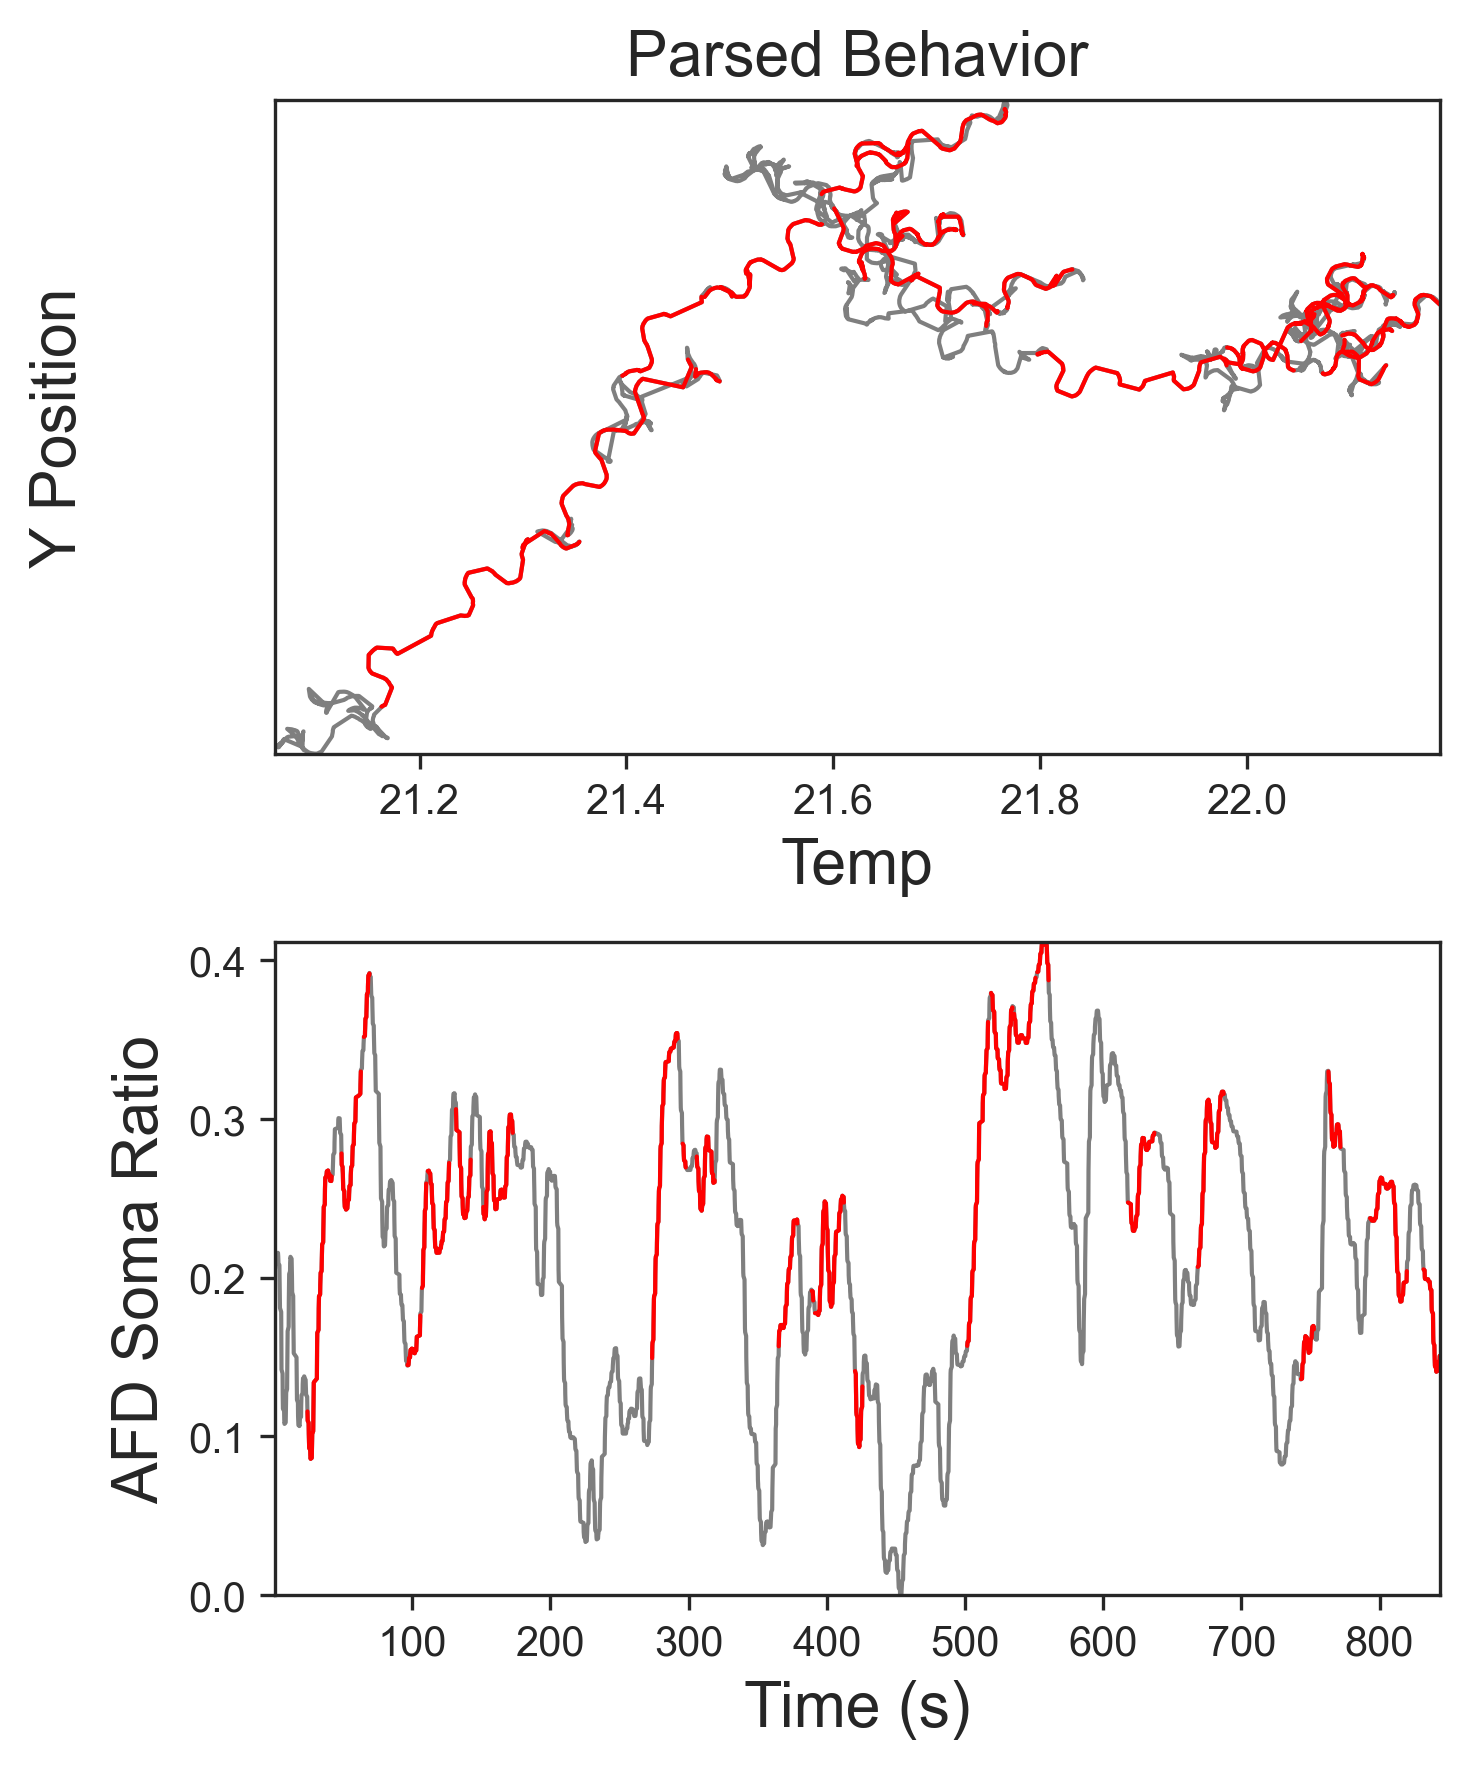

In [ ]:
plt.clf()

fig, ax = plt.subplots(nrows = 2, ncols = 1, figsize=(5,6), dpi=300)
ax1 = plt.subplot(2,1,1)

plt.title('Parsed Behavior', fontsize=15)
ax2 = plt.subplot(2,1,2)

ax1.plot(Temp_steep_3_4_20, Ycoord_steep_3_4_20, c='k', lw=1, alpha=0.5)
ax2.plot(Time_steep_3_4_20, DeltaR_steep_3_4_20, c='k', lw=1, alpha=0.5)
    
for i in run_east_video_steep_3_4_20:
    start, stop = find_start_stop(i, Frames_steep_3_4_20)
    ax1.plot(Temp_steep_3_4_20[start:stop], Ycoord_steep_3_4_20[start:stop], c='r', lw=1)
    ax2.plot(Time_steep_3_4_20[start:stop], DeltaR_steep_3_4_20[start:stop], c='r', lw=1)

ax1.tick_params(axis='y', colors='white')
ax1.tick_params(axis='x', labelsize=10)
ax1.set_xlim(xmin=min(Temp_steep_3_4_20),xmax=max(Temp_steep_3_4_20))
ax1.set_ylim(ymin=min(Ycoord_steep_3_4_20),ymax=max(Ycoord_steep_3_4_20))
ax1.set_ylabel('Y Position', fontsize=15)
ax1.set_xlabel('Temp', fontsize=15)
    
ax2.tick_params(axis = 'both', labelsize=10)
ax2.set_xlim(xmin=min(Time_steep_3_4_20),xmax=max(Time_steep_3_4_20))
ax2.set_ylim(ymin=min(DeltaR_steep_3_4_20),ymax=max(DeltaR_steep_3_4_20))
ax2.set_ylabel('AFD Soma Ratio', fontsize=15)
ax2.set_xlabel('Time (s)', fontsize=15)

plt.tight_layout() 
#plt.savefig('C:/Users/dgmdi/OneDrive - Yale University/Documents/AFD Range of Thermal Perception/Analyses/FreelyMoving_Behavior_Strats_Labeling/3_4_20_PosRuns.svg', dpi=600, bbox_inches='tight')
plt.show()
plt.close()

<Figure size 640x480 with 0 Axes>

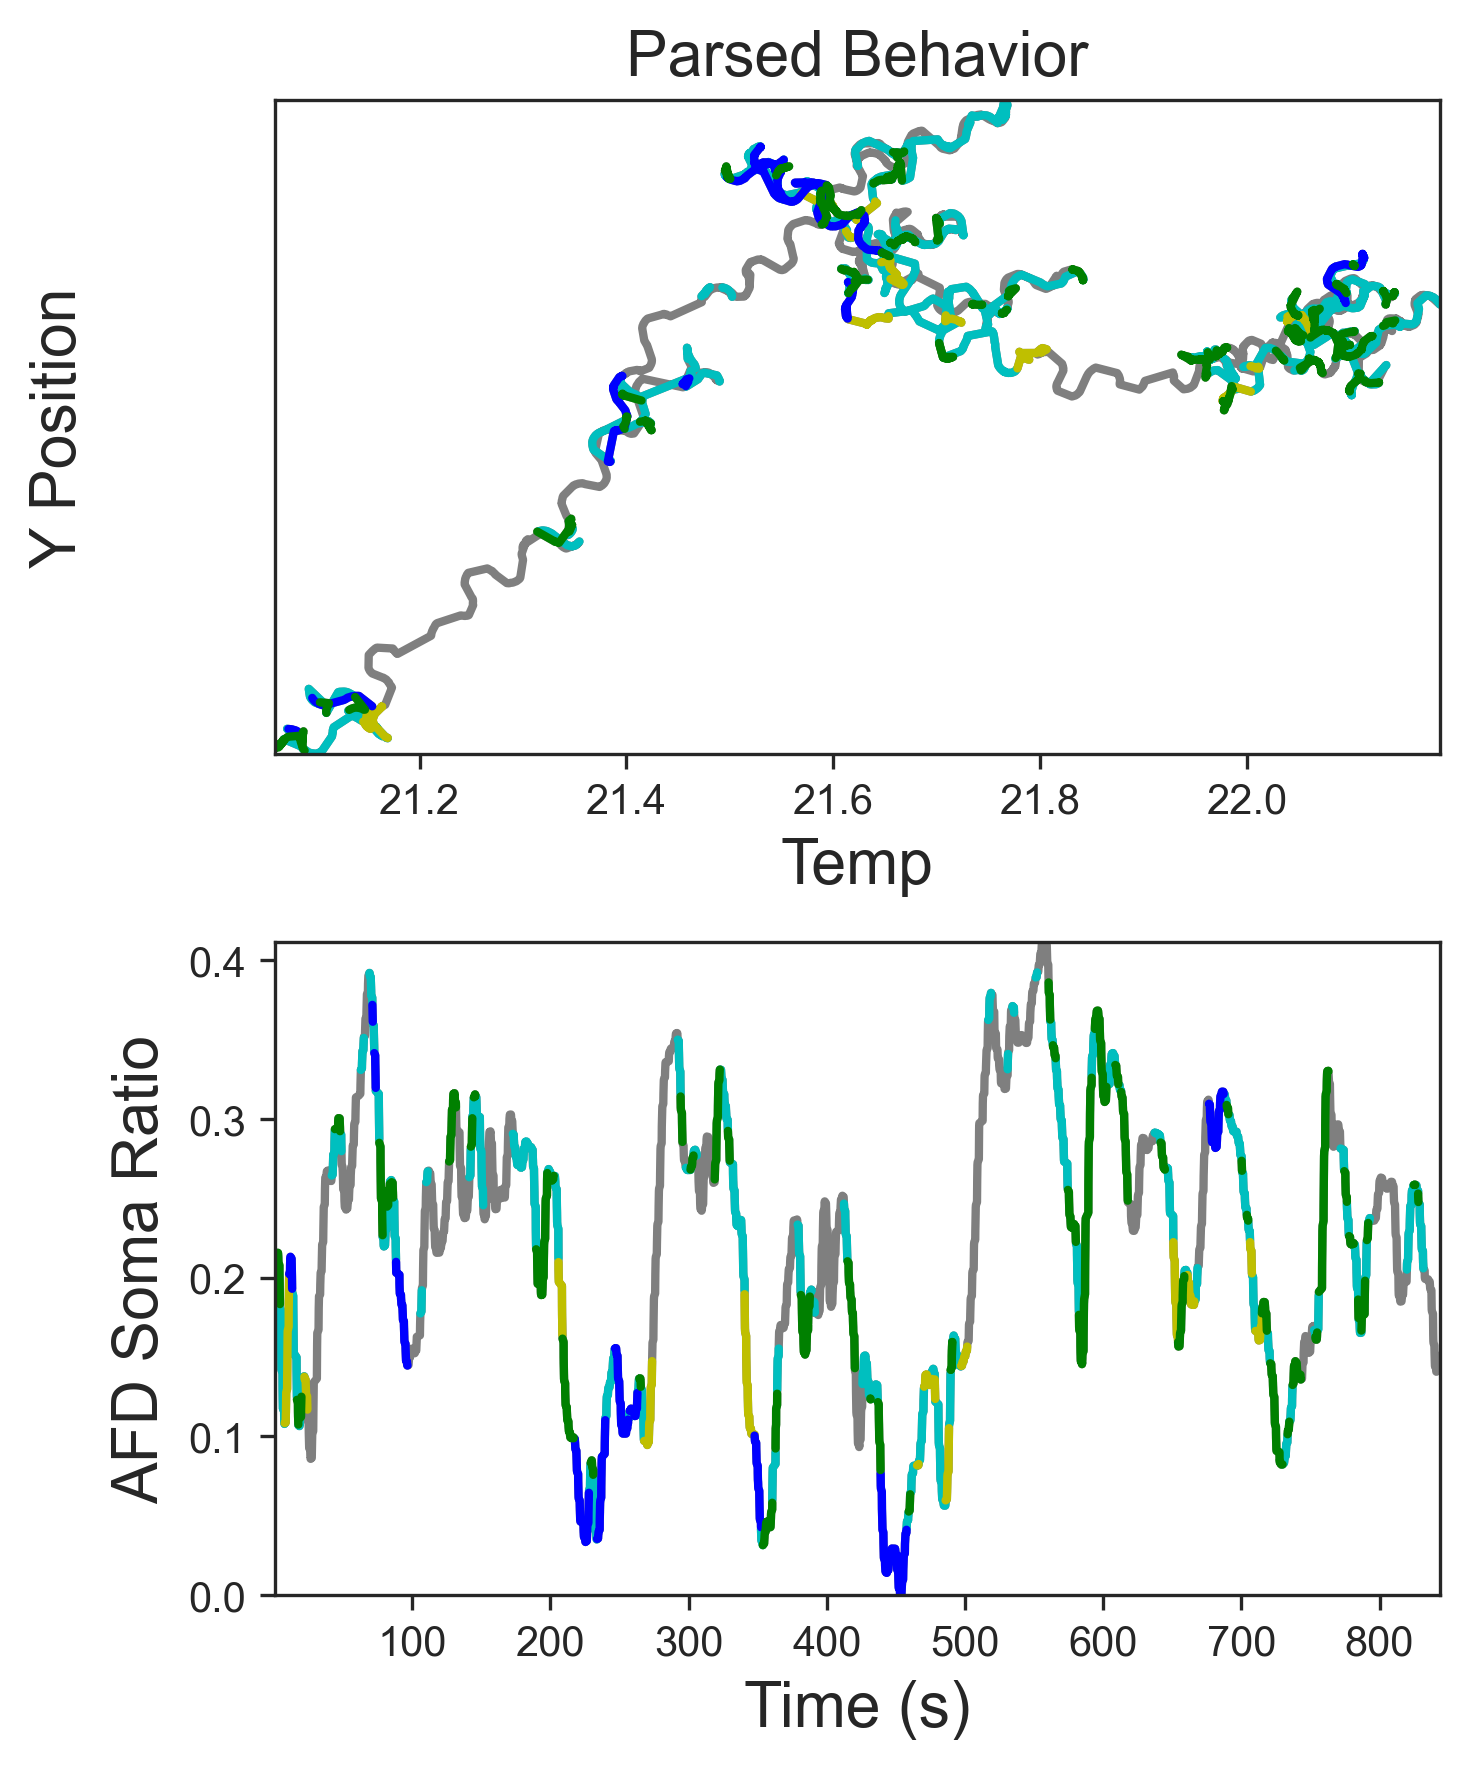

In [ ]:

plt.clf()

fig, ax = plt.subplots(nrows = 2, ncols = 1, figsize=(5,6), dpi=300)
ax1 = plt.subplot(2,1,1)

plt.title('Parsed Behavior', fontsize=15)
ax2 = plt.subplot(2,1,2)

ax1.plot(Temp_steep_3_4_20, Ycoord_steep_3_4_20, c='k', lw=2, alpha=0.5)
ax2.plot(Time_steep_3_4_20, DeltaR_steep_3_4_20, c='k', lw=2, alpha=0.5)

for i in reversals_steep_3_4_20:
    start, stop = find_start_stop(i, Frames_steep_3_4_20)
    ax1.plot(Temp_steep_3_4_20[start:stop], Ycoord_steep_3_4_20[start:stop], c='c', lw=2)
    ax2.plot(Time_steep_3_4_20[start:stop], DeltaR_steep_3_4_20[start:stop], c='c', lw=2)
    
for i in omega_turns_steep_3_4_20:
    start, stop = find_start_stop(i, Frames_steep_3_4_20)
    ax1.plot(Temp_steep_3_4_20[start:stop], Ycoord_steep_3_4_20[start:stop], c='y', lw=2)
    ax2.plot(Time_steep_3_4_20[start:stop], DeltaR_steep_3_4_20[start:stop], c='y', lw=2)
    
#for i in run_east_video_steep_3_4_20:
#    start, stop = find_start_stop(i, Frames_steep_3_4_20)
#    ax1.plot(Temp_steep_3_4_20[start:stop], Ycoord_steep_3_4_20[start:stop], c='r', lw=2)
#    ax2.plot(Time_steep_3_4_20[start:stop], DeltaR_steep_3_4_20[start:stop], c='r', lw=2)
    
for i in run_not_e_video_steep_3_4_20:
    start, stop = find_start_stop(i, Frames_steep_3_4_20)
    ax1.plot(Temp_steep_3_4_20[start:stop], Ycoord_steep_3_4_20[start:stop], c='b', lw=2)
    ax2.plot(Time_steep_3_4_20[start:stop], DeltaR_steep_3_4_20[start:stop], c='b', lw=2)
    
for i in pause_explore_bend_steep_3_4_20:
    start, stop = find_start_stop(i, Frames_steep_3_4_20)
    ax1.plot(Temp_steep_3_4_20[start:stop], Ycoord_steep_3_4_20[start:stop], c='g', lw=2)
    ax2.plot(Time_steep_3_4_20[start:stop], DeltaR_steep_3_4_20[start:stop], c='g', lw=2)

ax1.tick_params(axis='y', colors='white')
ax1.tick_params(axis='x', labelsize=10)
ax1.set_xlim(xmin=min(Temp_steep_3_4_20),xmax=max(Temp_steep_3_4_20))
ax1.set_ylim(ymin=min(Ycoord_steep_3_4_20),ymax=max(Ycoord_steep_3_4_20))
ax1.set_ylabel('Y Position', fontsize=15)
ax1.set_xlabel('Temp', fontsize=15)
    
ax2.tick_params(axis = 'both', labelsize=10)
ax2.set_xlim(xmin=min(Time_steep_3_4_20),xmax=max(Time_steep_3_4_20))
ax2.set_ylim(ymin=min(DeltaR_steep_3_4_20),ymax=max(DeltaR_steep_3_4_20))
ax2.set_ylabel('AFD Soma Ratio', fontsize=15)
ax2.set_xlabel('Time (s)', fontsize=15)

plt.tight_layout() 
#plt.savefig('C:/Users/dgmdi/OneDrive - Yale University/Documents/AFD Range of Thermal Perception/Analyses/FreelyMoving_Behavior_Strats_Labeling/3_4_20_NonPosRuns.svg', dpi=600, bbox_inches='tight')
plt.show()
plt.close()

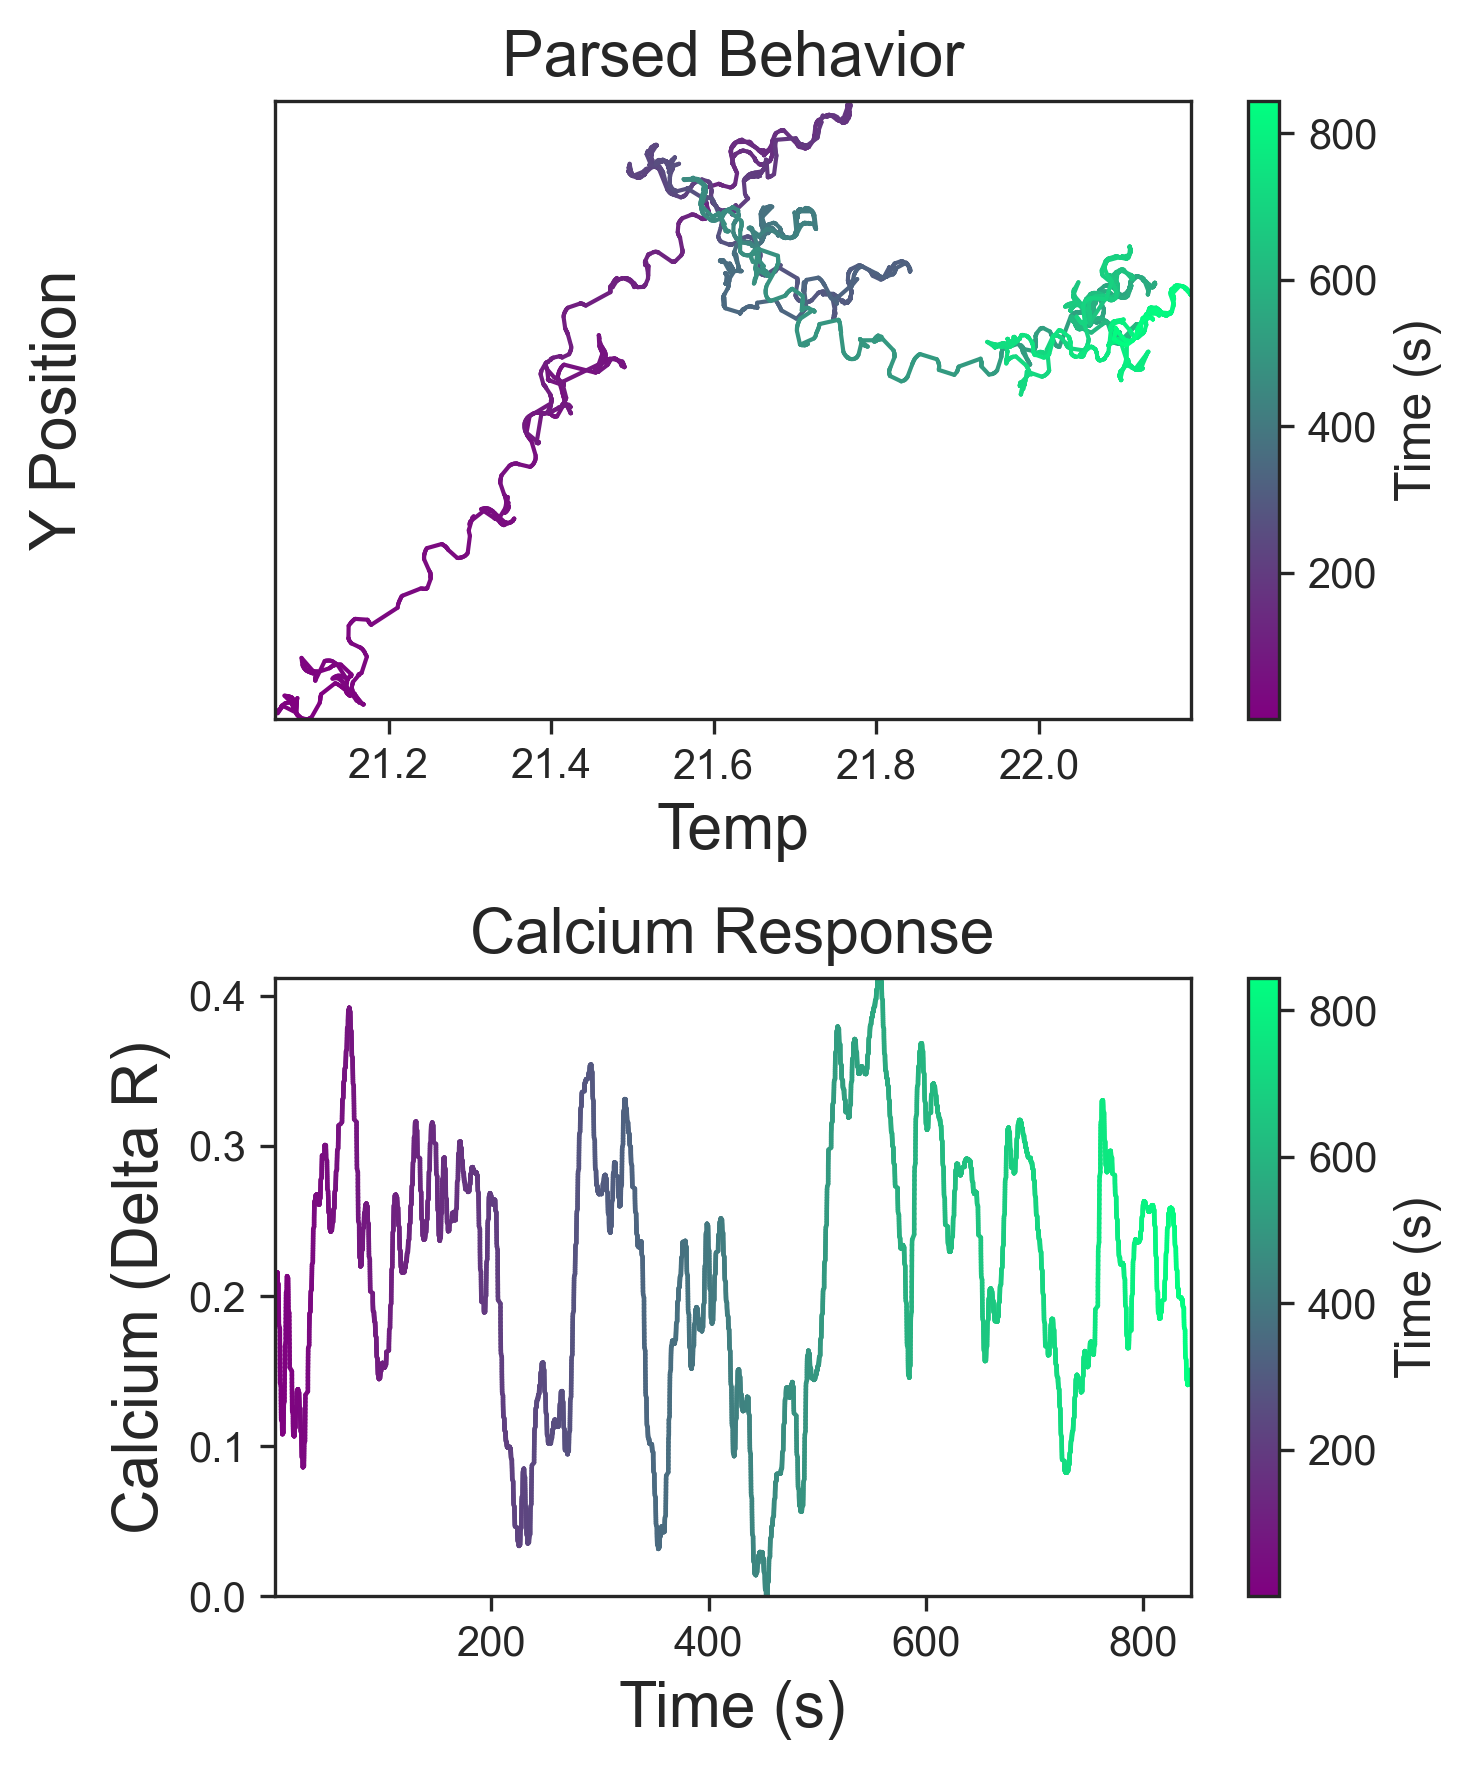

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize, LinearSegmentedColormap
import matplotlib.cm as cm

Time_sorted = np.array(Time_steep_3_4_20)
DeltaR = np.array(DeltaR_steep_3_4_20)

# Normalize time values to range [0, 1] for the color mapping
norm = Normalize(np.min(Time_sorted), np.max(Time_sorted))

# Create custom colormap
purple_to_green_cmap = LinearSegmentedColormap.from_list('PurpleToWinterGreen', ['purple', cm.get_cmap('winter')(1.0)])
plt.register_cmap(cmap=purple_to_green_cmap)
cmap = plt.get_cmap('PurpleToWinterGreen')

# --- Plotting Setup ---
# Create 2 subplots (ax1 = Top, ax2 = Bottom)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(5, 6), dpi=300)

# ==========================================
# PLOT 1: Behavior (Temp vs Y Position)
# ==========================================
points_beh = np.array([Temp_steep_3_4_20, Ycoord_steep_3_4_20]).T.reshape(-1, 1, 2)
segments_beh = np.concatenate([points_beh[:-1], points_beh[1:]], axis=1)

# Create LineCollection
lc1 = LineCollection(segments_beh, cmap=cmap, norm=norm)
lc1.set_array(Time_sorted[:-1])
lc1.set_linewidth(1)
lc1.set_capstyle('round')
lc1.set_joinstyle('round')

ax1.add_collection(lc1)
ax1.set_title('Parsed Behavior', fontsize=15)
ax1.set_xlim(np.min(Temp_steep_3_4_20), np.max(Temp_steep_3_4_20))
ax1.set_ylim(np.min(Ycoord_steep_3_4_20), np.max(Ycoord_steep_3_4_20))
ax1.set_xlabel('Temp', fontsize=15)
ax1.set_ylabel('Y Position', fontsize=15)
ax1.tick_params(axis='y', colors='white') 

# Add colorbar to top plot
cbar1 = fig.colorbar(lc1, ax=ax1)
cbar1.set_label('Time (s)', fontsize=12)

# ==========================================
# PLOT 2: Calcium (Time vs DeltaR)
# ==========================================
points_ca = np.array([Time_sorted, DeltaR]).T.reshape(-1, 1, 2)
segments_ca = np.concatenate([points_ca[:-1], points_ca[1:]], axis=1)

# Create LineCollection (Reusing same cmap and norm)
lc2 = LineCollection(segments_ca, cmap=cmap, norm=norm)
lc2.set_array(Time_sorted[:-1])
lc2.set_linewidth(1.1)

lc2.set_capstyle('round')
lc2.set_joinstyle('round')

ax2.add_collection(lc2)
ax2.set_title('Calcium Response', fontsize=15)
ax2.set_xlim(np.min(Time_sorted), np.max(Time_sorted))
y_range = np.max(DeltaR) - np.min(DeltaR)
# optional: ax2.set_ylim(np.min(DeltaR) - 0.1*y_range, np.max(DeltaR) + 0.01*y_range)
ax2.set_ylim(ymin=min(DeltaR),ymax=max(DeltaR))
ax2.set_xlabel('Time (s)', fontsize=15)
ax2.set_ylabel('Calcium (Delta R)', fontsize=15)

# Add colorbar to bottom plot 
cbar2 = fig.colorbar(lc2, ax=ax2)
cbar2.set_label('Time (s)', fontsize=12)

plt.tight_layout()
plt.savefig('C:/Users/dgmdi/OneDrive - Yale University/Documents/AFD Range of Thermal Perception/Analyses/FreelyMoving_Behavior_Strats_Labeling/3_4_20_TimeHeatMap.svg', dpi=600, bbox_inches='tight')
plt.show()

<Figure size 640x480 with 0 Axes>

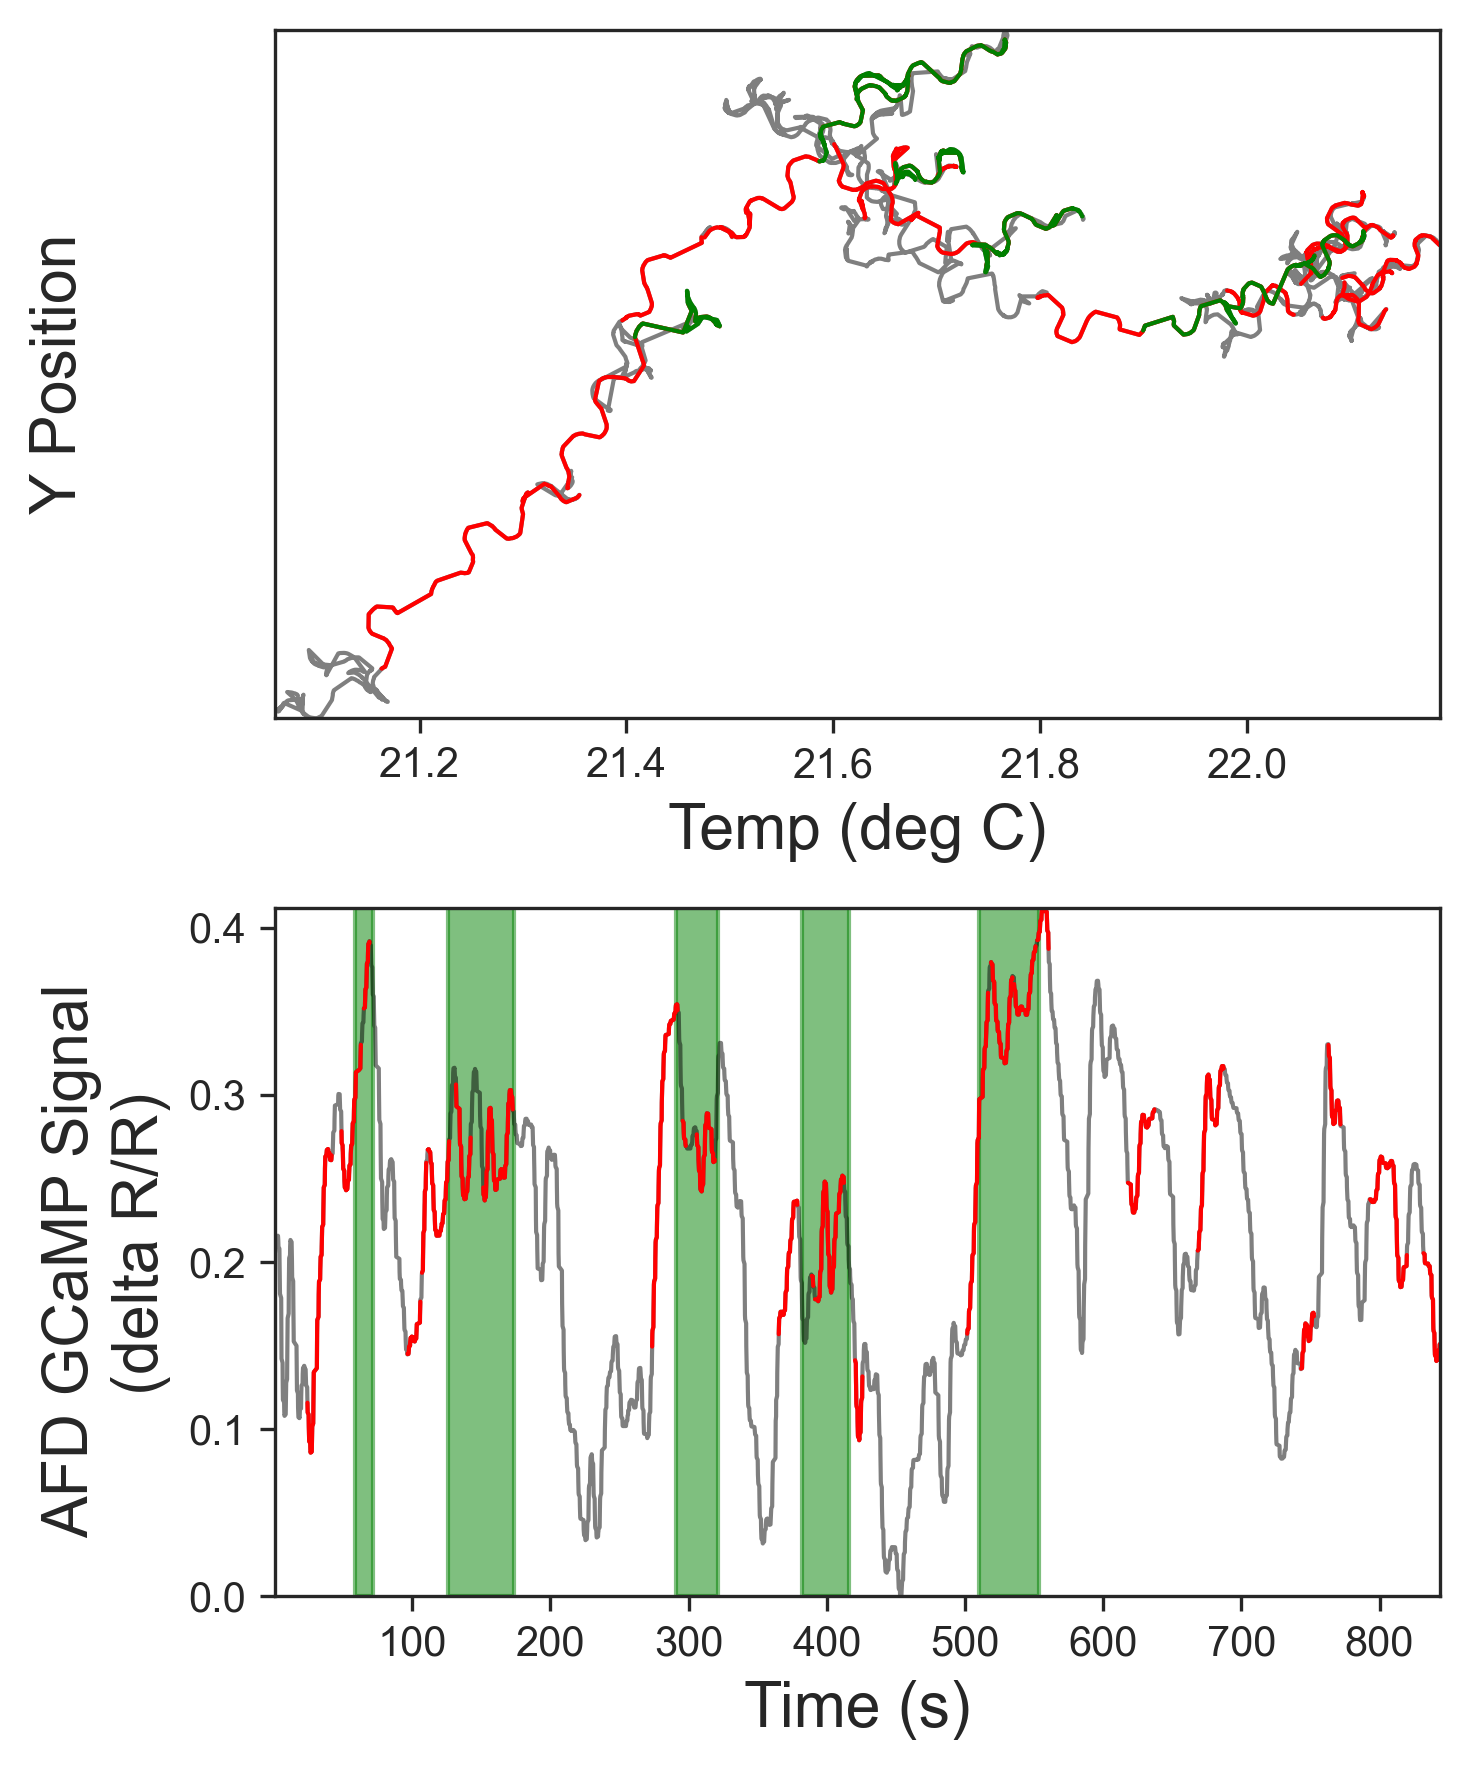

In [21]:
plt.clf()

fig, ax = plt.subplots(nrows = 2, ncols = 1, figsize=(5,6),dpi=300)
ax2 = plt.subplot(2,1,1)

ax1 = plt.subplot(2,1,2) ##
#plt.title('Visually Called Plateaus', fontsize=15)

ax2.plot(Temp_steep_3_4_20, Ycoord_steep_3_4_20, c='k', lw=1, alpha=0.5)
ax1.plot(Time_steep_3_4_20, DeltaR_steep_3_4_20, c='k', lw=1, alpha=0.5)

for i in run_east_video_steep_3_4_20:
    start, stop = find_start_stop(i, Frames_steep_3_4_20)
    ax2.plot(Temp_steep_3_4_20[start:stop], Ycoord_steep_3_4_20[start:stop], c='r', lw=1)
    ax1.plot(Time_steep_3_4_20[start:stop], DeltaR_steep_3_4_20[start:stop], c='r', lw=1)
for i in plateaus_steep_3_4_20:
    ax2.plot(Temp_steep_3_4_20[i[0]:i[1]],Ycoord_steep_3_4_20[i[0]:i[1]],c='g', lw=1)
    
ax2.tick_params(axis='y', colors='white')
ax2.tick_params(axis='x', labelsize=10)
ax2.set_xlim(xmin=min(Temp_steep_3_4_20),xmax=max(Temp_steep_3_4_20))
ax2.set_ylim(ymin=min(Ycoord_steep_3_4_20),ymax=max(Ycoord_steep_3_4_20))
ax2.set_ylabel('Y Position', fontsize=15)
ax2.set_xlabel('Temp (deg C)', fontsize=15)
    
for i in plateaus_steep_3_4_20:
    ax1.axvspan(Time_steep_3_4_20[i[0]],Time_steep_3_4_20[i[1]],alpha=0.5,color='green')
    
ax1.tick_params(axis = 'both', labelsize=10)
ax1.set_xlim(xmin=min(Time_steep_3_4_20),xmax=max(Time_steep_3_4_20))
ax1.set_ylim(ymin=min(DeltaR_steep_3_4_20),ymax=max(DeltaR_steep_3_4_20))
ax1.set_ylabel('AFD GCaMP Signal \n (delta R/R)', fontsize=15)
ax1.set_xlabel('Time (s)', fontsize=15)

plt.tight_layout()
#plt.savefig('C:/Users/dgmdi/OneDrive - Yale University/Documents/AFD Range of Thermal Perception/Analyses/FreelyMoving_Behavior_Strats_Labeling/3_4_20_PosRuns_wPlateaus.svg', dpi=600, bbox_inches='tight')
#plt.savefig('xxx.png', dpi=600, bbox_inches='tight')
#plt.savefig('xxx.svg', dpi=600, bbox_inches='tight')

plt.show()

<Figure size 640x480 with 0 Axes>

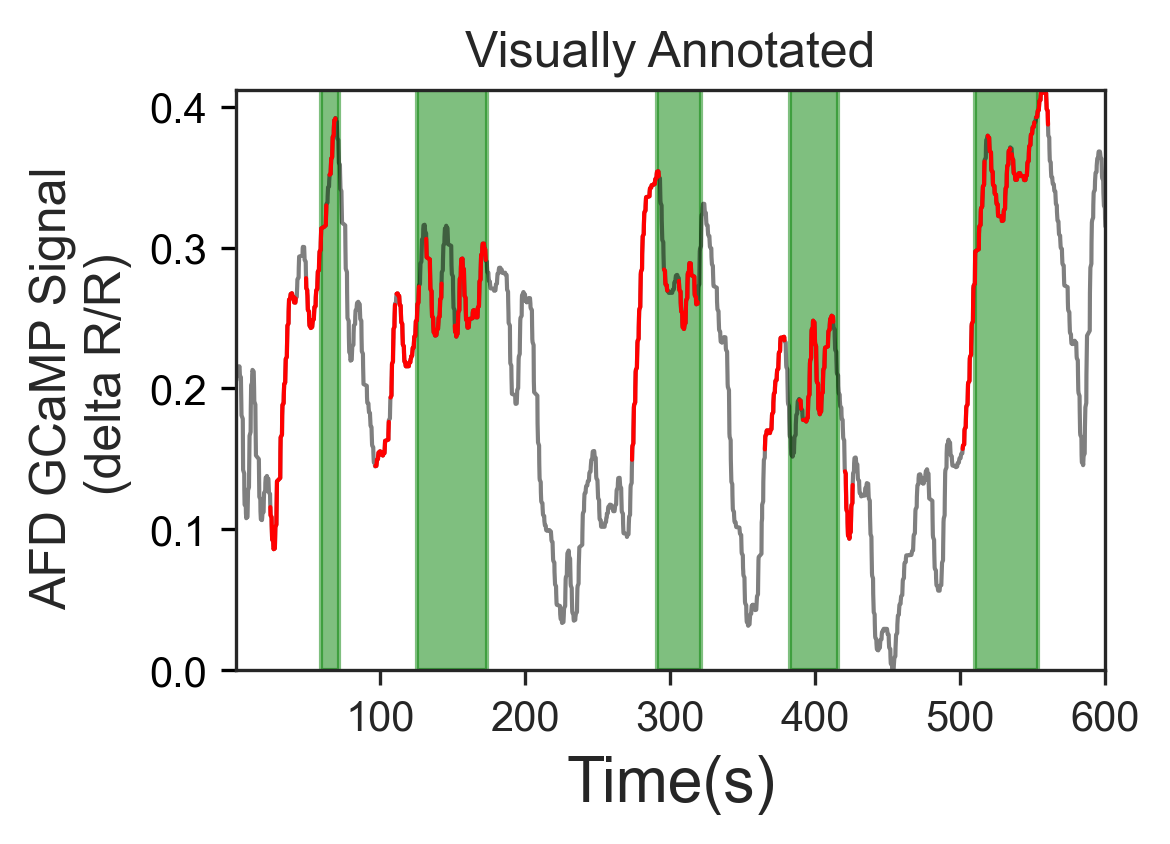

In [ ]:
plt.clf()

fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize=(4,5), dpi=300)
ax1 = plt.subplot(2,1,1)

plt.title('Parsed Behavior', fontsize=12)

ax1.plot(Time_steep_3_4_20, DeltaR_steep_3_4_20, c='k', lw=1, alpha=0.5)

for i in run_east_video_steep_3_4_20:
    start, stop = find_start_stop(i, Frames_steep_3_4_20)
    ax1.plot(Time_steep_3_4_20[start:stop], DeltaR_steep_3_4_20[start:stop], c='r', lw=1)

for i in plateaus_steep_3_4_20:
    ax1.axvspan(Time_steep_3_4_20[i[0]],Time_steep_3_4_20[i[1]],alpha=0.5,color='green')
    
    
ax1.set_xlim(xmin=min(Time_steep_3_4_20),xmax=max(Time_steep_3_4_20))
ax1.set_xlim(xmin=min(Time_steep_3_4_20), xmax=next((t for t in Time_steep_3_4_20 if t >= 600), None) )
ax1.set_ylim(ymin=min(DeltaR_steep_3_4_20),ymax=max(DeltaR_steep_3_4_20))
ax1.set_ylabel('AFD GCaMP Signal \n (delta R/R)', fontsize=12)
ax1.set_xlabel('Time(s)', fontsize=15)
ax1.set_title('Visually Annotated', fontsize=12)

ax1.tick_params(axis='y', colors='black', labelsize=10)
ax1.tick_params(axis='x', labelsize=10)

plt.tight_layout()
#plt.savefig('C:/Users/dgmdi/OneDrive - Yale University/Documents/AFD Range of Thermal Perception/Analyses/FreelyMoving_Behavior_Strats_Labeling/3_4_20_CaPlateaus.svg', dpi=600, bbox_inches='tight')
plt.show()

## 3_5_20

In [35]:
reversals_steep_3_5_20 = [
    (240,255),(560,575),(625,645),(835,865),(1385,1400),(1695,1760),(1905,1940),(2180,2200),(2240,2255),(2285,2295),(2835,2870),
    (2880,2900),(3085,3135),(3180,3255),(3295,3315),(3390,3435),(3630,3650),(3720,3740),(3795,3820),(4000,4050),(4110,4125),(4140,4155),
    (4215,4245),(4275,4335),(4395,4425),(4455,4500),(4520,4560),(4880,4905),(5505,5525),(5630,5640),(5700,5715),(5770,5790),(6030,6055),
    (6420,6435),(7800,7815),(7850,7870),(7905,7950),(8040,8070),(8280,8315),(8365,8390),(8975,9035),(9065,9090),(9100,9120),(9180,9195),
    (9420,9435),(9705,9780),(9910,9940),(9960,9975),(10045,10170),(10480,10490),(10605,10630),(10845,10885),(11075,11090),(13110,13140),
    (13385,13410),(13430,13465),(14280,14295),(14700,14730),(14830,14840)
]

omega_turns_steep_3_5_20 = [
    (3315,3335),(3435,3615),(4335,4355),(4425,4455),(4560,4695),(8070,8100),(9120,9150),(9780,9830),(13465,13520),
]

run_east_video_steep_3_5_20 = [
    (590,625),(645,835),(865,1275),(1295,1385),(1400,1695),(1760,1905),(1940,2100),(2120,2180),(2500,2835),(2870,2880),(2900,2990),(3050,3085),
    (3135,3180),(3615,3630),(6315,6420),(6435,6915),(7240,7800),(9225,9420),(9435,9705),(10730,10845),(12375,12890),(12915,13110),(13140,13385),
    (13800,14240),(14515,14700),(14895,14985)
]

run_not_e_video_steep_3_5_20 = [
    (1,25),(90,200),(225,240),(255,560),(2255,2285),(2295,2330), (2345,2380), (2390,2490),(3255,3295),(3335,3390),(3670,3720),(3770,3795),(3820,3905),(3925,4000),
    (4050,4110),(4170,4215),(4355,4395),(4765,4880),(5000,5235),(5370,5505),(5525,5630),(5640,5700),(5715,5770),(5790,5930),(5940,6030),(6055,6300),
    (6915,6950),(6950,7230),(7230,7240),(7870,7905),(8165,8280),(8315,8365),(8390,8780),(8800,8975),(9150,9180),(9830,9910),(9975,9990),(9990,10045),
    (10210,10480),(10490,10605),(10630,10675),(10885,11075),(11090,11075),(11090,11300),(11300,11335),(11335,11370),(11400,11440),(11460,11590),
    (11600,11775),(11775,11830),(11830,12335),(12335,12375),(13520,13770),(13770,13800),(14260,14280),(14335,14505),(14730,14830),(14840,14895)
]

pause_explore_bend_steep_3_5_20 = [
    (25,90),(200,225),(575,590),(1275,1295),(2100,2120),(2200,2240),(2330,2345),(2389,2390),(2490,2500),(2990,3050),(3650,3670),(3740,3770),
    (3905,3925),(4125,4140),(4155,4170),(4245,4275),(4500,4520),(4695,4765),(4905,5000),(5235,5275),(5275,5305),(5305,5370),(5930,5940),
    (6300,6315),(7815,7850),(7950,8040),(8100,8165),(9035,9065),(9090,9100),(9195,9225),(9940,9960),(10170,10210),(10675,10730),
    (11370,11400),(11440,11460),(11590,11600),(12890,12915),(13410,13430),(14240,14260),(14295,14335),(14505,14515)
]

plateaus_steep_3_5_20 = [(1375,2200),(7450,7810),(9500,10000),(12800,13320), (13800,14200)
                         ]

In [36]:
source = "csv"
if source == "csv":
    # Load the CSV file
    pref = "C:/Users/dgmdi\OneDrive - Yale University/Documents/AFD Range of Thermal Perception/"
    file_path = pref + "Steep_5p5_3_5_20_1_data.csv"  
    df = pd.read_csv(file_path)

    # Store each column in its own list
    Ycoord_steep_3_5_20       = df['y'].tolist()
    Xcoord_steep_3_5_20       = df['x'].tolist()
    Temp_steep_3_5_20    = df['Temp'].tolist()
    Time_steep_3_5_20    = df['Time'].tolist()
    Frames_steep_3_5_20  = df['frames'].tolist()
    DeltaR_steep_3_5_20 = df['Delta_R'].tolist()

In [37]:
comp_reversals_steep_3_5_20, comp_run_east_video_steep_3_5_20 = comp_call_revs_pos_runs(
    Xcoord_steep_3_5_20, Ycoord_steep_3_5_20, Temp_steep_3_5_20, Time_steep_3_5_20, step=10)


<Figure size 640x480 with 0 Axes>

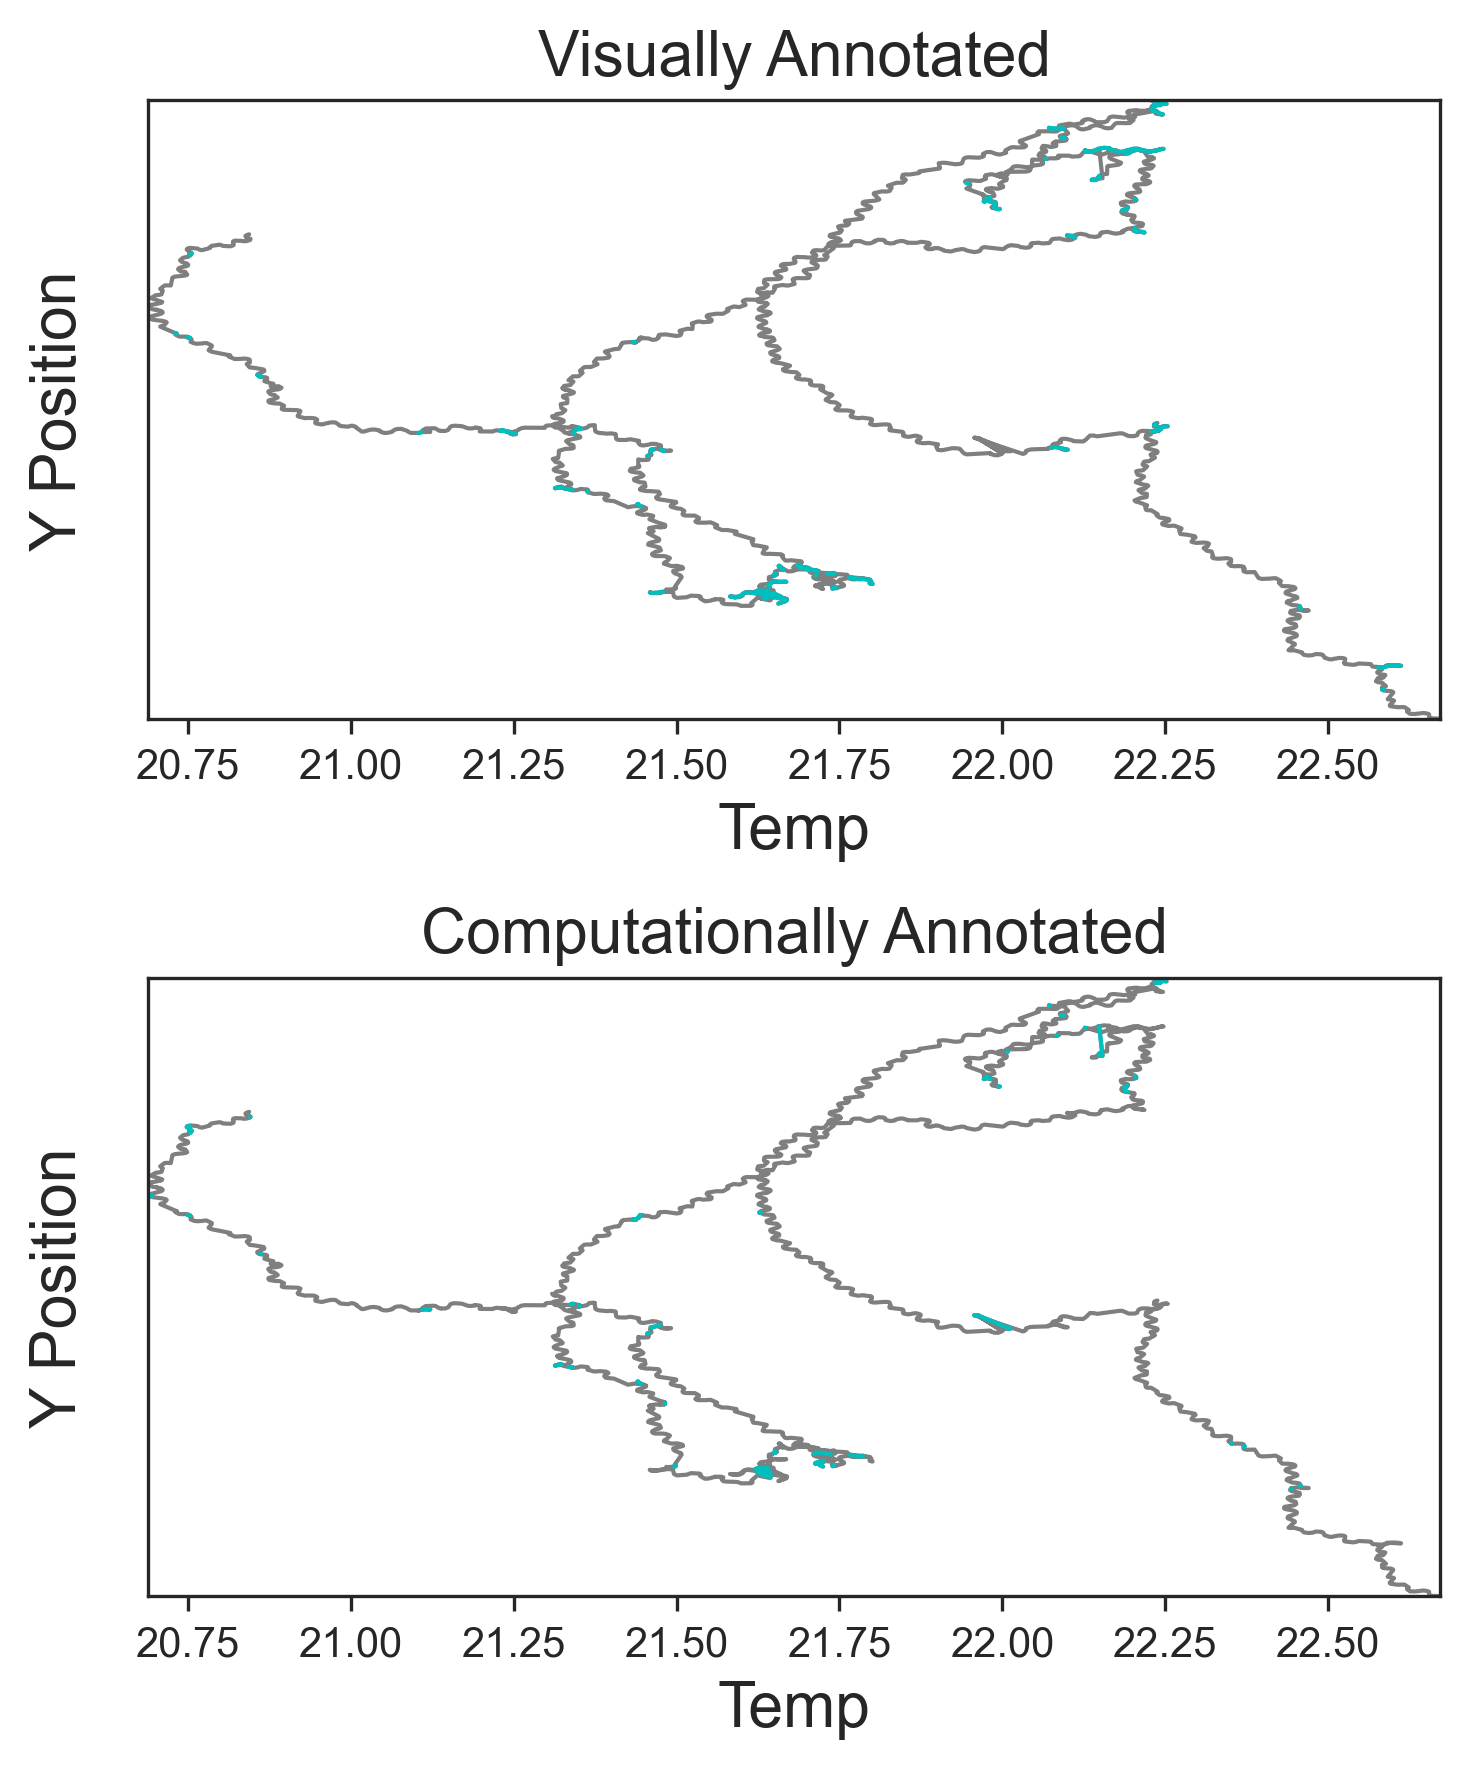

In [38]:
plt.clf()

fig, ax = plt.subplots(nrows = 2, ncols = 1, figsize=(5,6), dpi=300)
ax1 = plt.subplot(2,1,1)

plt.title('Parsed Behavior', fontsize=15)
ax2 = plt.subplot(2,1,2)

ax1.plot(Temp_steep_3_5_20, Ycoord_steep_3_5_20, c='k', lw=1, alpha=0.5)
ax2.plot(Temp_steep_3_5_20, Ycoord_steep_3_5_20, c='k', lw=1, alpha=0.5)

for i in reversals_steep_3_5_20:
    start, stop = find_start_stop(i, Frames_steep_3_5_20)
    ax1.plot(Temp_steep_3_5_20[start:stop], Ycoord_steep_3_5_20[start:stop], c='c', lw=1)
for i in comp_reversals_steep_3_5_20:
    ax2.plot(Temp_steep_3_5_20[i[0]:i[1]], Ycoord_steep_3_5_20[i[0]:i[1]], c='c', lw=1)

ax1.set_xlim(xmin=min(Temp_steep_3_5_20),xmax=max(Temp_steep_3_5_20))
ax1.set_ylim(ymin=min(Ycoord_steep_3_5_20),ymax=max(Ycoord_steep_3_5_20))
ax1.set_ylabel('Y Position', fontsize=15)
ax1.set_xlabel('Temp', fontsize=15)
ax1.set_title('Visually Annotated', fontsize=15)

ax1.tick_params(axis='y', colors='white', labelsize=0)
ax1.tick_params(axis='x', labelsize=10)

ax2.tick_params(axis = 'both', labelsize=15)
ax2.set_xlim(xmin=min(Temp_steep_3_5_20),xmax=max(Temp_steep_3_5_20))
ax2.set_ylim(ymin=min(Ycoord_steep_3_5_20),ymax=max(Ycoord_steep_3_5_20))
ax2.set_ylabel('Y Position', fontsize=15)
ax2.set_xlabel('Temp', fontsize=15)
ax2.set_title('Computationally Annotated', fontsize=15)

ax2.tick_params(axis='y', colors='white', labelsize=0)
ax2.tick_params(axis='x', labelsize=10)

plt.tight_layout()


plt.show()

<Figure size 640x480 with 0 Axes>

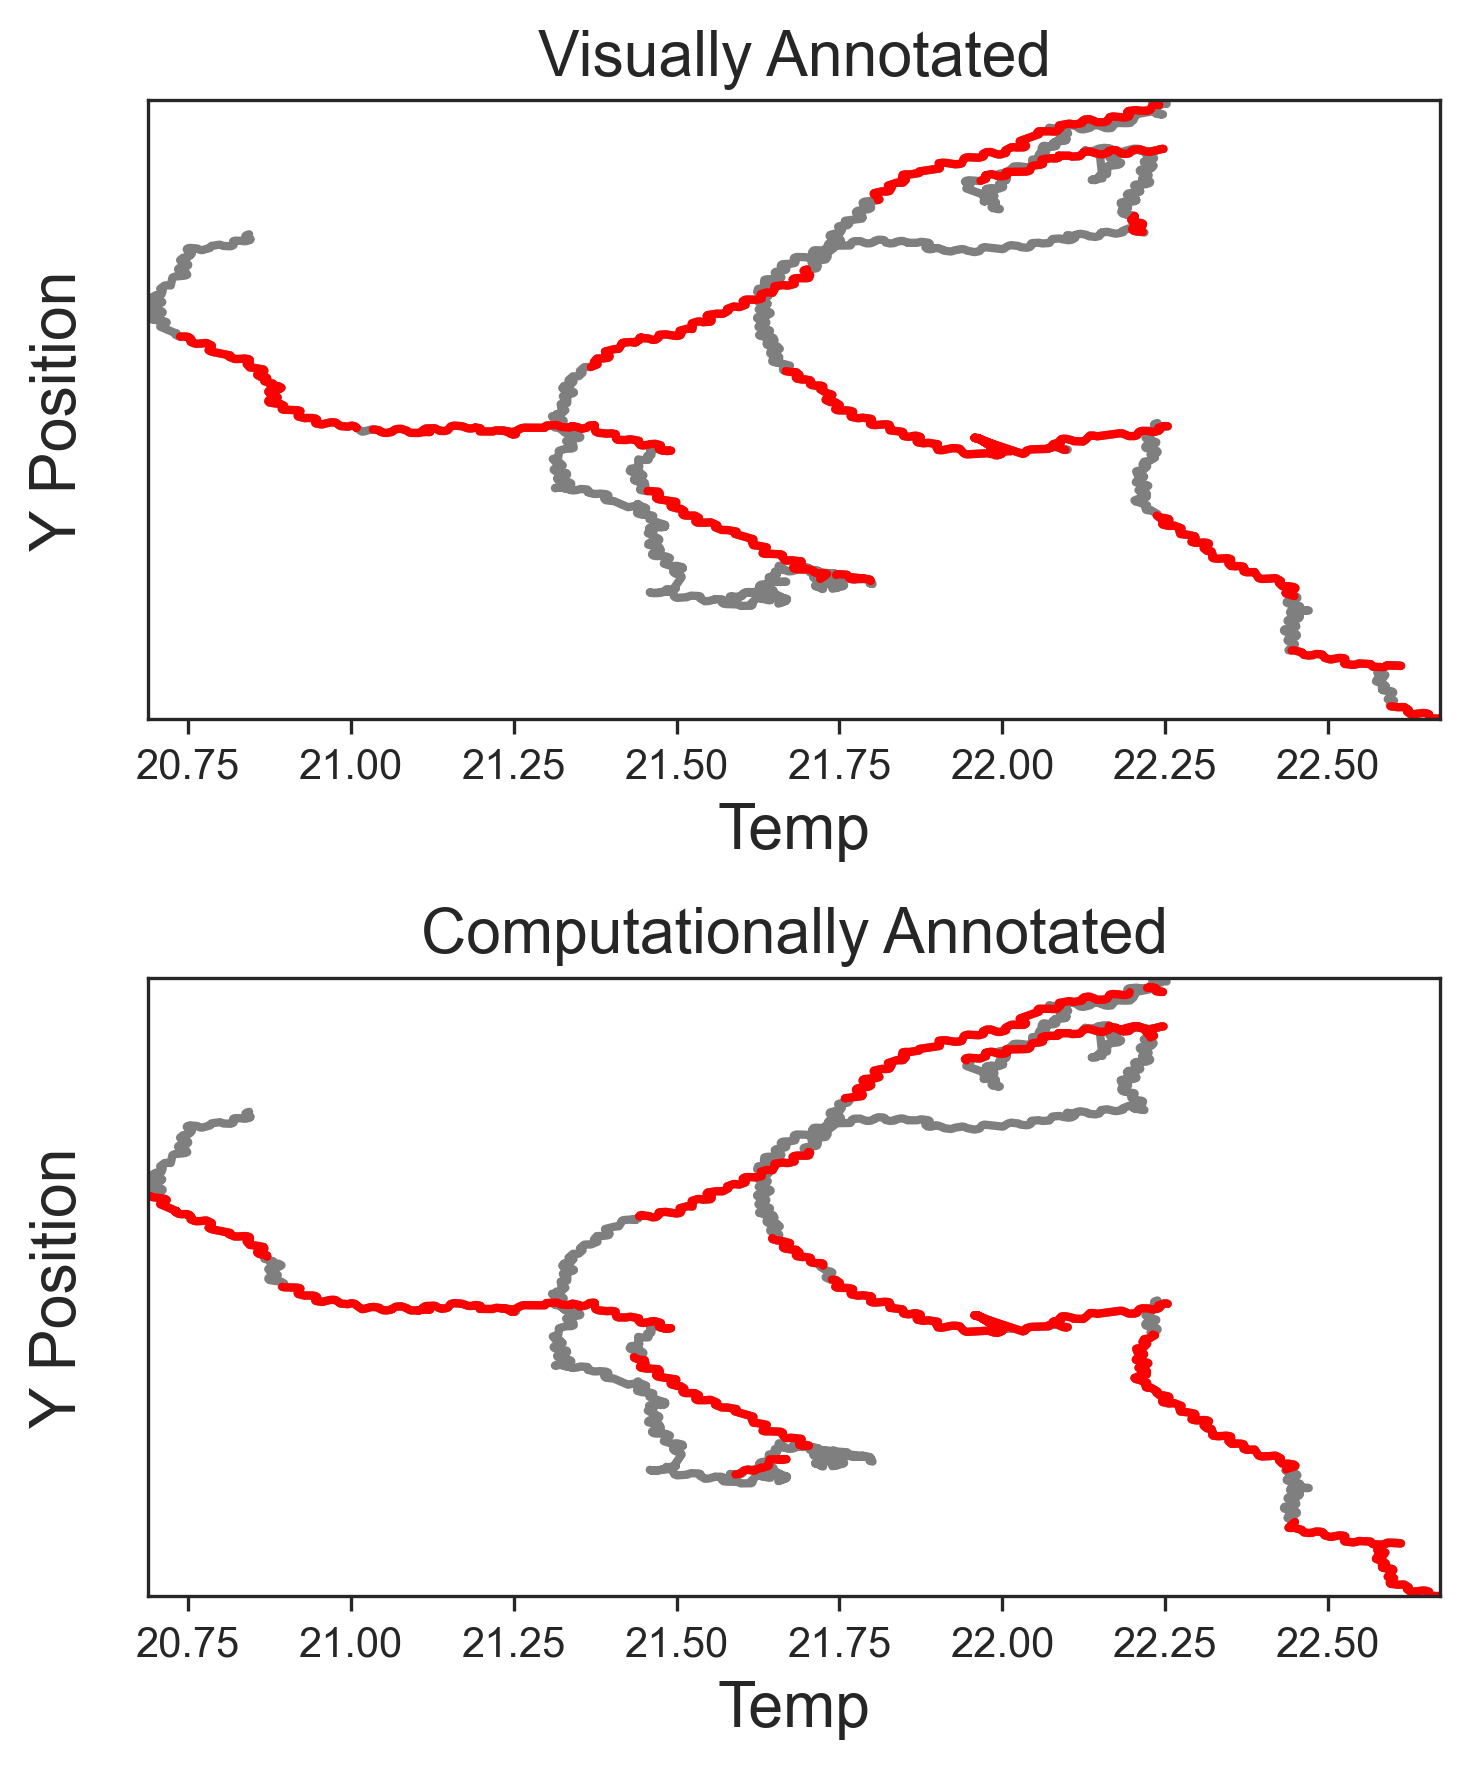

In [39]:
plt.clf()

fig, ax = plt.subplots(nrows = 2, ncols = 1, figsize=(5,6), dpi=300)
ax1 = plt.subplot(2,1,1)

plt.title('Parsed Behavior', fontsize=15)
ax2 = plt.subplot(2,1,2)

ax1.plot(Temp_steep_3_5_20, Ycoord_steep_3_5_20, c='k', lw=2, alpha=0.5)
ax2.plot(Temp_steep_3_5_20, Ycoord_steep_3_5_20, c='k', lw=2, alpha=0.5)

for i in run_east_video_steep_3_5_20:
    start, stop = find_start_stop(i, Frames_steep_3_5_20)
    ax1.plot(Temp_steep_3_5_20[start:stop], Ycoord_steep_3_5_20[start:stop], c='r', lw=2)
for i in comp_run_east_video_steep_3_5_20:
    ax2.plot(Temp_steep_3_5_20[i[0]:i[1]], Ycoord_steep_3_5_20[i[0]:i[1]], c='r', lw=2)

#for i in plateaus_steep_3_5_20:
#    ax1.plot(Temp_steep_3_5_20[i[0]:i[1]], Ycoord_steep_3_5_20[i[0]:i[1]],color='g', lw=2)
#    ax2.plot(Temp_steep_3_5_20[i[0]:i[1]], Ycoord_steep_3_5_20[i[0]:i[1]],color='g', lw=2)
    
    
ax1.set_xlim(xmin=min(Temp_steep_3_5_20),xmax=max(Temp_steep_3_5_20))
ax1.set_ylim(ymin=min(Ycoord_steep_3_5_20),ymax=max(Ycoord_steep_3_5_20))
ax1.set_ylabel('Y Position', fontsize=15)
ax1.set_xlabel('Temp', fontsize=15)
ax1.set_title('Visually Annotated', fontsize=15)

ax1.tick_params(axis='y', colors='white', labelsize=0)
ax1.tick_params(axis='x', labelsize=10)

ax2.tick_params(axis = 'both', labelsize=15)
ax2.set_xlim(xmin=min(Temp_steep_3_5_20),xmax=max(Temp_steep_3_5_20))
ax2.set_ylim(ymin=min(Ycoord_steep_3_5_20),ymax=max(Ycoord_steep_3_5_20))
ax2.set_ylabel('Y Position', fontsize=15)
ax2.set_xlabel('Temp', fontsize=15)
ax2.set_title('Computationally Annotated', fontsize=15)

ax2.tick_params(axis='y', colors='white', labelsize=0)
ax2.tick_params(axis='x', labelsize=10)

plt.tight_layout()


plt.show()

<Figure size 432x288 with 0 Axes>

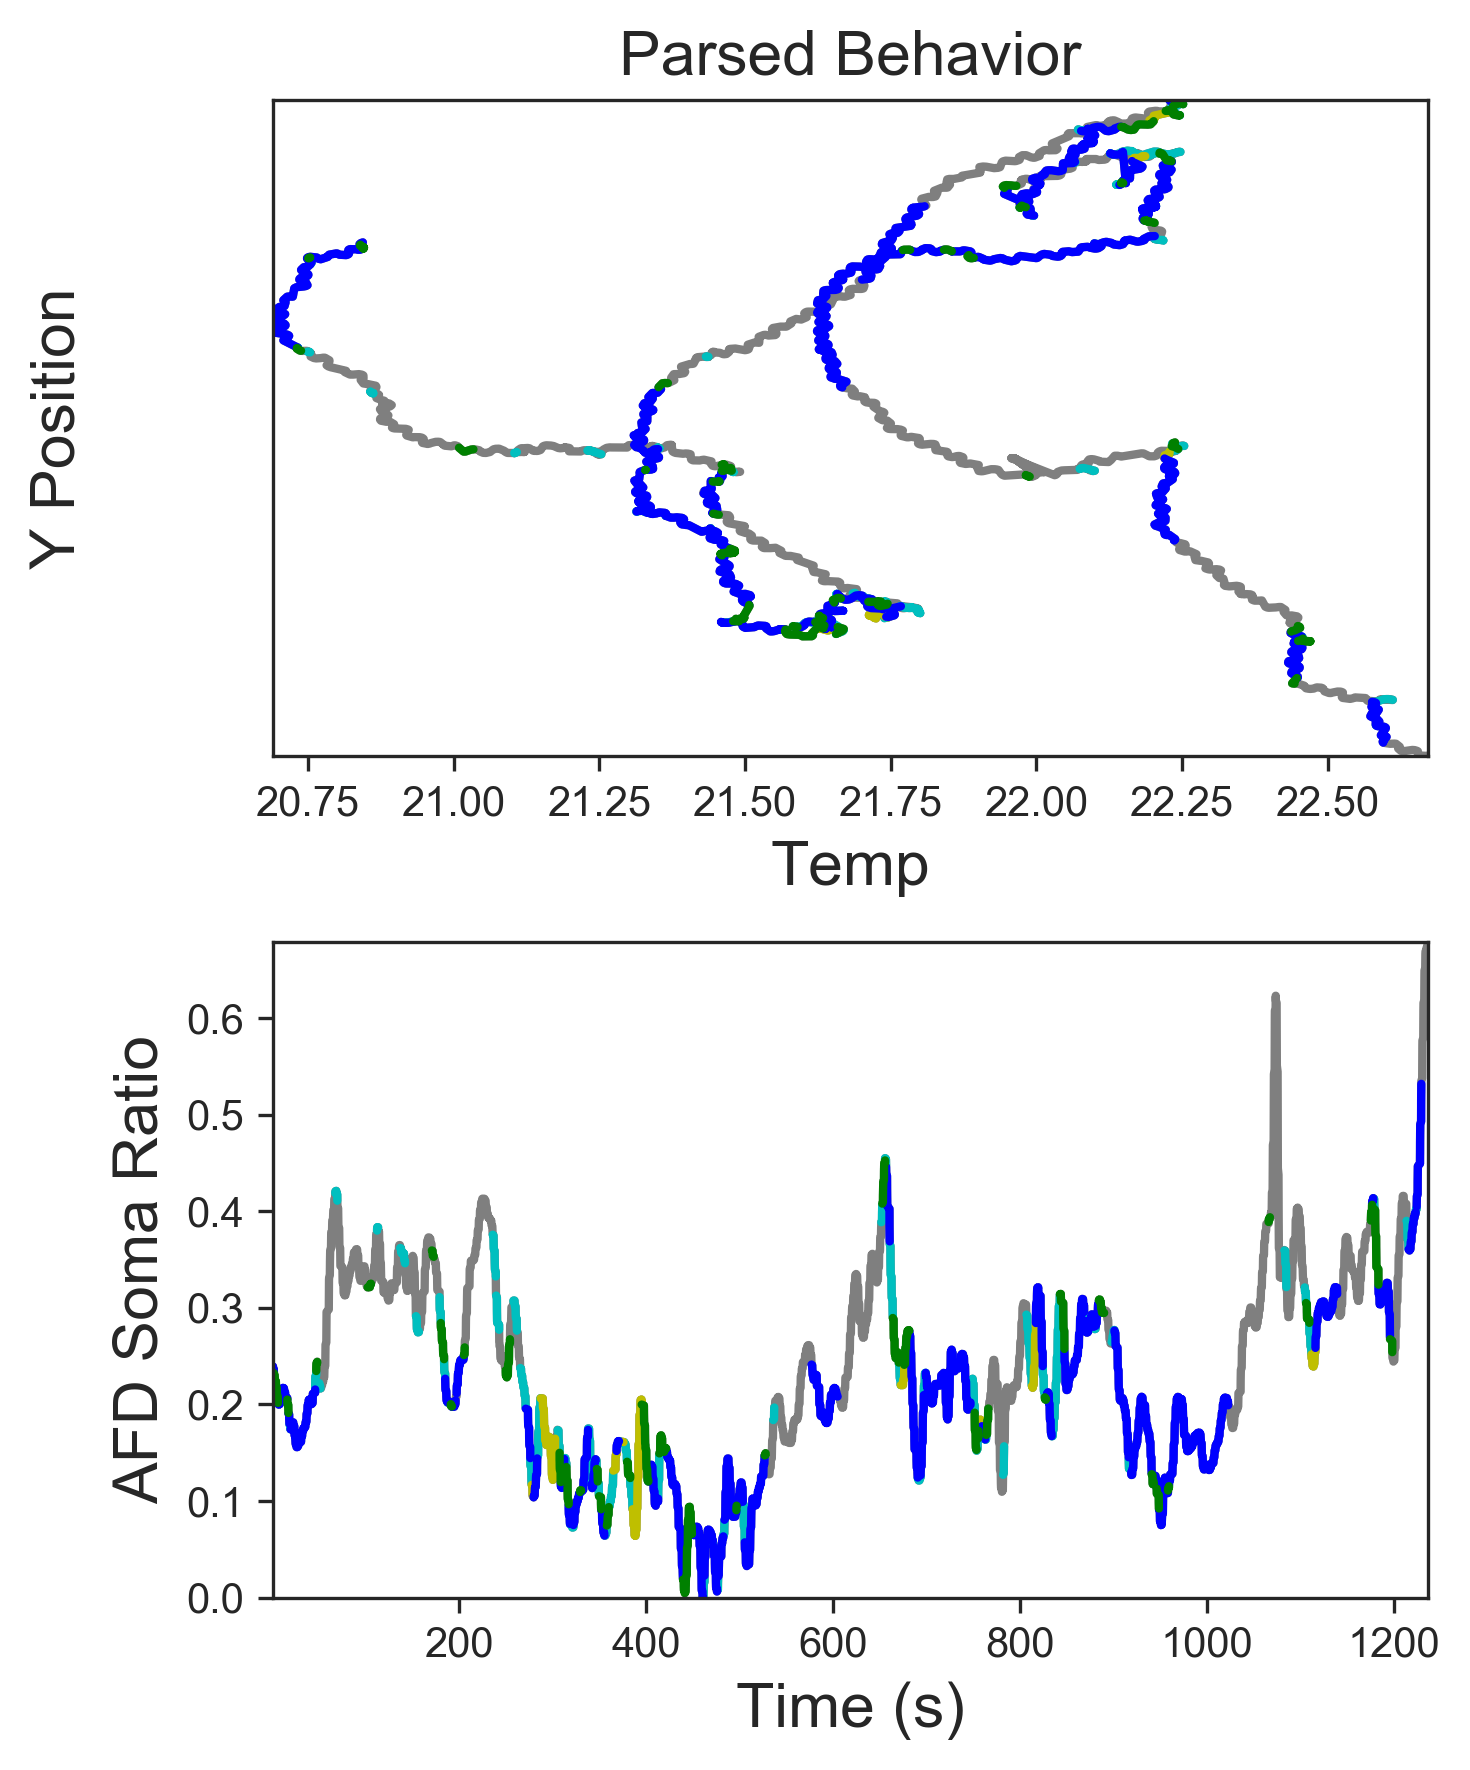

In [22]:
plt.clf()

fig, ax = plt.subplots(nrows = 2, ncols = 1, figsize=(5,6), dpi=300)
ax1 = plt.subplot(2,1,1)

plt.title('Parsed Behavior', fontsize=15)
ax2 = plt.subplot(2,1,2)

ax1.plot(Temp_steep_3_5_20, Ycoord_steep_3_5_20, c='k', lw=2, alpha=0.5)
ax2.plot(Time_steep_3_5_20, DeltaR_steep_3_5_20, c='k', lw=2, alpha=0.5)

for i in reversals_steep_3_5_20:
    start, stop = find_start_stop(i, Frames_steep_3_5_20)
    ax1.plot(Temp_steep_3_5_20[start:stop], Ycoord_steep_3_5_20[start:stop], c='c', lw=2)
    ax2.plot(Time_steep_3_5_20[start:stop], DeltaR_steep_3_5_20[start:stop], c='c', lw=2)
    
for i in omega_turns_steep_3_5_20:
    start, stop = find_start_stop(i, Frames_steep_3_5_20)
    ax1.plot(Temp_steep_3_5_20[start:stop], Ycoord_steep_3_5_20[start:stop], c='y', lw=2)
    ax2.plot(Time_steep_3_5_20[start:stop], DeltaR_steep_3_5_20[start:stop], c='y', lw=2)
    
for i in run_not_e_video_steep_3_5_20:
    start, stop = find_start_stop(i, Frames_steep_3_5_20)
    ax1.plot(Temp_steep_3_5_20[start:stop], Ycoord_steep_3_5_20[start:stop], c='b', lw=2)
    ax2.plot(Time_steep_3_5_20[start:stop], DeltaR_steep_3_5_20[start:stop], c='b', lw=2)
    
for i in pause_explore_bend_steep_3_5_20:
    start, stop = find_start_stop(i, Frames_steep_3_5_20)
    ax1.plot(Temp_steep_3_5_20[start:stop], Ycoord_steep_3_5_20[start:stop], c='g', lw=2)
    ax2.plot(Time_steep_3_5_20[start:stop], DeltaR_steep_3_5_20[start:stop], c='g', lw=2)

ax1.tick_params(axis='y', colors='white')
ax1.tick_params(axis='x', labelsize=10)
ax1.set_xlim(xmin=min(Temp_steep_3_5_20),xmax=max(Temp_steep_3_5_20))
ax1.set_ylim(ymin=min(Ycoord_steep_3_5_20),ymax=max(Ycoord_steep_3_5_20))
ax1.set_ylabel('Y Position', fontsize=15)
ax1.set_xlabel('Temp', fontsize=15)
    
ax2.tick_params(axis = 'both', labelsize=10)
ax2.set_xlim(xmin=min(Time_steep_3_5_20),xmax=max(Time_steep_3_5_20))
ax2.set_ylim(ymin=min(DeltaR_steep_3_5_20),ymax=max(DeltaR_steep_3_5_20))
ax2.set_ylabel('AFD Soma Ratio', fontsize=15)
ax2.set_xlabel('Time (s)', fontsize=15)

plt.tight_layout()
plt.show()
plt.close()

<Figure size 432x288 with 0 Axes>

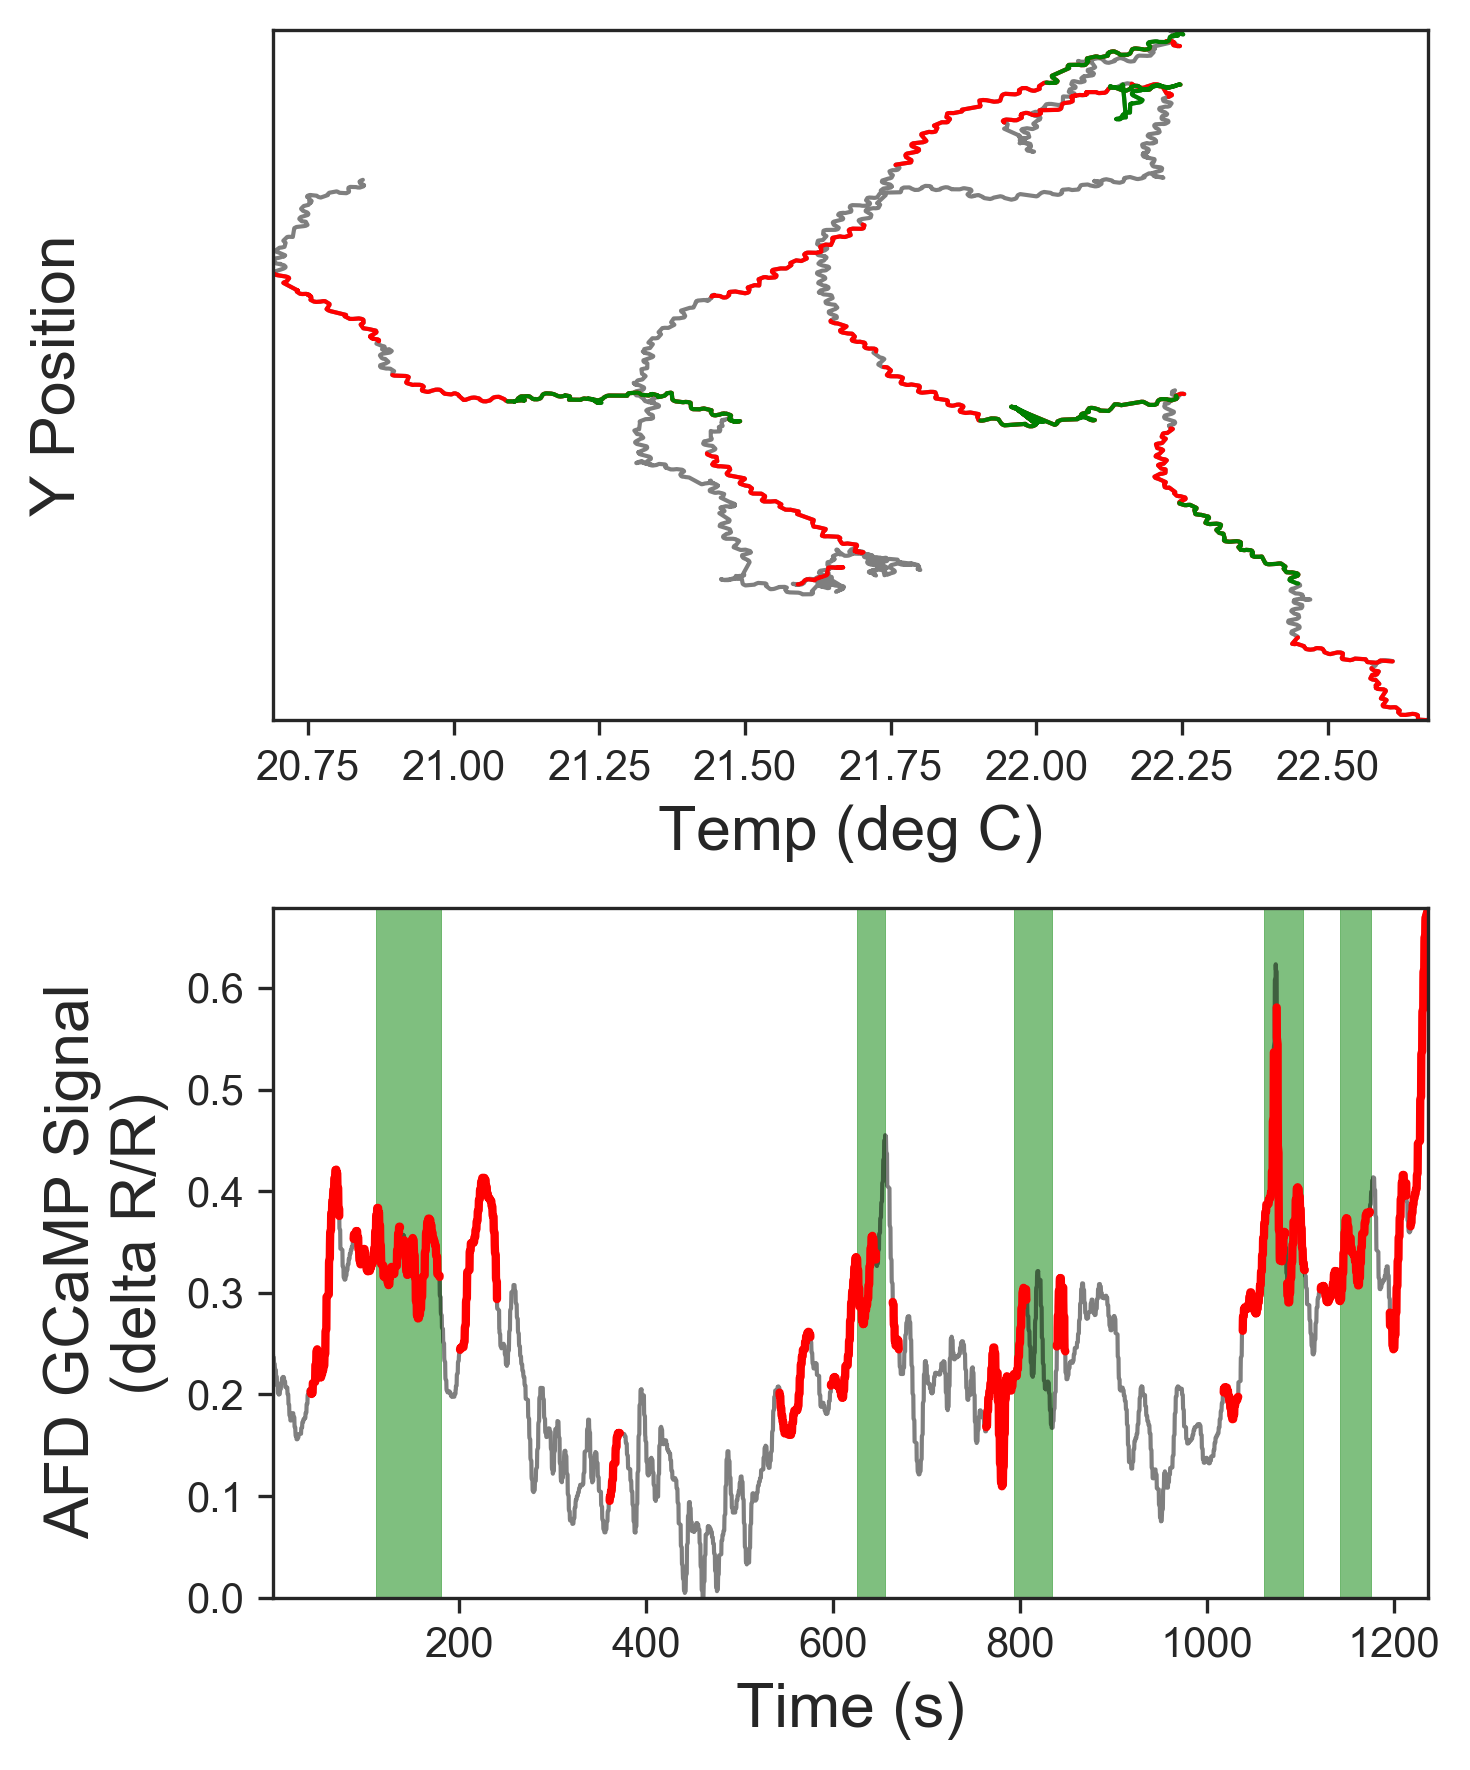

In [20]:


plt.clf()

fig, ax = plt.subplots(nrows = 2, ncols = 1, figsize=(5,6),dpi=300)
ax2 = plt.subplot(2,1,1)

ax1 = plt.subplot(2,1,2) ##
#plt.title('Visually Called Plateaus', fontsize=15)

ax2.plot(Temp_steep_3_5_20, Ycoord_steep_3_5_20, c='k', lw=1, alpha=0.5)
ax1.plot(Time_steep_3_5_20, DeltaR_steep_3_5_20, c='k', lw=1, alpha=0.5)

for i in comp_run_east_video_steep_3_5_20:
    start, stop = find_start_stop(i, Frames_steep_3_5_20)
    ax2.plot(Temp_steep_3_5_20[i[0]:i[1]], Ycoord_steep_3_5_20[i[0]:i[1]], c='r', lw=1)
    ax1.plot(Time_steep_3_5_20[i[0]:i[1]], DeltaR_steep_3_5_20[i[0]:i[1]], c='r', lw=2)
    
for i in plateaus_steep_3_5_20:
    ax2.plot(Temp_steep_3_5_20[i[0]:i[1]],Ycoord_steep_3_5_20[i[0]:i[1]],c='g', lw=1)
    ax1.axvspan(Time_steep_3_5_20[i[0]],Time_steep_3_5_20[i[1]],alpha=0.5,color='green', lw=0.2)
    
ax2.tick_params(axis='y', colors='white')
ax2.tick_params(axis='x', labelsize=10)
ax2.set_xlim(xmin=min(Temp_steep_3_5_20),xmax=max(Temp_steep_3_5_20))
ax2.set_ylim(ymin=min(Ycoord_steep_3_5_20),ymax=max(Ycoord_steep_3_5_20))
ax2.set_ylabel('Y Position', fontsize=15)
ax2.set_xlabel('Temp (deg C)', fontsize=15)
  
    
ax1.tick_params(axis = 'both', labelsize=10)
ax1.set_xlim(xmin=min(Time_steep_3_5_20),xmax=max(Time_steep_3_5_20))
ax1.set_ylim(ymin=min(DeltaR_steep_3_5_20),ymax=max(DeltaR_steep_3_5_20))
ax1.set_ylabel('AFD GCaMP Signal \n (delta R/R)', fontsize=15)
ax1.set_xlabel('Time (s)', fontsize=15)

plt.tight_layout()
#plt.savefig('xxx.png', dpi=600, bbox_inches='tight')
#plt.savefig('xxx.svg', dpi=600, bbox_inches='tight')

plt.show()


# Shallow

### 2_5_20

In [40]:
source = "csv"
if source == "csv":
    # Load the CSV file
    pref = pref = "C:/Users/dgmdi\OneDrive - Yale University/Documents/AFD Range of Thermal Perception/"
    file_path = pref + "Shallow_5p5_2_5_20_1_data.csv"  
    df = pd.read_csv(file_path)

    # Store each column in its own list
    Ycoord_shallow_2_5_20_r1       = df['y'].tolist()
    Xcoord_shallow_2_5_20_r1       = df['x'].tolist()
    Temp_shallow_2_5_20_r1    = df['Temp'].tolist()
    Time_shallow_2_5_20_r1    = df['Time'].tolist()
    Frames_shallow_2_5_20_r1  = df['frames'].tolist()
    DeltaR_shallow_2_5_20_r1 = df['Delta_R'].tolist()
    
plateaus_shallow_2_5_20_r1 = [(1325,1755),(5700,6120),(7975,8700),(9000,9520)
                         ]

In [41]:
comp_reversals_shallow_2_5_20_r1, comp_run_east_video_shallow_2_5_20_r1 = comp_call_revs_pos_runs(
    Xcoord_shallow_2_5_20_r1, Ycoord_shallow_2_5_20_r1, Temp_shallow_2_5_20_r1, Time_shallow_2_5_20_r1, step=10)


<Figure size 432x288 with 0 Axes>

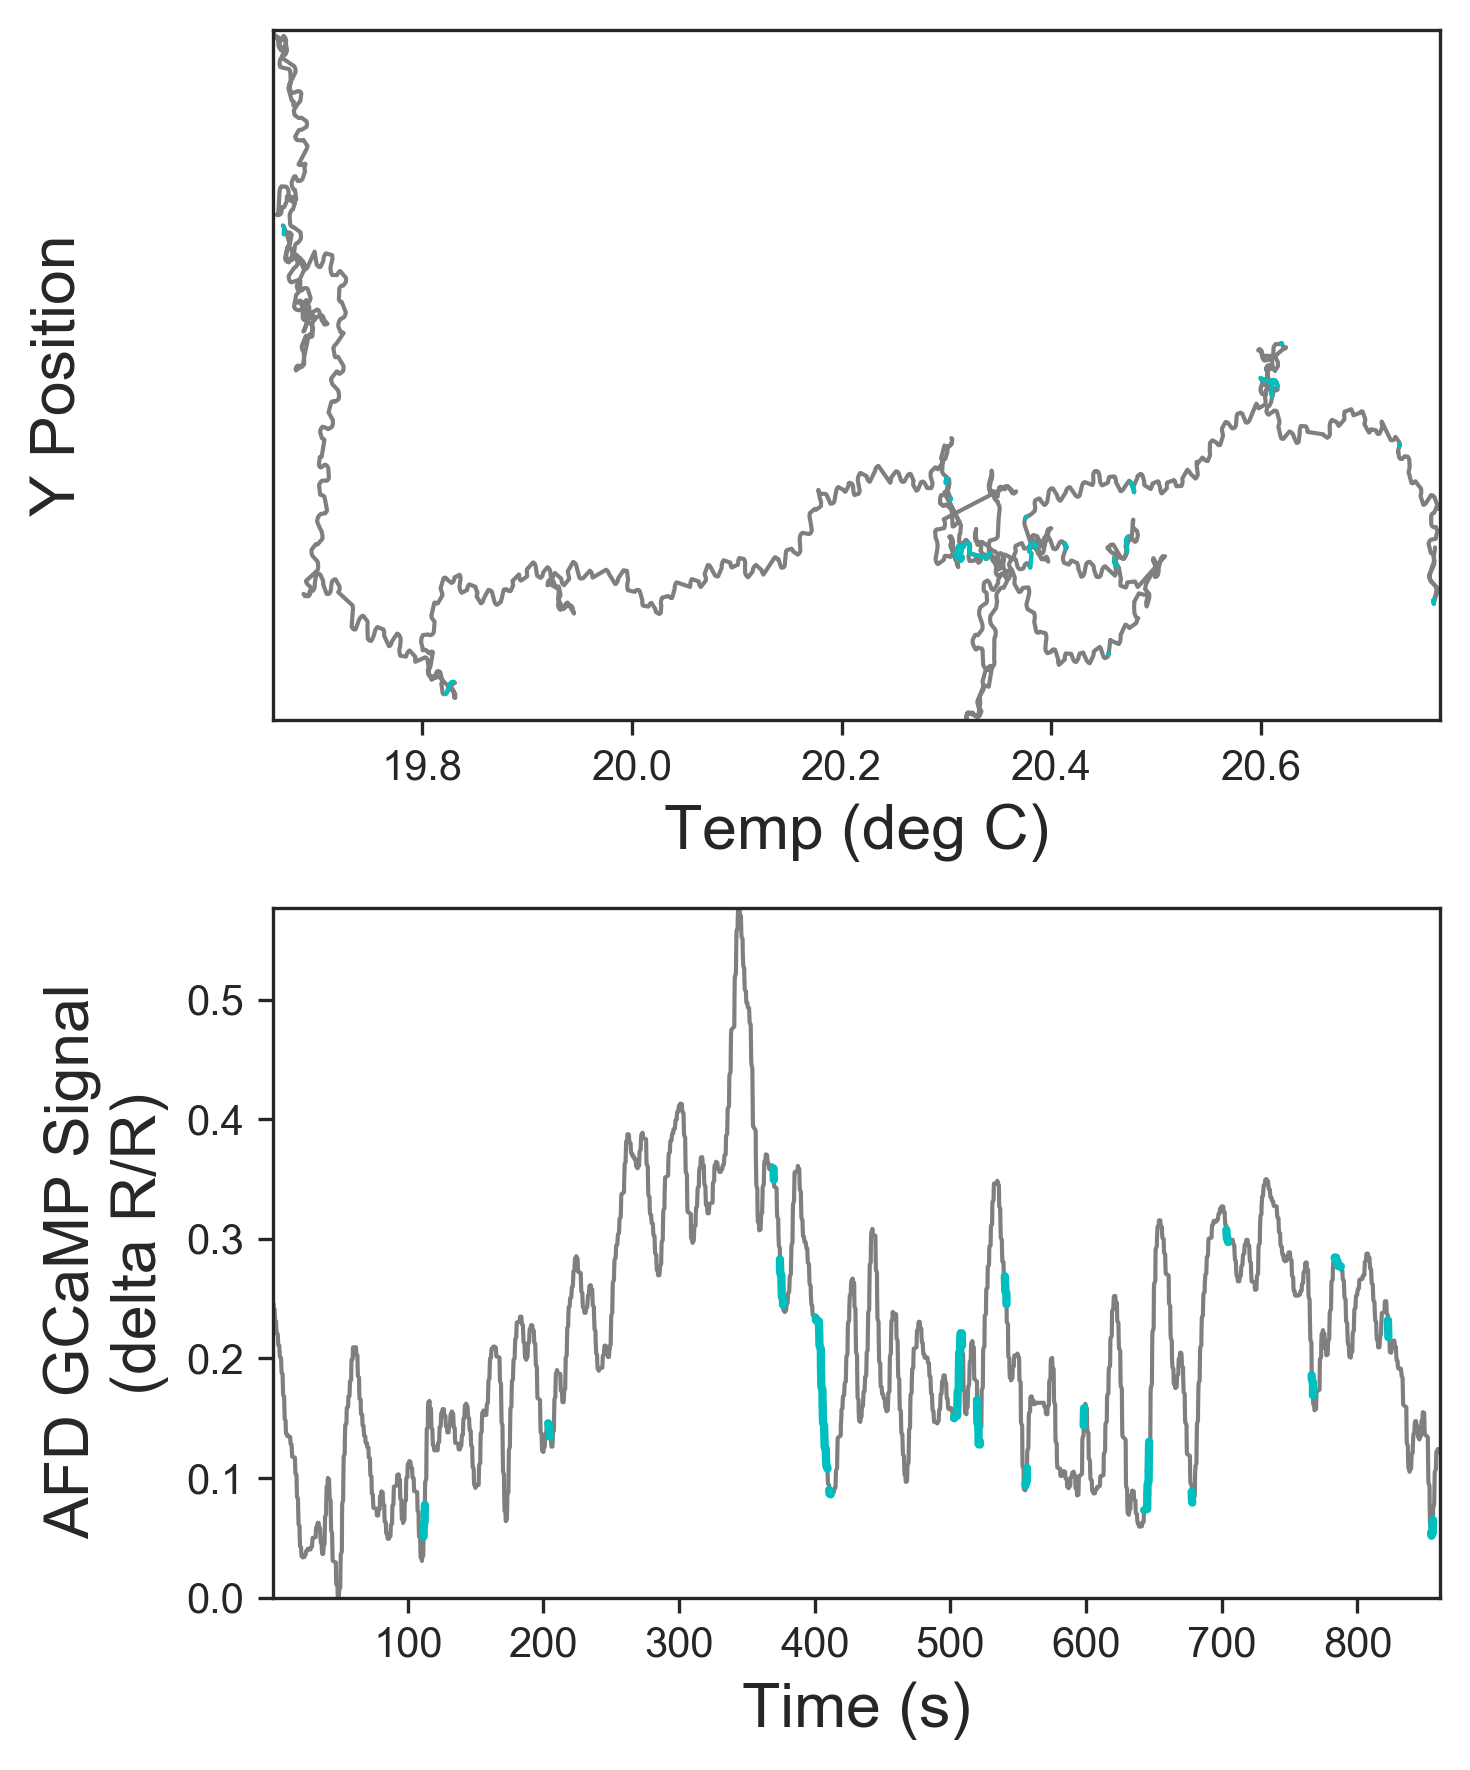

In [25]:
plt.clf()

fig, ax = plt.subplots(nrows = 2, ncols = 1, figsize=(5,6),dpi=300)
ax2 = plt.subplot(2,1,1)

ax1 = plt.subplot(2,1,2) ##
#plt.title('Visually Called Plateaus', fontsize=15)

ax2.plot(Temp_shallow_2_5_20_r1, Ycoord_shallow_2_5_20_r1, c='k', lw=1, alpha=0.5)
ax1.plot(Time_shallow_2_5_20_r1, DeltaR_shallow_2_5_20_r1, c='k', lw=1, alpha=0.5)

for i in comp_reversals_shallow_2_5_20_r1:
    start, stop = find_start_stop(i, Frames_shallow_2_5_20_r1)
    ax2.plot(Temp_shallow_2_5_20_r1[i[0]:i[1]], Ycoord_shallow_2_5_20_r1[i[0]:i[1]], c='c', lw=1)
    ax1.plot(Time_shallow_2_5_20_r1[i[0]:i[1]], DeltaR_shallow_2_5_20_r1[i[0]:i[1]], c='c', lw=2)
    
#for i in plateaus_shallow_2_5_20_r1:
#    ax2.plot(Temp_shallow_2_5_20_r1[i[0]:i[1]],Ycoord_shallow_2_5_20_r1[i[0]:i[1]],c='g', lw=1)
#    ax1.axvspan(Time_shallow_2_5_20_r1[i[0]],Time_shallow_2_5_20_r1[i[1]],alpha=0.5,color='green', lw=0.2)
    
ax2.tick_params(axis='y', colors='white')
ax2.tick_params(axis='x', labelsize=10)
ax2.set_xlim(xmin=min(Temp_shallow_2_5_20_r1),xmax=max(Temp_shallow_2_5_20_r1))
ax2.set_ylim(ymin=min(Ycoord_shallow_2_5_20_r1),ymax=max(Ycoord_shallow_2_5_20_r1))
ax2.set_ylabel('Y Position', fontsize=15)
ax2.set_xlabel('Temp (deg C)', fontsize=15)
  
    
ax1.tick_params(axis = 'both', labelsize=10)
ax1.set_xlim(xmin=min(Time_shallow_2_5_20_r1),xmax=max(Time_shallow_2_5_20_r1))
ax1.set_ylim(ymin=min(DeltaR_shallow_2_5_20_r1),ymax=max(DeltaR_shallow_2_5_20_r1))
ax1.set_ylabel('AFD GCaMP Signal \n (delta R/R)', fontsize=15)
ax1.set_xlabel('Time (s)', fontsize=15)

plt.tight_layout()
#plt.savefig('xxx.png', dpi=600, bbox_inches='tight')
#plt.savefig('xxx.svg', dpi=600, bbox_inches='tight')

plt.show()

<Figure size 432x288 with 0 Axes>

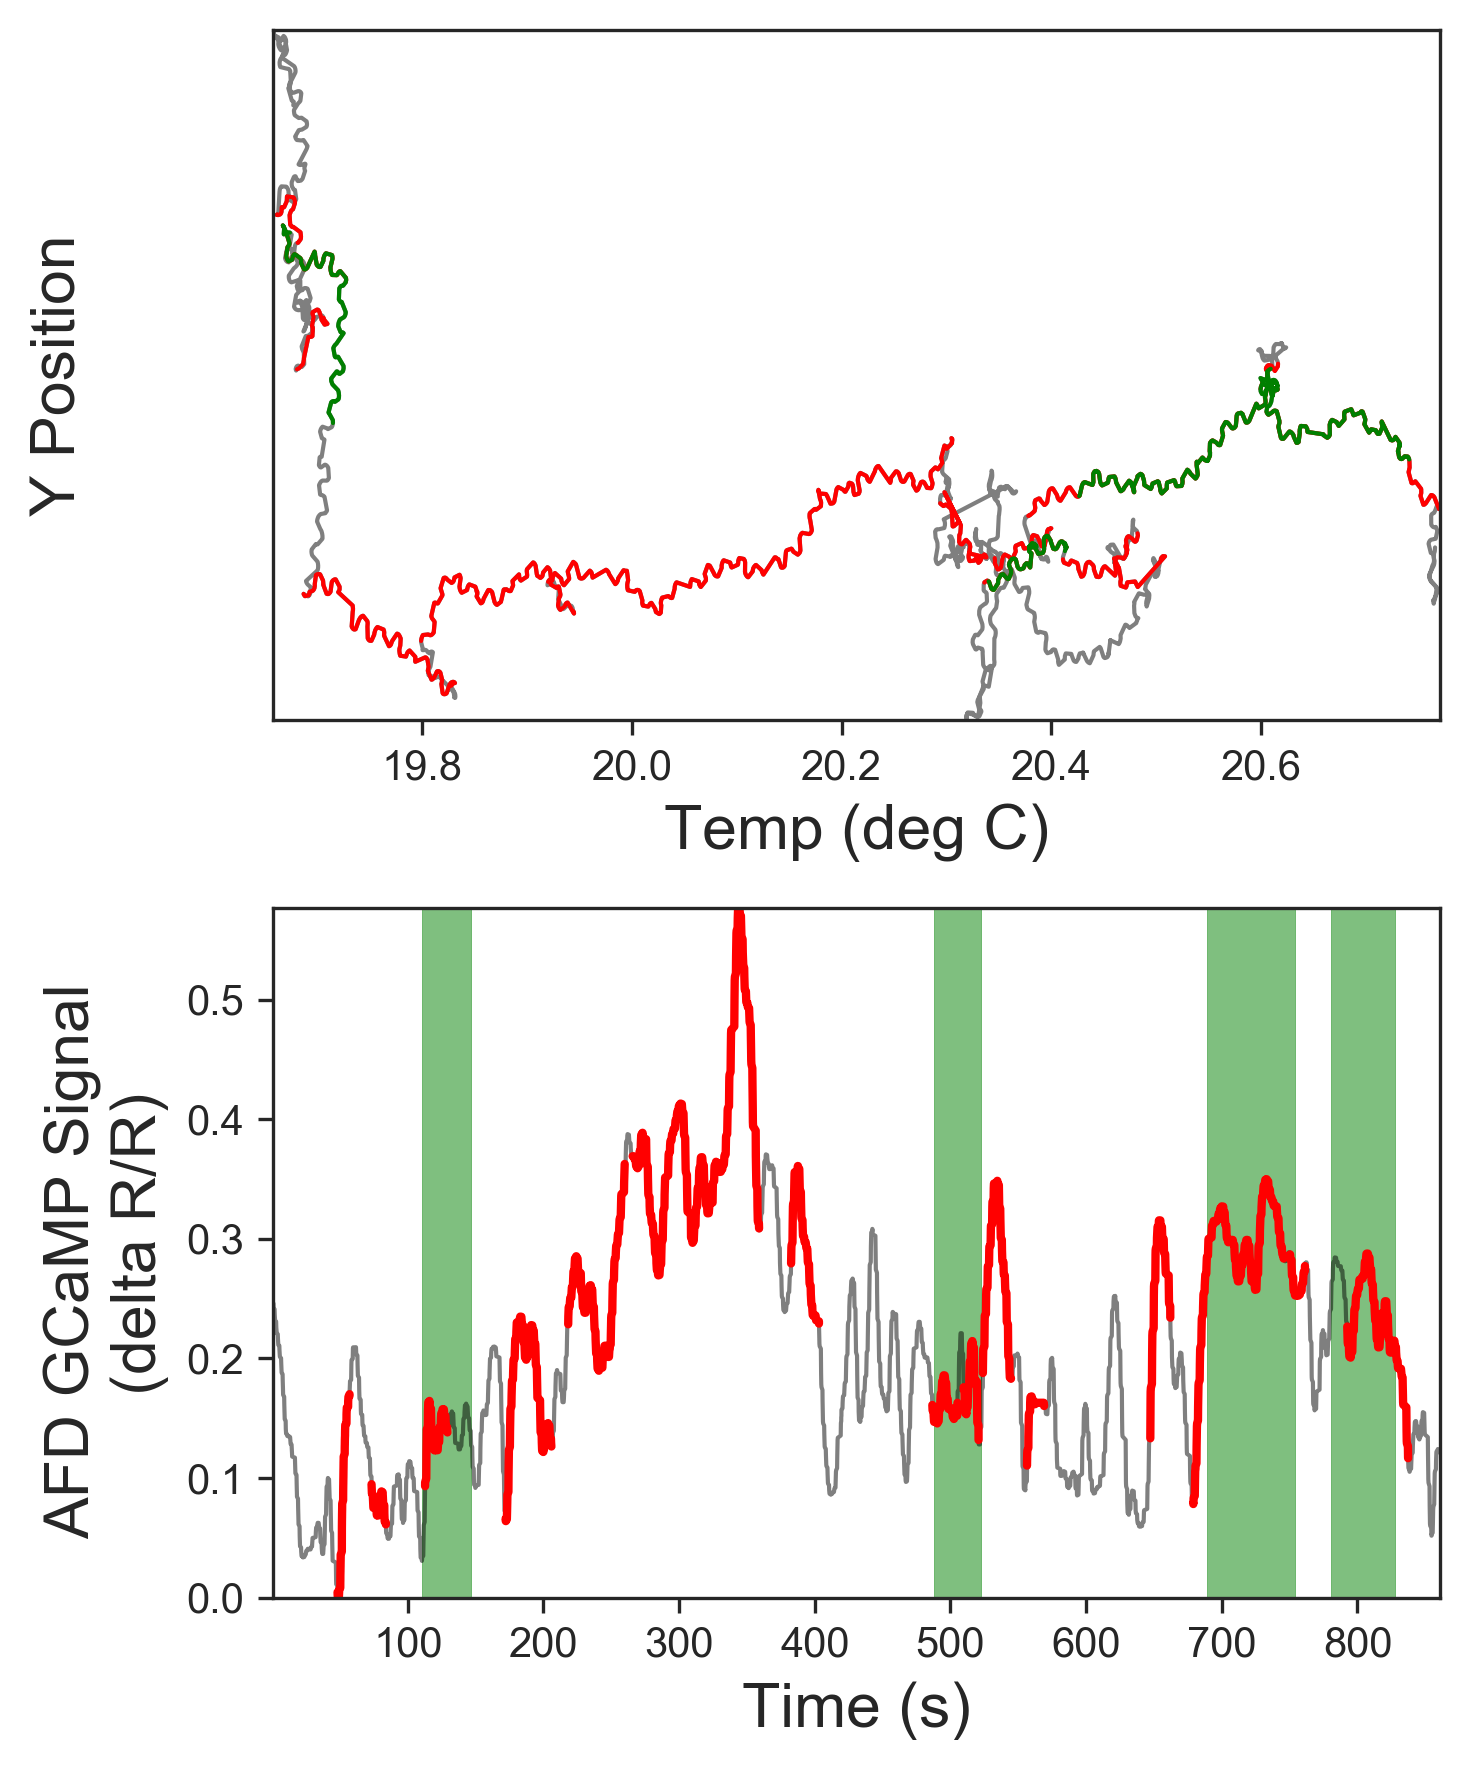

In [26]:
plt.clf()

fig, ax = plt.subplots(nrows = 2, ncols = 1, figsize=(5,6),dpi=300)
ax2 = plt.subplot(2,1,1)

ax1 = plt.subplot(2,1,2) ##
#plt.title('Visually Called Plateaus', fontsize=15)

ax2.plot(Temp_shallow_2_5_20_r1, Ycoord_shallow_2_5_20_r1, c='k', lw=1, alpha=0.5)
ax1.plot(Time_shallow_2_5_20_r1, DeltaR_shallow_2_5_20_r1, c='k', lw=1, alpha=0.5)

for i in comp_run_east_video_shallow_2_5_20_r1:
    start, stop = find_start_stop(i, Frames_shallow_2_5_20_r1)
    ax2.plot(Temp_shallow_2_5_20_r1[i[0]:i[1]], Ycoord_shallow_2_5_20_r1[i[0]:i[1]], c='r', lw=1)
    ax1.plot(Time_shallow_2_5_20_r1[i[0]:i[1]], DeltaR_shallow_2_5_20_r1[i[0]:i[1]], c='r', lw=2)
    
for i in plateaus_shallow_2_5_20_r1:
    ax2.plot(Temp_shallow_2_5_20_r1[i[0]:i[1]],Ycoord_shallow_2_5_20_r1[i[0]:i[1]],c='g', lw=1)
    ax1.axvspan(Time_shallow_2_5_20_r1[i[0]],Time_shallow_2_5_20_r1[i[1]],alpha=0.5,color='green', lw=0.2)
    
ax2.tick_params(axis='y', colors='white')
ax2.tick_params(axis='x', labelsize=10)
ax2.set_xlim(xmin=min(Temp_shallow_2_5_20_r1),xmax=max(Temp_shallow_2_5_20_r1))
ax2.set_ylim(ymin=min(Ycoord_shallow_2_5_20_r1),ymax=max(Ycoord_shallow_2_5_20_r1))
ax2.set_ylabel('Y Position', fontsize=15)
ax2.set_xlabel('Temp (deg C)', fontsize=15)
  
    
ax1.tick_params(axis = 'both', labelsize=10)
ax1.set_xlim(xmin=min(Time_shallow_2_5_20_r1),xmax=max(Time_shallow_2_5_20_r1))
ax1.set_ylim(ymin=min(DeltaR_shallow_2_5_20_r1),ymax=max(DeltaR_shallow_2_5_20_r1))
ax1.set_ylabel('AFD GCaMP Signal \n (delta R/R)', fontsize=15)
ax1.set_xlabel('Time (s)', fontsize=15)

plt.tight_layout()
#plt.savefig('xxx.png', dpi=600, bbox_inches='tight')
#plt.savefig('xxx.svg', dpi=600, bbox_inches='tight')

plt.show()

# Plateau Analysis

### Deriv vs Avg Signal

In [42]:
plateau_temp_rates_steep_3_4_20 = []
plateau_mean_cal_steep_3_4_20 = []

plateau_temp_rates_shallow_2_5_20_r1 = []
plateau_mean_cal_shallow_2_5_20_r1 = []

plateau_temp_rates_steep_3_5_20 = []
plateau_mean_cal_steep_3_5_20 = []

for i in plateaus_steep_3_4_20:
    plateau_temp_rates_steep_3_4_20.append(60*(Temp_steep_3_4_20[i[1]] - Temp_steep_3_4_20[i[0]])/
                                                (Time_steep_3_4_20[i[1]] - Time_steep_3_4_20[i[0]]))
    plateau_mean_cal_steep_3_4_20.append(np.mean(DeltaR_steep_3_4_20[i[0]:i[1]]))
    
for i in plateaus_shallow_2_5_20_r1:
    plateau_temp_rates_shallow_2_5_20_r1.append(60*(Temp_shallow_2_5_20_r1[i[1]] - Temp_shallow_2_5_20_r1[i[0]])/
                                                (Time_shallow_2_5_20_r1[i[1]] - Time_shallow_2_5_20_r1[i[0]]))
    plateau_mean_cal_shallow_2_5_20_r1.append(np.mean(DeltaR_shallow_2_5_20_r1[i[0]:i[1]]))
    
for i in plateaus_steep_3_5_20:
    plateau_temp_rates_steep_3_5_20.append(60*(Temp_steep_3_5_20[i[1]] - Temp_steep_3_5_20[i[0]])/
                                                (Time_steep_3_5_20[i[1]] - Time_steep_3_5_20[i[0]]))
    plateau_mean_cal_steep_3_5_20.append(np.mean(DeltaR_steep_3_5_20[i[0]:i[1]]))
    

0.7214544906581382


<Figure size 640x480 with 0 Axes>

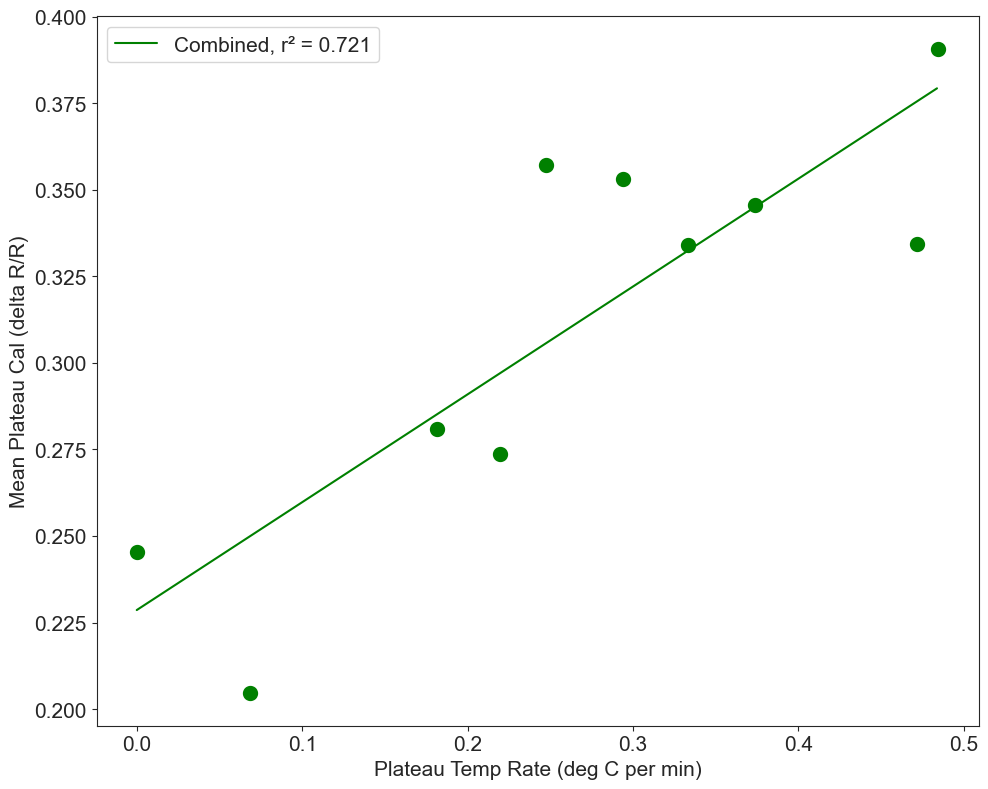

In [43]:
# Combined steep_

combined_steep_plateau_temp_rates = plateau_temp_rates_steep_3_4_20 + plateau_temp_rates_steep_3_5_20 
combined_steep_plateau_mean_cal = plateau_mean_cal_steep_3_4_20 + plateau_mean_cal_steep_3_5_20 

model = np.polyfit(combined_steep_plateau_temp_rates, combined_steep_plateau_mean_cal, 1)
predict = np.poly1d(model)
from sklearn.metrics import r2_score
r2 = r2_score(combined_steep_plateau_mean_cal, predict(combined_steep_plateau_temp_rates))
print(r2)

x_lin_reg = np.arange(min(combined_steep_plateau_temp_rates), max(combined_steep_plateau_temp_rates), 0.001)
y_lin_reg = predict(x_lin_reg)

plt.clf()
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize=(10,8))
ax1 = plt.subplot(1,1,1)
ax1.scatter(combined_steep_plateau_temp_rates, combined_steep_plateau_mean_cal, c='g', lw=5)
ax1.plot(x_lin_reg,y_lin_reg, c='g', label = f'Combined, r² = {r2:.3f}')
ax1.legend(fontsize=15)
ax1.tick_params(axis='y', labelsize=15)
ax1.tick_params(axis='x', labelsize=15)
#ax1.set_xlim(xmin=0.05,xmax=0.65)
#ax1.set_ylim(ymin=0.1, ymax=0.5)
ax1.set_ylabel('Mean Plateau Cal (delta R/R)', fontsize=15)
ax1.set_xlabel('Plateau Temp Rate (deg C per min)', fontsize=15)
plt.tight_layout()
#plt.savefig('Z:/Malcom/Freely_Moving_Folder_FromML_PC/Plateaus_moreLabeling_AmplitudeAnalysis/Combined_steep_Plats_deriv_vs_meanCa.svg', dpi=600, bbox_inches='tight')
plt.show()
plt.close()


0.6545812091370381


<Figure size 640x480 with 0 Axes>

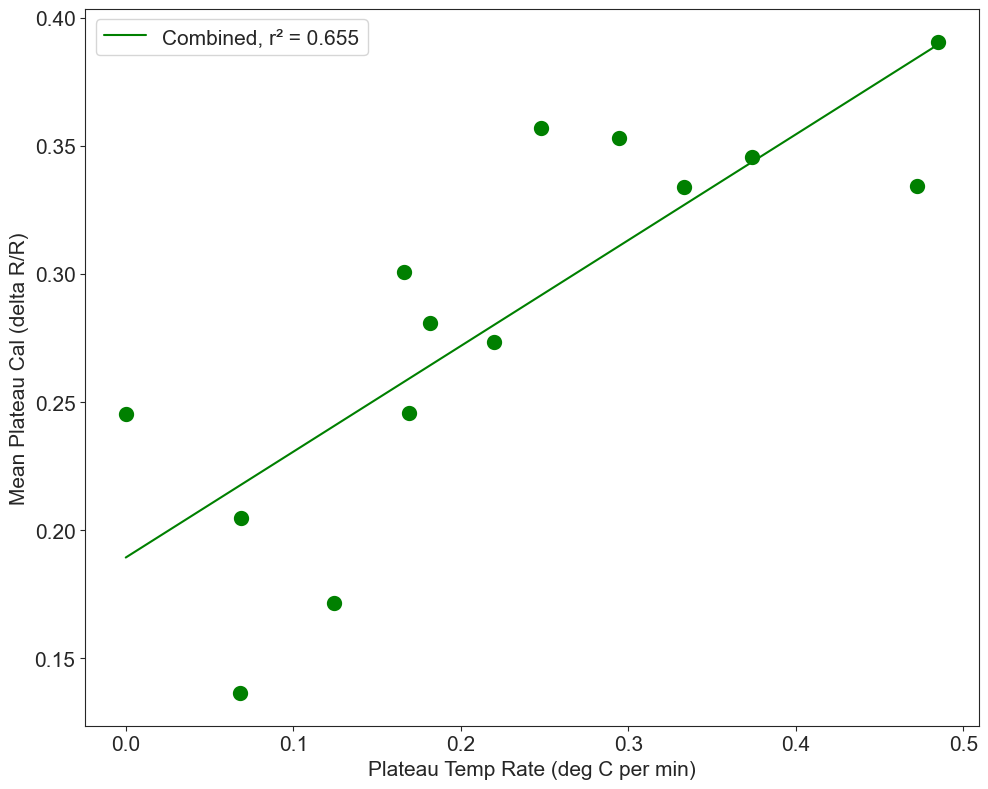

In [44]:
# All COMBINED

combined_plateau_temp_rates = plateau_temp_rates_steep_3_4_20 + plateau_temp_rates_steep_3_5_20 + plateau_temp_rates_shallow_2_5_20_r1
combined_plateau_mean_cal = plateau_mean_cal_steep_3_4_20 + plateau_mean_cal_steep_3_5_20 + plateau_mean_cal_shallow_2_5_20_r1

model = np.polyfit(combined_plateau_temp_rates, combined_plateau_mean_cal, 1)
predict = np.poly1d(model)
from sklearn.metrics import r2_score
r2 = r2_score(combined_plateau_mean_cal, predict(combined_plateau_temp_rates))
print(r2)

x_lin_reg = np.arange(min(combined_plateau_temp_rates), max(combined_plateau_temp_rates), 0.001)
y_lin_reg = predict(x_lin_reg)

plt.clf()
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize=(10,8))
ax1 = plt.subplot(1,1,1)
ax1.scatter(combined_plateau_temp_rates, combined_plateau_mean_cal, c='g', lw=5)
ax1.plot(x_lin_reg,y_lin_reg, c='g', label = f'Combined, r² = {r2:.3f}')
ax1.legend(fontsize=15)
ax1.tick_params(axis='y', labelsize=15)
ax1.tick_params(axis='x', labelsize=15)
#ax1.set_xlim(xmin=0.05,xmax=0.65)
#ax1.set_ylim(ymin=0.1, ymax=0.5)
ax1.set_ylabel('Mean Plateau Cal (delta R/R)', fontsize=15)
ax1.set_xlabel('Plateau Temp Rate (deg C per min)', fontsize=15)
plt.tight_layout()
#plt.savefig('Z:/Malcom/Freely_Moving_Folder_FromML_PC/Plateaus_moreLabeling_AmplitudeAnalysis/Combined_All_Plats_deriv_vs_meanCa.svg', dpi=600, bbox_inches='tight')
plt.show()
plt.close()

### Plateau Amplitude Analysis

In [45]:
# Steep 3_4_20
plateau_durations_steep_3_4_20 = []
plateau_amplitude_steep_3_4_20 = []
for i in plateaus_steep_3_4_20:

    delta_t = Time_steep_3_4_20[ i[1] ] - Time_steep_3_4_20[ i[0] ]
    plateau_durations_steep_3_4_20.append(delta_t)

    # keep your amplitude (or mean) calculation as before
    segment = DeltaR_steep_3_4_20[ i[0]:i[1] ]
    amp = (np.max(segment) - np.min(segment)) / 2
    plateau_amplitude_steep_3_4_20.append(amp)
    
# Steep 3_5_20    ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

plateau_durations_steep_3_5_20 = []
plateau_amplitude_steep_3_5_20 = []
for i in plateaus_steep_3_5_20:

    delta_t = Time_steep_3_5_20[ i[1] ] - Time_steep_3_5_20[ i[0] ]
    plateau_durations_steep_3_5_20.append(delta_t)

    # keep your amplitude (or mean) calculation as before
    segment = DeltaR_steep_3_5_20[ i[0]:i[1] ]
    amp = (np.max(segment) - np.min(segment)) / 2
    plateau_amplitude_steep_3_5_20.append(amp)

# Shallow 2_5_20_r1 ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

plateau_durations_2_5_20_r1 = []
plateau_amplitude_shallow_2_5_20_r1 = []
for i in plateaus_shallow_2_5_20_r1:

    delta_t = Time_shallow_2_5_20_r1[ i[1] ] - Time_shallow_2_5_20_r1[ i[0] ]
    plateau_durations_2_5_20_r1.append(delta_t)

    # keep your amplitude (or mean) calculation as before
    segment = DeltaR_shallow_2_5_20_r1[ i[0]:i[1] ]
    amp = (np.max(segment) - np.min(segment)) / 2
    plateau_amplitude_shallow_2_5_20_r1.append(amp)


0.14029825878455937


<Figure size 640x480 with 0 Axes>

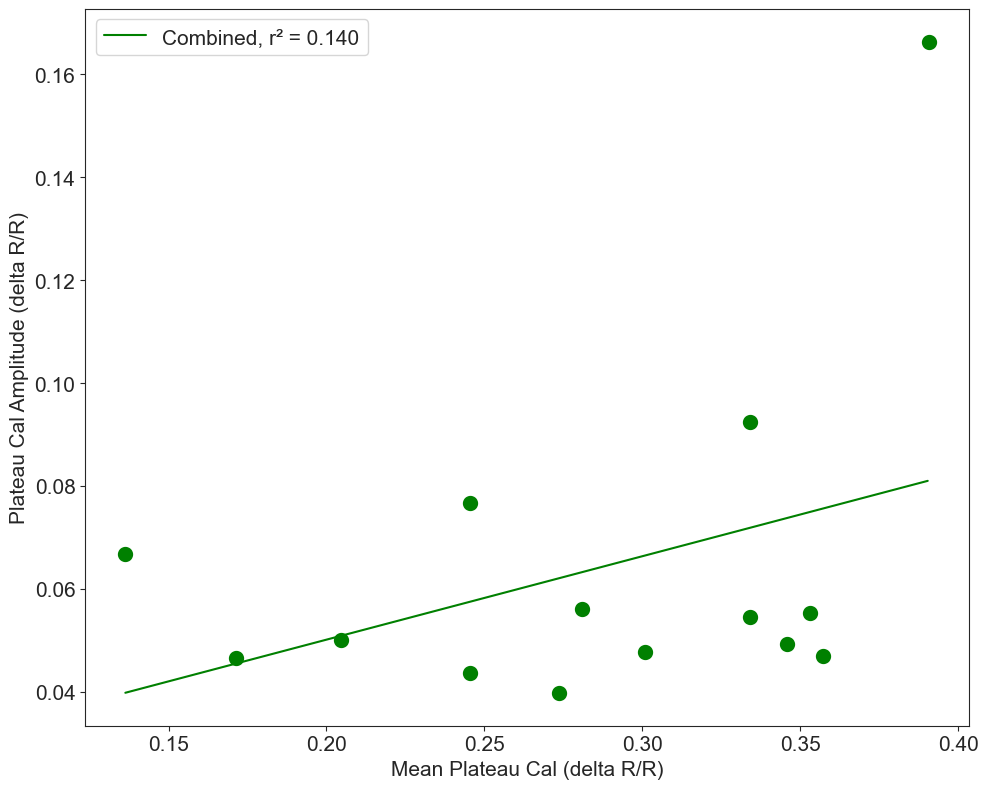

In [ ]:
# All COMBINED - Amplitude VS Deriv
combined_plateau_temp_rates = plateau_temp_rates_steep_3_4_20 + plateau_temp_rates_steep_3_5_20 + plateau_temp_rates_shallow_2_5_20_r1
combined_plateau_amplitude_cal = plateau_amplitude_steep_3_4_20 + plateau_amplitude_steep_3_5_20 + plateau_amplitude_shallow_2_5_20_r1
combined_plateau_mean_cal = plateau_mean_cal_steep_3_4_20 + plateau_mean_cal_steep_3_5_20 + plateau_mean_cal_shallow_2_5_20_r1

model = np.polyfit(combined_plateau_mean_cal, combined_plateau_amplitude_cal, 1)
predict = np.poly1d(model)
from sklearn.metrics import r2_score
r2 = r2_score(combined_plateau_amplitude_cal, predict(combined_plateau_mean_cal))
print(r2)

x_lin_reg = np.arange(min(combined_plateau_mean_cal), max(combined_plateau_mean_cal), 0.001)
y_lin_reg = predict(x_lin_reg)

plt.clf()
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize=(10,8))
ax1 = plt.subplot(1,1,1)
ax1.scatter(combined_plateau_mean_cal, combined_plateau_amplitude_cal, c='g', lw=5)
ax1.plot(x_lin_reg,y_lin_reg, c='g', label = f'Combined, r² = {r2:.3f}')
ax1.legend(fontsize=15)
ax1.tick_params(axis='y', labelsize=15)
ax1.tick_params(axis='x', labelsize=15)
#ax1.set_xlim(xmin=0.05,xmax=0.65)
#ax1.set_ylim(ymin=0.1, ymax=0.5)
ax1.set_ylabel('Plateau Cal Amplitude (delta R/R)', fontsize=15)
ax1.set_xlabel('Mean Plateau Cal (delta R/R)', fontsize=15)
plt.tight_layout()
#plt.savefig('Z:/Malcom/Freely_Moving_Folder_FromML_PC/Plateaus_moreLabeling_AmplitudeAnalysis/Combined_All_Plats_Amps_vs_AvgCa.svg', dpi=600, bbox_inches='tight')
plt.show()
plt.close()

<Figure size 640x480 with 0 Axes>

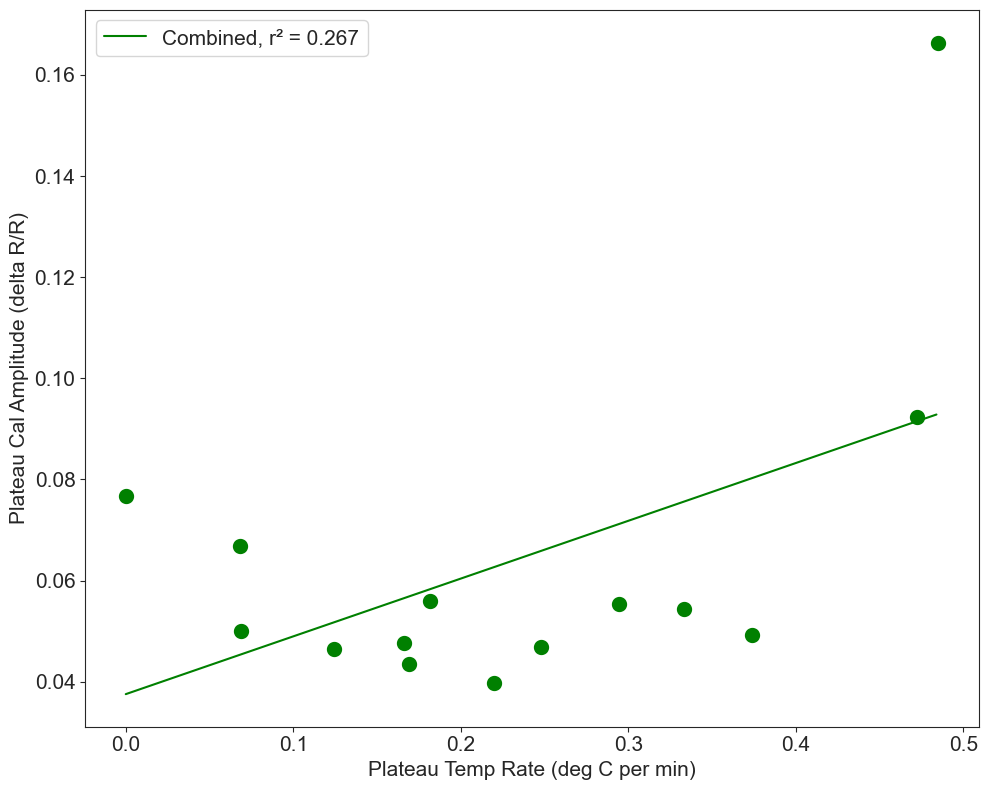

These are the plateau time durations (s):  [12.616, 48.260000000000005, 30.44199999999995, 33.58499999999998, 43.212000000000046, 69.284, 29.805999999999926, 40.8069999999999, 41.62799999999993, 32.86000000000013, 36.02799999999999, 35.096000000000004, 64.9029999999999, 46.88300000000004]


In [ ]:
# All COMBINED - Amplitude VS Deriv
combined_plateau_temp_rates = plateau_temp_rates_steep_3_4_20 + plateau_temp_rates_steep_3_5_20 + plateau_temp_rates_shallow_2_5_20_r1
combined_plateau_amplitude_cal = plateau_amplitude_steep_3_4_20 + plateau_amplitude_steep_3_5_20 + plateau_amplitude_shallow_2_5_20_r1
combined_plateau_durations = plateau_durations_steep_3_4_20 + plateau_durations_steep_3_5_20 + plateau_durations_2_5_20_r1

model = np.polyfit(combined_plateau_temp_rates, combined_plateau_amplitude_cal, 1)
predict = np.poly1d(model)
from sklearn.metrics import r2_score
r2 = r2_score(combined_plateau_amplitude_cal, predict(combined_plateau_temp_rates))

x_lin_reg = np.arange(min(combined_plateau_temp_rates), max(combined_plateau_temp_rates), 0.001)
y_lin_reg = predict(x_lin_reg)

plt.clf()
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize=(10,8))
ax1 = plt.subplot(1,1,1)
ax1.scatter(combined_plateau_temp_rates, combined_plateau_amplitude_cal, c='g', lw=5)
ax1.plot(x_lin_reg,y_lin_reg, c='g', label = f'Combined, r² = {r2:.3f}')
ax1.legend(fontsize=15)
ax1.tick_params(axis='y', labelsize=15)
ax1.tick_params(axis='x', labelsize=15)
#ax1.set_xlim(xmin=0.05,xmax=0.65)
#ax1.set_ylim(ymin=0.1, ymax=0.5)
ax1.set_ylabel('Plateau Cal Amplitude (delta R/R)', fontsize=15)
ax1.set_xlabel('Plateau Temp Rate (deg C per min)', fontsize=15)
plt.tight_layout()
#plt.savefig('Z:/Malcom/Freely_Moving_Folder_FromML_PC/Plateaus_moreLabeling_AmplitudeAnalysis/Combined_All_Plats_Amps_vs_Deriv.svg', dpi=600, bbox_inches='tight')
plt.show()
plt.close()

# These printed values are plugged into Prism for final graphing, see the file "Plateau Duration"
print("These are the plateau time durations (s): ", combined_plateau_durations)

In [ ]:
# Splitting amplitudes based on thresholding derivative or mean cal
# These printed values are plugged into GraphPad prism for statistical analysis, see the file "Plateau_Amplitude_Binned"

import numpy as np
# choose your threshold (here we use the median of `derivatives`)
thresh_deriv_based = np.median(combined_plateau_temp_rates)
thresh_mean_based = np.median(combined_plateau_mean_cal)

# convert to arrays for masking
amps = np.array(combined_plateau_amplitude_cal)
derivs = np.array(combined_plateau_temp_rates)
means = np.array(combined_plateau_mean_cal)

# create masks
low_mask_deriv_based  = derivs <= thresh_deriv_based
high_mask_deriv_based = derivs >  thresh_deriv_based

low_mask_mean_based  = means <= thresh_mean_based
high_mask_mean_based = means >  thresh_mean_based

# split into two lists
low_amplitudes_deriv_based  = amps[low_mask_deriv_based].tolist()
high_amplitudes_deriv_based = amps[high_mask_deriv_based].tolist()

low_amplitudes_mean_based  = amps[low_mask_mean_based].tolist()
high_amplitudes_mean_based = amps[high_mask_mean_based].tolist()

print("Deriv Threshold =", thresh_deriv_based)
print("Low‑derivative amplitudes:",  low_amplitudes_deriv_based)
print("High‑derivative amplitudes:", high_amplitudes_deriv_based)
print("\nCa Mean Threshold =", thresh_mean_based)
print("Low‑mean amplitudes:",  low_amplitudes_mean_based)
print("High‑mean amplitudes:", high_amplitudes_mean_based)

Deriv Threshold = 0.20065916789244928
Low‑derivative amplitudes: [0.05599284811242171, 0.05004381591372606, 0.07668408651945405, 0.06682172736420482, 0.046540856443127276, 0.04771805577114199, 0.043580763551358315]
High‑derivative amplitudes: [0.04687447563766847, 0.039709702212869416, 0.0553618841980881, 0.054442479962647616, 0.09236792633367014, 0.1663870174225012, 0.0493466814612421]

Ca Mean Threshold = 0.2909314831719181
Low‑mean amplitudes: [0.039709702212869416, 0.05599284811242171, 0.05004381591372606, 0.07668408651945405, 0.06682172736420482, 0.046540856443127276, 0.043580763551358315]
High‑mean amplitudes: [0.04687447563766847, 0.0553618841980881, 0.054442479962647616, 0.09236792633367014, 0.1663870174225012, 0.0493466814612421, 0.04771805577114199]


# Calc AVG Resp Function & Fitting Exponential 

In [50]:
def calc_temp_deriv(experiment_Time, experiment_Temp):
    step = 10

    Temp_downsamp = [experiment_Temp[0]]
    Time_downsamp = [experiment_Time[0]]
    for i in range(step+1,len(experiment_Temp),step):
        Temp_downsamp.append(experiment_Temp[i])
        Time_downsamp.append(experiment_Time[i])

    temp_deriv_downsamp = np.append([0], np.diff(Temp_downsamp))
    temp_deriv_downsamp_per_sec = [0]
    for i in range(1, len(temp_deriv_downsamp)):
        temp_deriv_downsamp_per_sec.append(temp_deriv_downsamp[i]/(Time_downsamp[i]-Time_downsamp[i-1]))

    temp_deriv_downsamp_per_sec_interp = [temp_deriv_downsamp_per_sec[0]]
    for i in range(1,len(temp_deriv_downsamp_per_sec)):
        for j in range(step):
            temp_deriv_downsamp_per_sec_interp.append(temp_deriv_downsamp_per_sec[i-1]+((temp_deriv_downsamp_per_sec[i]-temp_deriv_downsamp_per_sec[i-1])/step)*j)
    final_temp_deriv_downsamp_per_sec = temp_deriv_downsamp_per_sec[len(temp_deriv_downsamp_per_sec)-1]
    dum = temp_deriv_downsamp_per_sec_interp[len(temp_deriv_downsamp_per_sec_interp)-1]
    add_step = (final_temp_deriv_downsamp_per_sec - dum)/(len(temp_deriv_downsamp_per_sec)-max(range(step+1,len(temp_deriv_downsamp_per_sec),step)))
    for i in range((len(experiment_Temp)-max(range(step+1,len(experiment_Temp),step)))):
        dum += add_step
        temp_deriv_downsamp_per_sec_interp.append(dum)
        
    return temp_deriv_downsamp_per_sec_interp

In [54]:
# GLM function replacing the matlab calls with numpy commands

def calc_plot_GLM_tempDeriv_nonzero(experiment_DeltaR, experiment_Time, experiment_Temp, experiment_Temp_Deriv, model_plot, rep_name, stim_window , plt_resp, step = 10 ):
    try:
        #stim_window = 1000 #tenths of seconds
        #step = 1 #interval of modeled data
        responses = []
        stimuli = []
        times = []
        times_b4Resp = []
        
        for i in range(stim_window,len(experiment_DeltaR)):
            responses.append(float(experiment_DeltaR[i]))
            dum = []
            dum_times = []
            dum_times_b4Resp = [] #read as "time bofore th current response"
            
            for j in range((i-stim_window),i,step):
                if float(experiment_Temp_Deriv[j]) > 0.0000001:
                    dum.append(float(experiment_Temp_Deriv[j]))
                else:
                    dum.append(0.0)
                dum_times.append(float(experiment_Time[j])-float(experiment_Time[(i-stim_window)]))
                dum_times_b4Resp.append( float(experiment_Time[i]) - float(experiment_Time[j]) )
            stimuli.append(dum)
            times.append(dum_times)
            times_b4Resp.append(dum_times_b4Resp)

        np_stim = np.array(stimuli)
        np_resp = np.array(responses).reshape(-1, 1)

        solution_vector = np.linalg.lstsq(np_stim, np_resp, rcond=None)[0]
        resp_function = solution_vector.flatten().tolist()

        resp_function_reverse = []
        resp_function_forward = []
        resp_function_seconds = []
        resp_function_seconds_b4Resp = []
        
        for i in range( len(resp_function) ):
            resp_function_reverse.append( float(resp_function[ ( len(resp_function)-i-1 ) ] ) )
            resp_function_forward.append( float(resp_function[i]) )
            
            dum_times = []
            dum_times_b4Resp = []
            for j in range(len(times)):
                dum_times.append(times[j][i])
                dum_times_b4Resp.append(times_b4Resp[j][i])
            resp_function_seconds.append(np.mean(dum_times))
            resp_function_seconds_b4Resp.append(np.mean(dum_times_b4Resp))
            
        resp_function_seconds_rev = []
        resp_function_seconds_b4Resp_rev = []
        for i in range(len(resp_function_seconds)):
            resp_function_seconds_rev.append(float(resp_function_seconds[(len(resp_function_seconds) - i - 1)]))
            resp_function_seconds_b4Resp_rev.append(float(resp_function_seconds_b4Resp[(len(resp_function_seconds_b4Resp) - i - 1)]))
            
            
        resp_function_reverse = np.array(resp_function_reverse).reshape(-1,1)
        resp_function_forward = np.array(resp_function_forward).reshape(-1,1)
        if plt_resp == True:
            
            plt.clf()
            plt.figure(figsize=(3,3), dpi=300)
            plt.plot(resp_function_seconds_b4Resp_rev,resp_function_reverse)
            plt.xlabel('Time Before Response (s)')
            plt.ylabel('Arbitrary Units')
            plt.title(rep_name)
            plt.tight_layout()
            plt.show()
            plt.close()
        
        try:
            modeled_afd_response = []
            for i in range(stim_window,len(experiment_DeltaR)):
                dum = []
                for j in range((i-stim_window),i,step):
                    if float(experiment_Temp_Deriv[j]) > 0.0000001:
                        dum.append(float(experiment_Temp_Deriv[j]))
                    else:
                        dum.append(0.0)
                dum_array = np.array(dum)
                modeled_afd_response.append(float(np.matmul(dum_array,resp_function_forward)))
        except Exception as e:
            print(f"Couldn't model responses where stim_window={stim_window}: ", e)
            
        if model_plot == True:    
            plt.clf()
            plt.figure(figsize=(5,4),dpi=300)#plt.ylim(0,1)
            ax1 = plt.subplot(1,1,1)
            ax1.plot(experiment_Time, experiment_Temp, 'k', lw=2)
            ax1.legend(labels=['Temp.'], fontsize=12, frameon=False)
            ax1.set_ylabel('Temperature (deg C)', fontsize=15)
            ax1.set_xlabel('Time (s)', fontsize=15)
            ax1.set_ylim(min(experiment_Temp),max(experiment_Temp))
            ax1.set_xlim(0, max(experiment_Time))
            ax1.tick_params(axis = 'both', labelsize=15)
            ax2 = ax1.twinx()
            ax2.plot(experiment_Time[stim_window:],experiment_DeltaR[stim_window:], 'r', lw=2)
            ax2.plot(experiment_Time[stim_window:],modeled_afd_response, 'b', lw=2)
            ax2.legend(labels=['Real AFD Activity', 'Model Prediction'], fontsize=12, loc='upper center', frameon=False)
            ax2.set_ylabel('AFD GCaMP Signal (delta R/R)', fontsize=15)
            ax2.set_xlabel('Time (s)', fontsize=15)
            ax2.set_ylim(0,0.6)
            ax2.set_xlim(0, max(experiment_Time))
            ax2.tick_params(axis = 'both', labelsize=15)
            plt.show()
            plt.close()

        #print(modeled_afd_response)
        #print('Pearson R', pearsonr(experiment_DeltaR[stim_window:],modeled_afd_response)[0])    
        #print('MSE', mean_squared_error(experiment_DeltaR[stim_window:],modeled_afd_response))
    except Exception as e:
        print(f"GLM Function failed with stim window: {stim_window}:", e)
    return(modeled_afd_response, resp_function_forward, resp_function_seconds_b4Resp, pearsonr(experiment_DeltaR[stim_window:],modeled_afd_response)[0], mean_squared_error(experiment_DeltaR[stim_window:],modeled_afd_response))

In [56]:
temp_deriv_steep_3_4_20 = calc_temp_deriv(Time_steep_3_4_20, Temp_steep_3_4_20 )
temp_deriv_steep_3_5_20 = calc_temp_deriv(Time_steep_3_5_20, Temp_steep_3_5_20 )
temp_deriv_shallow_2_5_20_r1 = calc_temp_deriv(Time_shallow_2_5_20_r1, Temp_shallow_2_5_20_r1 )

model_plot = False
Steep_3_4_20_GLM_Model, Steep_3_4_20_GLM_Resp_Fun, Steep_3_4_20_RespFunct_timeb4resp, Steep_3_4_20_GLM_Model_Corr, Steep_3_4_20_GLM_Model_MSE = calc_plot_GLM_tempDeriv_nonzero(DeltaR_steep_3_4_20, Time_steep_3_4_20, Temp_steep_3_4_20, temp_deriv_steep_3_4_20, model_plot, rep_name = 'Steep 3_4_20', stim_window = 1250, plt_resp = False)
Steep_3_5_20_GLM_Model, Steep_3_5_20_GLM_Resp_Fun, Steep_3_5_20_RespFunct_timeb4resp, Steep_3_5_20_GLM_Model_Corr, Steep_3_5_20_GLM_Model_MSE = calc_plot_GLM_tempDeriv_nonzero(DeltaR_steep_3_5_20, Time_steep_3_5_20, Temp_steep_3_5_20, temp_deriv_steep_3_5_20, model_plot, rep_name = 'Steep 3_5_20', stim_window = 1250, plt_resp = False)
Shallow_2_5_20_r1_GLM_Model, Shallow_2_5_20_r1_GLM_Resp_Fun, Shallow_2_5_20_r1_RespFunct_timeb4resp, Shallow_2_5_20_r1_GLM_Model_Corr, Shallow_2_5_20_r1_GLM_Model_MSE = calc_plot_GLM_tempDeriv_nonzero(DeltaR_shallow_2_5_20_r1, Time_shallow_2_5_20_r1, Temp_shallow_2_5_20_r1, temp_deriv_shallow_2_5_20_r1, model_plot, rep_name = 'Shallow 2_5_20_r1', stim_window = 1250, plt_resp = False)


<Figure size 640x480 with 0 Axes>

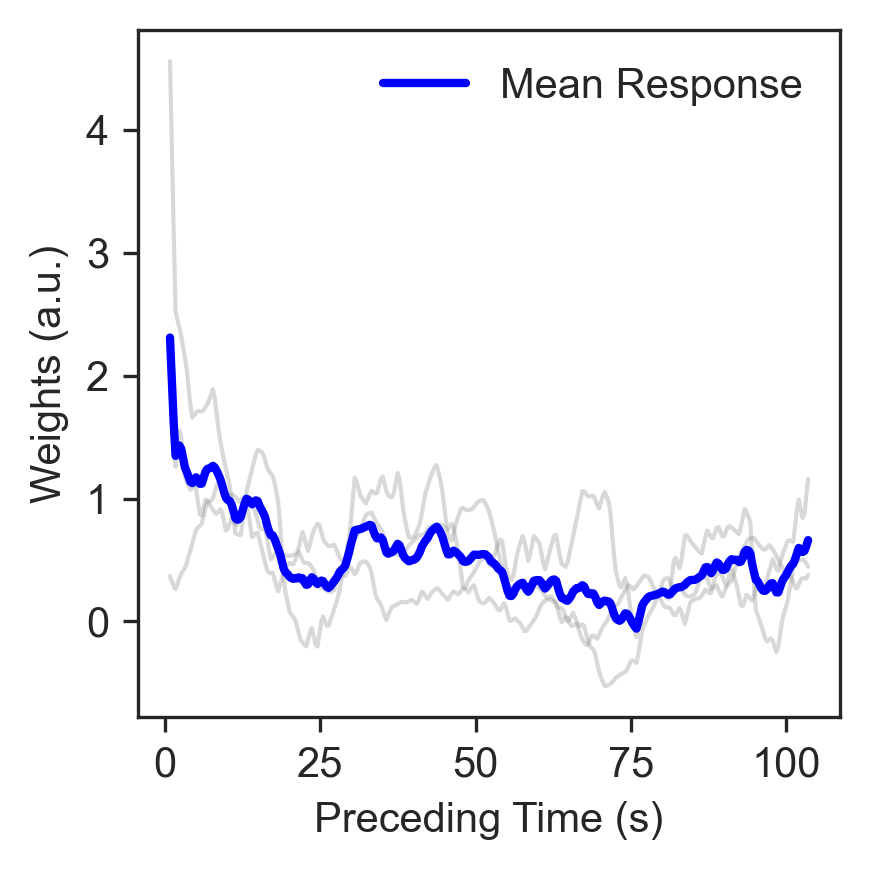

In [57]:
import numpy as np
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt

# Unpack results from your calc_plot_GLM_tempDeriv_nonzero calls
# Each gives: Model, Resp_Fun, RespFunct_timeb4resp, Corr, MSE
experiments = [
    (np.ravel( Steep_3_4_20_GLM_Resp_Fun ), Steep_3_4_20_RespFunct_timeb4resp),
    (np.ravel( Steep_3_5_20_GLM_Resp_Fun ), Steep_3_5_20_RespFunct_timeb4resp),
    (np.ravel( Shallow_2_5_20_r1_GLM_Resp_Fun ), Shallow_2_5_20_r1_RespFunct_timeb4resp)
]

# 1. Define a common time grid (seconds before response)
#    Use the min/max of your time arrays to avoid extrapolation too far
t_min = max([min(t) for _, t in experiments])   # safest common lower bound
t_max = min([max(t) for _, t in experiments])   # safest common upper bound
common_time = np.arange(t_min, t_max, 0.3)      # 0.3 s resolution

# 2. Interpolate each response function onto the common grid
interp_weights = []
for weights, times in experiments:
    f = interp1d(times, weights, kind='linear', bounds_error=False, fill_value="extrapolate")
    interp_weights.append( f(common_time) )

# 3. Average across experiments
average_resp_fun = np.mean(interp_weights, axis=0)

# 4. Plot all individual interpolated curves and the average
plt.clf()
plt.figure(figsize=(3,3), dpi=300)
for curve in interp_weights:
    plt.plot(common_time, curve, color='gray', alpha=0.3, linewidth=1)

plt.plot(common_time, average_resp_fun, color='blue', lw=2, label='Mean Response')

plt.xlabel('Preceding Time (s)')
plt.ylabel('Weights (a.u.)')
plt.legend(frameon=False)
plt.tight_layout()
#plt.savefig('C:/Users/dgmdi/OneDrive - Yale University/Documents\AFD Range of Thermal Perception/Figures/Figure 2/Response_funct_all_expts.svg', dpi=600, bbox_inches='tight') 
plt.show()
plt.close()



In [58]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


def expDecayFit_notForced(x, y):
    # --- model: single exponential, no offset ---
    def exp_decay(x, A, B):
        return A * np.exp(-B * x)

    # --- robust initial guesses ---
    # amplitude guess: use first point, or max if that seems safer
    if y.size == 0:
        raise ValueError("y is empty")
    A0 = float(y[0]) if np.isfinite(y[0]) else float(np.nanmax(y))
    # if A0 is negative (rare for weights), use max absolute value
    if A0 <= 0:
        # try using max positive value
        pos = y[y > 0]
        if pos.size:
            A0 = float(np.max(pos))
        else:
            # absolute fallback
            A0 = float(np.abs(np.min(y)) + 1e-6)

    # decay-rate guess B0: fit a line to log(y) on positive points if possible
    B0 = 0.1  # fallback
    mask_pos = (y > 0) & np.isfinite(y) & np.isfinite(x)
    if mask_pos.sum() >= 2:
        try:
            # linear fit to ln(y) vs x -> slope ~ -B
            m, c = np.polyfit(x[mask_pos], np.log(y[mask_pos]), 1)
            B0_candidate = -m
            if B0_candidate > 0:
                B0 = float(B0_candidate)
        except Exception:
            pass
    else:
        # as fallback, estimate from first drop if possible
        if np.isfinite(x[-1]) and (x[-1] - x[0]) > 0 and y[0] > 0:
            # crude estimate: assume y_end ~ y0 * exp(-B * T) -> B ~ -ln(y_end/y0)/T
            if y[-1] > 0 and y[-1] < y[0]:
                B0_try = -np.log(y[-1] / y[0]) / (x[-1] - x[0])
                if B0_try > 0:
                    B0 = float(B0_try)

    p0 = [A0, B0]

    # --- bounds: require non-negative amplitude and decay (you can relax B lower bound to small positive) ---
    lower_bounds = [0.0, 0.0]
    upper_bounds = [np.inf, np.inf]

    # --- fit with bounds (TRF solver used if bounds provided) ---
    try:
        popt, pcov = curve_fit(exp_decay, x, y, p0=p0, bounds=(lower_bounds, upper_bounds), maxfev=1000000)
    except Exception as e:
        # fallback: try unconstrained fit (LM) with p0
        try:
            popt, pcov = curve_fit(exp_decay, x, y, p0=p0, maxfev=1000000)
        except Exception as e2:
            raise RuntimeError("Exponential fit failed (both bounded and unconstrained)."
                            f" Last error: {e2}") from e2

    A_fit, B_fit = popt
    # covariance might be infinite or returned as inf if fit is poor
    with np.errstate(invalid='ignore'):
        perr = np.sqrt(np.diag(pcov)) if (pcov is not None and np.all(np.isfinite(np.diag(pcov)))) else np.array([np.nan, np.nan])

    # --- goodness-of-fit ---
    y_fit = exp_decay(x, *popt)
    
    ss_res = np.sum((y - y_fit) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

    # --- Plot ---
    plt.clf()
    plt.figure(figsize=(5,3), dpi=150)
    plt.plot(x, y, '-', color='C0', lw=2, label='Reversed avg response')
    plt.plot(x, y_fit, '--', color='C1', lw=2, label=f'Fit: A·exp(-B x)\nA={A_fit:.4g}±{perr[0]:.4g}, B={B_fit:.4g}±{perr[1]:.4g}\nR²={r2:.3f}')
    plt.xlabel('Lag (s)')
    plt.ylabel('Weights (a.u.)')
    plt.legend(frameon=False, fontsize=8)
    plt.tight_layout()
    plt.show()

    # --- print results ---
    print(f"A = {A_fit:.6g} ± {perr[0]:.6g}")
    print(f"B = {B_fit:.6g} ± {perr[1]:.6g}")
    print(f"R^2 = {r2:.6g}")
    return y_fit

<Figure size 640x480 with 0 Axes>

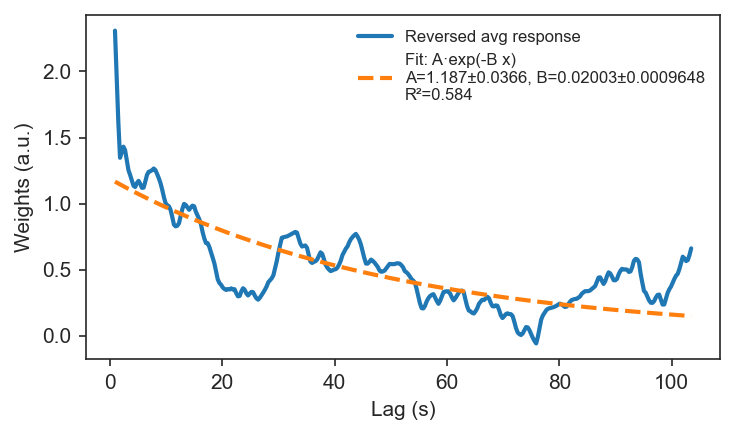

A = 1.187 ± 0.0366
B = 0.0200321 ± 0.000964825
R^2 = 0.584337


In [59]:
#AVG Resp Funct Fit
# --- Inputs (replace with your data) ---
# y: 1-D iterable (average response function reversed)
y = np.asarray(list(average_resp_fun), dtype=float)
x = np.asarray(common_time, dtype=float)
avg_fit = expDecayFit_notForced(x, y)

# 3_4_20 Plateau Analysis

In [15]:
def calc_delta_diff(Soma_Ratio_smoothed):
    """
    Returns a list where:
      - output[0] == Soma_Ratio_smoothed[0]
      - for t>0, output[t] = Soma_Ratio_smoothed[t] - Soma_Ratio_smoothed[t-1]
    """
    if len(Soma_Ratio_smoothed) == 0:
        return []

    #Delta = [Soma_Ratio_smoothed[0]]
    Delta = [0]
    for prev, curr in zip(Soma_Ratio_smoothed, Soma_Ratio_smoothed[1:]):
        Delta.append(curr - prev)
    return Delta

def calc_Delta(Soma_Ratio_smoothed):
    Delta_Soma_Ratio_smoothed = []
    rat_min = min(Soma_Ratio_smoothed)
    for i in Soma_Ratio_smoothed:
        Delta_Soma_Ratio_smoothed.append((i-rat_min)/rat_min)
    
    return(Delta_Soma_Ratio_smoothed)

Delta_Soma_Ratio = calc_Delta(Soma_Ratio_3_4_20_unsmoothed)
Soma_Ratio_smoothed = gaussian_filter1d(Soma_Ratio_3_4_20_unsmoothed, sigma=17)
Delta_Soma_Ratio_smoothed = calc_Delta(Soma_Ratio_smoothed)

inst_diff_Ratio = calc_delta_diff(Soma_Ratio_3_4_20_unsmoothed)
inst_diff_Ratio_smoothed = calc_delta_diff(Soma_Ratio_smoothed)
inst_diff_DeltaRatio = calc_delta_diff(Delta_Soma_Ratio)
inst_diff_DeltaRatio_smoothed = calc_delta_diff(Delta_Soma_Ratio_smoothed)

In [21]:
# Includes representative instantaneous temp deriv value
import numpy as np
from scipy.stats import shapiro
Delta_Soma_Ratio_smoothed = Delta_Soma_Ratio

# — 1) Build plateau_metrics —
plateau_metrics = {}
for idx, (s_i, e_i) in enumerate(plateaus_steep_3_4_20, start=1):
    derivs = [
        dT / dt for dT, dt in zip(
            np.diff(Temp_steep_3_4_20[s_i:e_i]),
            np.diff(Time_steep_3_4_20[s_i:e_i])
        )
    ]
    # normality test
    stat, p_val = shapiro(derivs)  
    if p_val > 0.05:
        repr_deriv = np.mean(derivs)
    else:
        repr_deriv = np.median(derivs)

    plateau_metrics[f"plat_{idx}"] = {
        "Temperature": Temp_steep_3_4_20[s_i:e_i],
        "Xpos": Xcoord_steep_3_4_20[s_i:e_i],
        "Norm_Xpos": Xcoord_Norm_steep_3_4_20[s_i:e_i],
        "Ypos": Ycoord_steep_3_4_20[s_i:e_i],
        "Time": Time_steep_3_4_20[s_i:e_i],
        "Calcium": Delta_Soma_Ratio_smoothed[s_i:e_i],
        "inst_diff_Ca": inst_diff_DeltaRatio[s_i:e_i],
        "deltaT_deltat_min": 60*(Temp_steep_3_4_20[e_i] - Temp_steep_3_4_20[s_i])/(Time_steep_3_4_20[e_i] - Time_steep_3_4_20[s_i]),
        "Mean_Ca": np.mean(Delta_Soma_Ratio_smoothed[s_i:e_i]),
        "diff_T": np.diff(Temp_steep_3_4_20[s_i:e_i]),
        "diff_t": np.diff(Time_steep_3_4_20[s_i:e_i]),
        "inst_Temp_deriv": [0] + derivs,
        "repr_inst_Temp_deriv": repr_deriv,
        "start_ind":   s_i,
        "end_ind":     e_i,
        "start_time":  Time_steep_3_4_20[s_i],
        "end_time":    Time_steep_3_4_20[e_i],
    }

# — 2) Build pos_runs_metrics —
pos_runs_metrics = {}
for idx, run_range in enumerate(run_east_video_steep_3_4_20, start=1):
    raw_s, raw_e = run_range
    s_i, e_i = find_start_stop((raw_s, raw_e,), Frames_steep_3_4_20)

    derivs = [
        dT / dt for dT, dt in zip(
            np.diff(Temp_steep_3_4_20[s_i:e_i]),
            np.diff(Time_steep_3_4_20[s_i:e_i])
        )
    ]
    # normality test
    stat, p_val = shapiro(derivs)
    if p_val > 0.05:
        repr_deriv = np.mean(derivs)
    else:
        repr_deriv = np.median(derivs)

    pos_runs_metrics[f"run_{idx}"] = {
        "Temperature": Temp_steep_3_4_20[s_i:e_i],
        "Xpos": Xcoord_steep_3_4_20[s_i:e_i],
        "Norm_Xpos": Xcoord_Norm_steep_3_4_20[s_i:e_i],
        "Ypos": Ycoord_steep_3_4_20[s_i:e_i],
        "Time": Time_steep_3_4_20[s_i:e_i],
        "Calcium": Delta_Soma_Ratio_smoothed[s_i:e_i],
        "inst_diff_Ca": inst_diff_DeltaRatio[s_i:e_i],
        "deltaT_deltat_min": 60*(Temp_steep_3_4_20[e_i] - Temp_steep_3_4_20[s_i])/(Time_steep_3_4_20[e_i] - Time_steep_3_4_20[s_i]),
        "Mean_Ca": np.mean(Delta_Soma_Ratio_smoothed[s_i:e_i]),
        "diff_T": np.diff(Temp_steep_3_4_20[s_i:e_i]),
        "diff_t": np.diff(Time_steep_3_4_20[s_i:e_i]),
        "inst_Temp_deriv": [0] + derivs,
        "repr_inst_Temp_deriv": repr_deriv,
        "start_ind":   s_i,
        "end_ind":     e_i,
        "start_time":  Time_steep_3_4_20[s_i],
        "end_time":    Time_steep_3_4_20[e_i],
    }

# — 3) Map each plateau to ALL overlapping runs —
plateau_to_runs = {}
for p_key, p in plateau_metrics.items():
    t0_p, t1_p = p["start_time"], p["end_time"]
    overlapping = []
    for r_key, r in pos_runs_metrics.items():
        t0_r, t1_r = r["start_time"], r["end_time"]
        if (t0_p <= t1_r) and (t0_r <= t1_p):
            overlapping.append(r_key)
    plateau_to_runs[p_key] = overlapping

# — 4) Display the mapping and repr_deriv values —
for p_key, runs in plateau_to_runs.items():
    plat_repr = plateau_metrics[p_key]["repr_inst_Temp_deriv"]
    print(f"{p_key}: repr_inst_Temp_deriv = {plat_repr:.3f}", end=" → ")
    if runs:
        run_strs = []
        for r_key in runs:
            r_repr = pos_runs_metrics[r_key]["repr_inst_Temp_deriv"]
            run_strs.append(f"{r_key} (repr={r_repr:.3f})")
        print("overlaps with", ", ".join(run_strs))
    else:
        print("no overlapping runs")


plat_1: repr_inst_Temp_deriv = 0.004 → overlaps with run_2 (repr=0.005), run_3 (repr=0.008)
plat_2: repr_inst_Temp_deriv = 0.004 → overlaps with run_6 (repr=0.007), run_7 (repr=0.008), run_8 (repr=0.007)
plat_3: repr_inst_Temp_deriv = 0.002 → overlaps with run_9 (repr=0.009), run_10 (repr=0.008), run_11 (repr=0.006)
plat_4: repr_inst_Temp_deriv = 0.001 → overlaps with run_13 (repr=-0.005), run_14 (repr=0.002)
plat_5: repr_inst_Temp_deriv = 0.002 → overlaps with run_16 (repr=0.007), run_17 (repr=0.003), run_18 (repr=0.004), run_19 (repr=0.004)


In [ ]:
from scipy.signal import gaussian, filtfilt
smooth_factor = 0
Ca_smooth_factor = 15
M = smooth_factor*6
M_Ca = smooth_factor*6
if M % 2 == 0:
    M = M + 1
if M_Ca % 2 == 0:
    M_Ca = M_Ca + 1
kernel = gaussian(M=M, std=smooth_factor)
kernel_Ca = gaussian(M=M_Ca, std=Ca_smooth_factor)
kernel /= kernel.sum()
kernel_Ca /= kernel_Ca.sum()
run_key = "plat_5" # ~~~~~~~~~~~~~~~~~~~~~~~~~ >>>>>>>>>>>>>>>>>>>>>>>>>>> SPECIFY THE PLATEAU
metrics = plateau_metrics
method_filtfilt = False
time_smooth = "No"
if smooth_factor > 0:
    if method_filtfilt == False:
        T = np.asarray(  gaussian_filter1d(  metrics[run_key]["Temperature"], sigma = smooth_factor  ),  dtype=float)
        Y = np.asarray(  gaussian_filter1d(  metrics[run_key]["Ypos"], sigma = smooth_factor  ),         dtype=float)
        X = np.asarray(  gaussian_filter1d(  metrics[run_key]["Xpos"], sigma = smooth_factor  ),         dtype=float)
        Ca= np.asarray(  gaussian_filter1d(  metrics[run_key]["Calcium"], sigma = Ca_smooth_factor  ),      dtype=float)
        Time = np.asarray(  gaussian_filter1d(  metrics[run_key]["Time"], sigma = smooth_factor  ),      dtype=float)
        Norm_X = np.asarray(  gaussian_filter1d(  metrics[run_key]["Norm_Xpos"], sigma = smooth_factor  ),      dtype=float)
        dCa = np.asarray(  gaussian_filter1d(  metrics[run_key]["inst_diff_Ca"], sigma = smooth_factor  ),      dtype=float)
        dTdt =np.asarray(  gaussian_filter1d(  metrics[run_key]["inst_Temp_deriv"], sigma = smooth_factor  ),      dtype=float)
        dTdt_ofSmf = gaussian_filter1d( [0] + [dT / dt for dT, dt in zip( np.diff(T), np.diff(Time) ) ], sigma = smooth_factor)
    if method_filtfilt == True:
        T = np.asarray(    filtfilt( kernel, [1,0], metrics[run_key]["Temperature"]),  dtype=float)
        Y = np.asarray(    filtfilt( kernel, [1,0], metrics[run_key]["Ypos"]),         dtype=float)
        X = np.asarray(    filtfilt( kernel, [1,0], metrics[run_key]["Xpos"]),         dtype=float)
        Ca= np.asarray(    filtfilt( kernel_Ca, [1,0], metrics[run_key]["Calcium"]),      dtype=float)
        Time = np.asarray(    filtfilt( kernel, [1,0], metrics[run_key]["Time"]),      dtype=float)
        Norm_X = np.asarray(    filtfilt( kernel, [1,0], metrics[run_key]["Norm_Xpos"]),      dtype=float)
        dCa = np.asarray(    filtfilt( kernel, [1,0], metrics[run_key]["inst_diff_Ca"]),      dtype=float) 
        dTdt = np.asarray(    filtfilt( kernel, [1,0], metrics[run_key]["inst_Temp_deriv"]),      dtype=float)
        dTdt_ofSmf = filtfilt( kernel, [1,0], [0] + [dT / dt for dT, dt in zip( np.diff(T), np.diff(Time) ) ] )
else:
    T = np.asarray(   metrics[run_key]["Temperature"] ,  dtype=float)
    Y = np.asarray(   metrics[run_key]["Ypos"] ,         dtype=float)
    X = np.asarray(   metrics[run_key]["Xpos"] ,         dtype=float)
    Ca= np.asarray(   metrics[run_key]["Calcium"] ,      dtype=float)
    Time = np.asarray(   metrics[run_key]["Time"] ,      dtype=float)
    Norm_X = np.asarray(   metrics[run_key]["Norm_Xpos"] ,      dtype=float)
    dCa = np.asarray(   metrics[run_key]["inst_diff_Ca"] ,      dtype=float)
    dTdt = np.asarray(   metrics[run_key]["inst_Temp_deriv"] ,      dtype=float)

if time_smooth == "No":
    Time = np.asarray(   metrics[run_key]["Time"] ,      dtype=float)
# -------------------------------------------------------------------------------------------------------------------------
slope, intercept = np.polyfit(Norm_X, Y, 1)
θ = np.arctan(slope)    # in radians

θ_deg = np.degrees(θ)
γ_deg = 90 - θ_deg
γ = np.radians(90 - θ_deg)
Y_fit = slope * Norm_X + intercept
print(γ_deg)
print(θ_deg)
print( γ_deg + θ_deg )
R = np.array([
    [ np.cos(θ),  np.sin(θ)],
    [-np.sin(θ),  np.cos(θ)]
])
R_vert = np.array([ #Rotates counterclockwise so that track doesnt oscillates along y, but fully on x
    [ np.cos(γ),  -np.sin(γ)],
    [ np.sin(γ),   np.cos(γ)]
])

coords = np.vstack([Norm_X, Y])          # shape (2, N)
x_prime, y_prime = R.dot(coords)    # each is length-N
x_prime_vert, y_prime_vert = R_vert.dot(coords)    # each is length-N

# Vert Rotation Calcium ------------------------------------

slope_Ca, intercept_Ca = np.polyfit(Time, Ca, 1)
θ_Ca = np.arctan(slope_Ca)    # in radians
θ_deg_Ca = np.degrees(θ_Ca)
if θ_deg_Ca < 0:
    γ_deg_Ca = abs(θ_deg_Ca) + 90
    γ_Ca = np.radians(γ_deg_Ca)
else:
    γ_deg_Ca = 90 - θ_deg_Ca 
    γ_Ca = np.radians(γ_deg_Ca)
R_Ca = np.array([
    [ np.cos(γ_Ca),  -np.sin(γ_Ca)],
    [np.sin(γ_Ca),  np.cos(γ_Ca)]
])
coords_Ca = np.vstack([Time, Ca])          # shape (2, N)
x_prime_Ca, y_prime_Ca = R_Ca.dot(coords_Ca)    # each is length-N
print("Now Ca")
print(slope_Ca)
print(θ_deg_Ca)
print(γ_deg_Ca)
print( γ_deg_Ca + θ_deg_Ca )




64.62970777631206
25.37029222368794
90.0
Now Ca
0.001151605486057808
0.06598210484685099
89.93401789515315
90.0


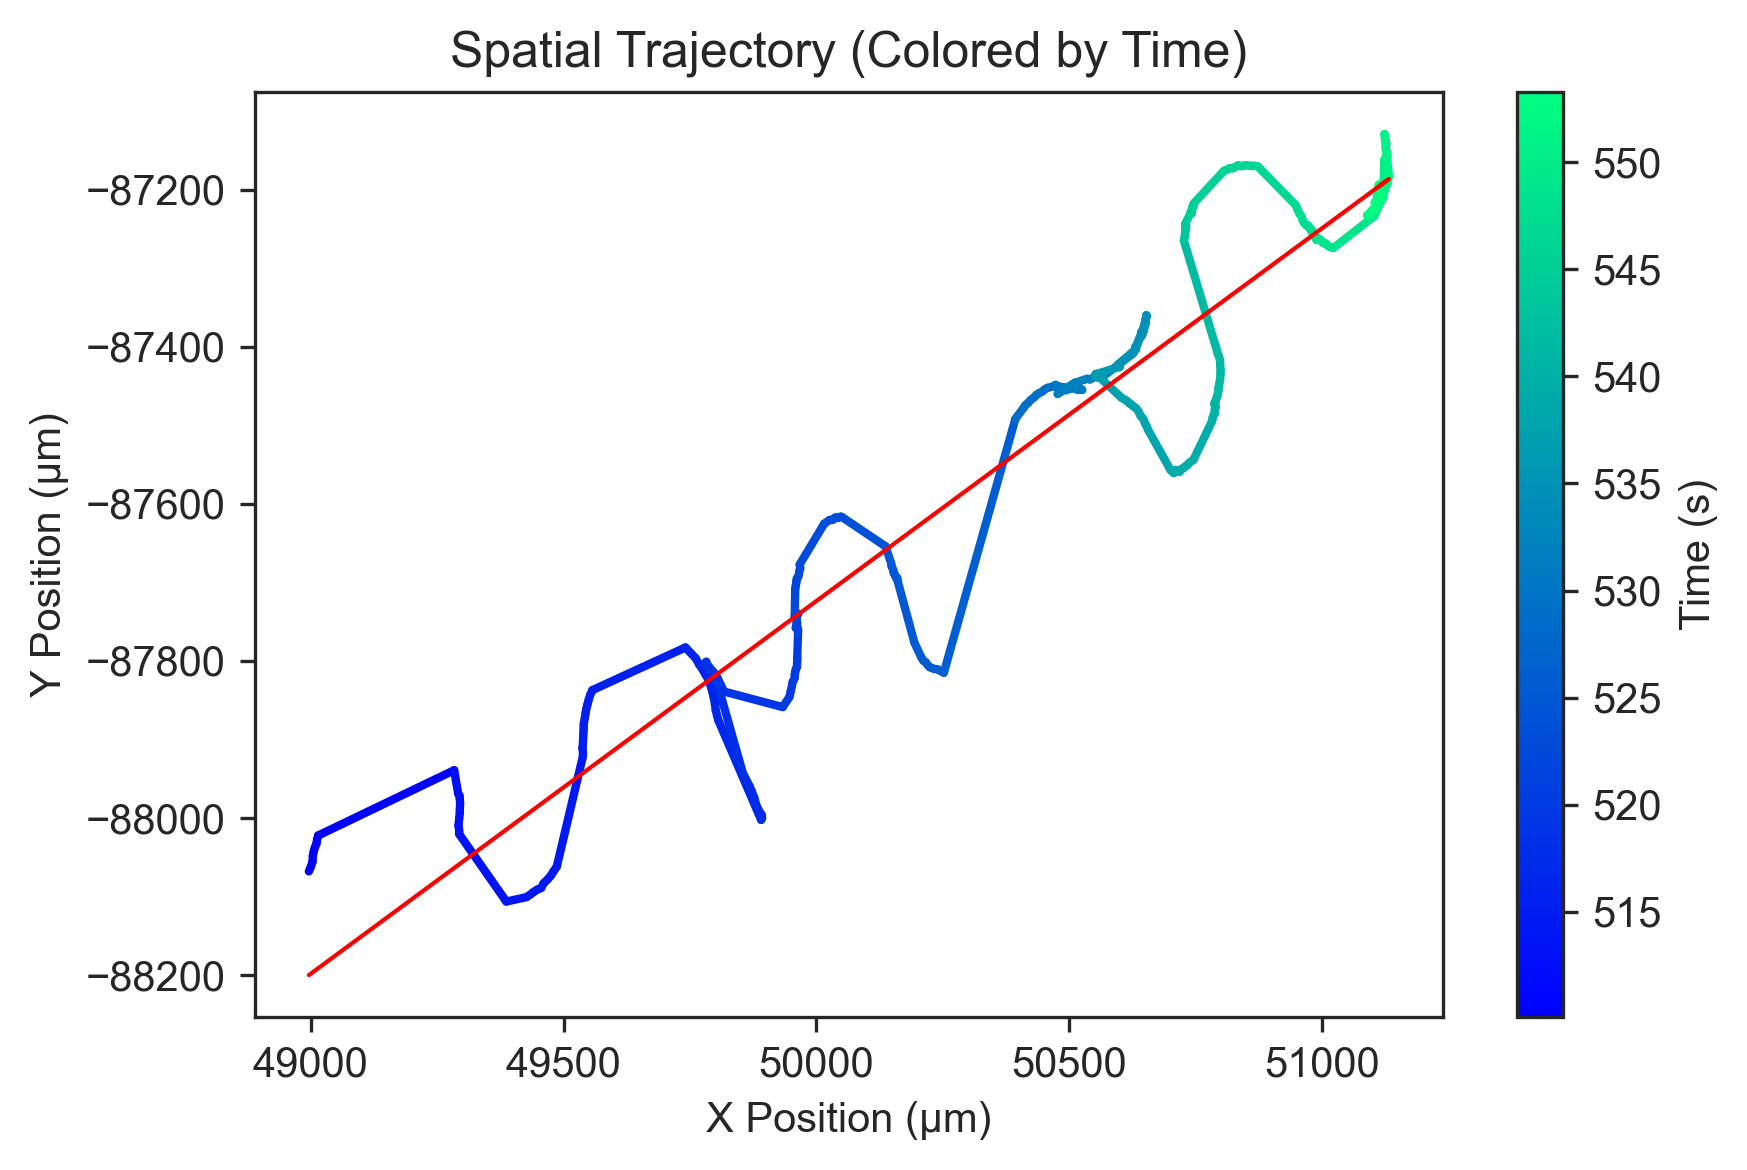

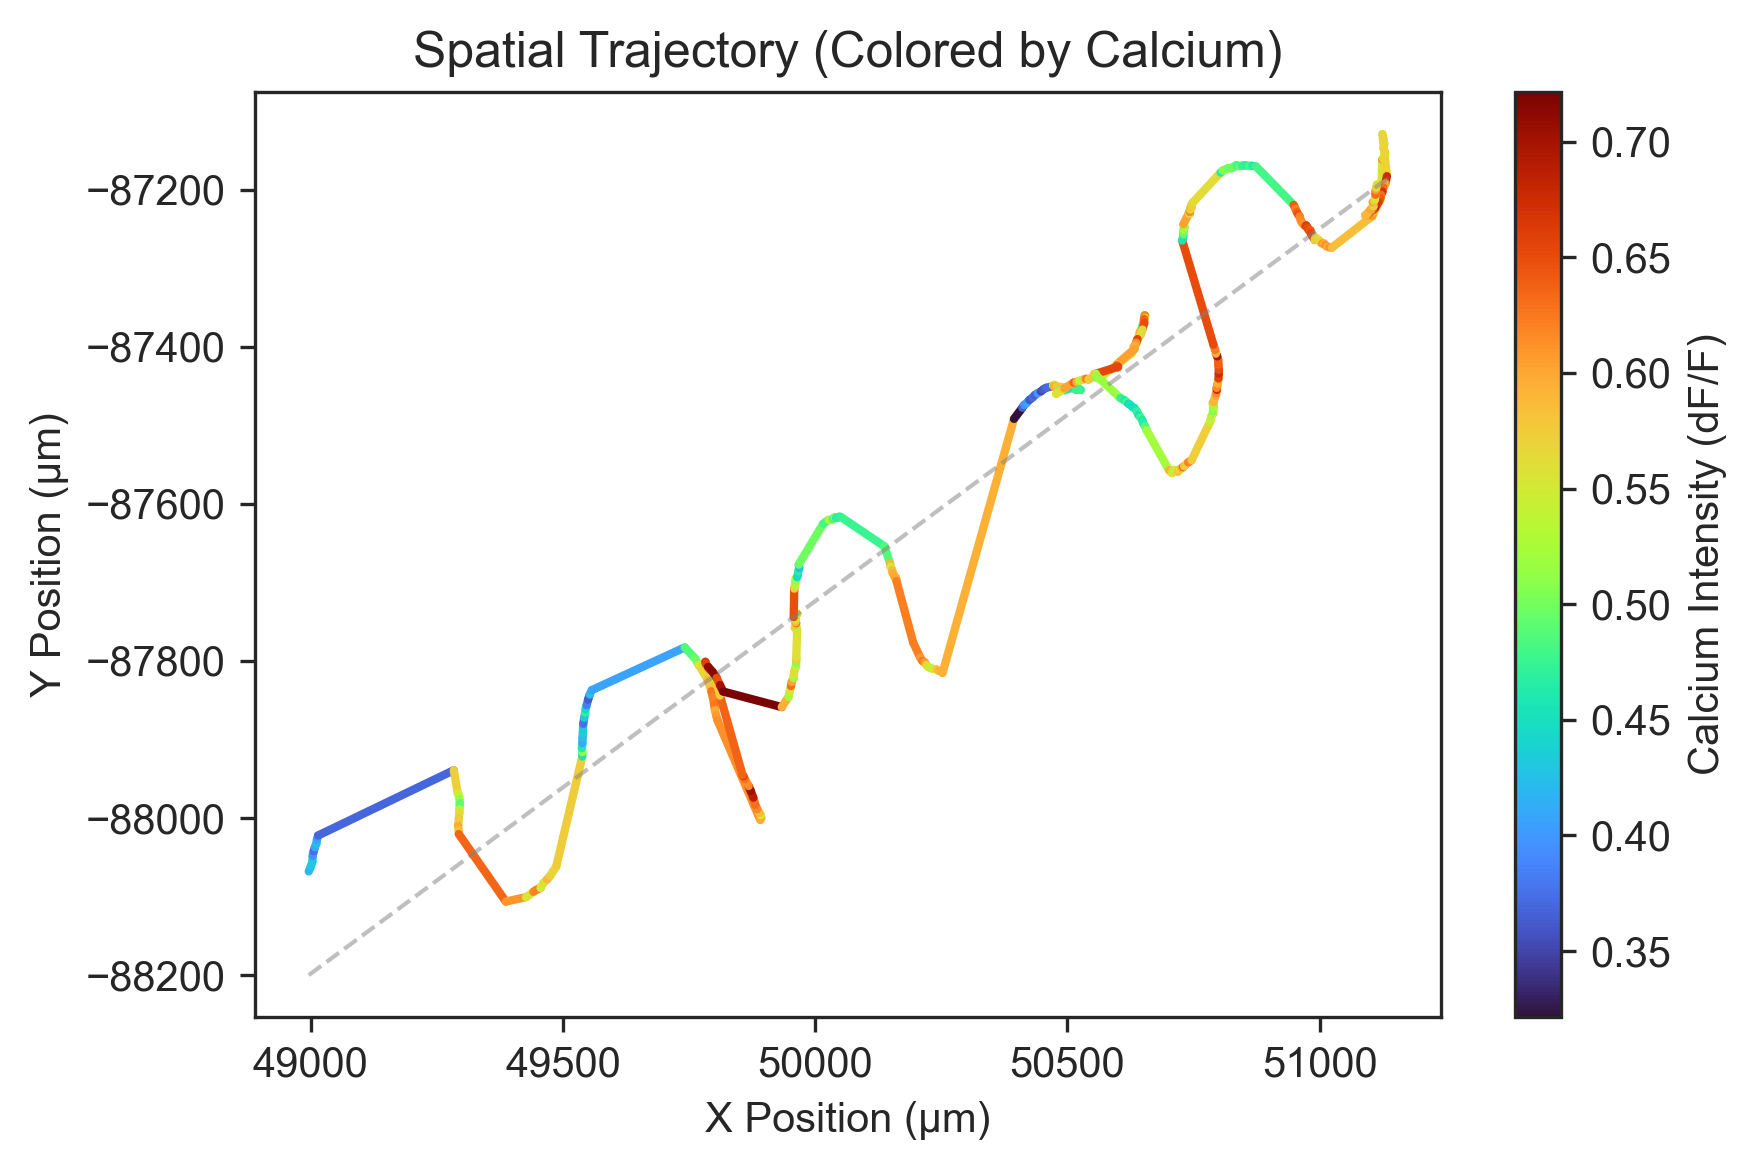

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
import matplotlib as mpl
from scipy.ndimage import gaussian_filter1d

# --- 1. PRE-PROCESSING (Existing) ---
Time_array = np.array(Time)
Cas = Ca

# Create points as a list of (x, y) pairs
points = np.array([x_prime_vert, y_prime_vert]).T.reshape(-1, 1, 2)
points_orig = np.array([Norm_X, Y]).T.reshape(-1, 1, 2)
ca_pts = np.array([Time, Cas]).T.reshape(-1, 1, 2)
Ca_vert_pts = np.array([x_prime_Ca, y_prime_Ca]).T.reshape(-1, 1, 2)

# Create segments for line collection (each segment is a pair of points)
segments = np.concatenate([points[:-1], points[1:]], axis=1)
segments_orig = np.concatenate([points_orig[:-1], points_orig[1:]], axis=1)
segments_Ca = np.concatenate([ca_pts[:-1], ca_pts[1:]], axis=1)
segments_Ca_vert = np.concatenate([Ca_vert_pts[:-1], Ca_vert_pts[1:]], axis=1)

# --- 2. SETUP TIME HEATMAP (Existing) ---
norm_time = Normalize(Time_array.min(), Time_array.max())
cmap_time = plt.get_cmap('winter')

lc_orig = LineCollection(segments_orig, cmap=cmap_time, norm=norm_time)

# Smooth out the Time Plot ---
lc_orig.set_capstyle('round')
lc_orig.set_joinstyle('round')
# ---------------------------------------

lc_orig.set_array(Time_array[:-1])
lc_orig.set_linewidth(2)


# --- 3. SETUP CALCIUM HEATMAP ---
# Normalize Calcium values
norm_ca = Normalize(Cas.min(), Cas.max())
cmap_ca = plt.get_cmap('turbo')  # 'turbo' is best for 0->Max intensity

# Create LineCollection for the Calcium plot using the SAME spatial segments
lc_calcium_spatial = LineCollection(segments_orig, cmap=cmap_ca, norm=norm_ca)

# ---Smooth out the Calcium Plot ---
lc_calcium_spatial.set_capstyle('round')
lc_calcium_spatial.set_joinstyle('round')
# ------------------------------------------

# Set the color-value using the Calcium array (matching segment length)
lc_calcium_spatial.set_array(Cas[:-1])
lc_calcium_spatial.set_linewidth(2)


# --- 4. PLOT 1: TIME HEATMAP ---
fig1, ax1 = plt.subplots(figsize=(6, 4), dpi=300)

ax1.plot(Norm_X, Y, lw=0, alpha=0) # Hidden base plot to set scales automatically
ax1.add_collection(lc_orig)
ax1.plot(Norm_X, Y_fit, c="r", lw=1, label='Fit')

cbar1 = plt.colorbar(lc_orig, ax=ax1, alpha=1.0) 
cbar1.set_label("Time (s)")
ax1.set_ylabel("Y Position (µm)")
ax1.set_xlabel("X Position (µm)")
ax1.set_title("Spatial Trajectory (Colored by Time)")
#plt.savefig('Z:/Malcom/ML_PC_Output/Plat_5_XvsY_wFit_wTimeHeat.svg', dpi=600, bbox_inches='tight')
plt.tight_layout()


# --- 5. PLOT 2: CALCIUM HEATMAP (New) ---
fig2, ax2 = plt.subplots(figsize=(6, 4), dpi=300)

# Same spatial X/Y limits, but color by Calcium
ax2.set_xlim(ax1.get_xlim())
ax2.set_ylim(ax1.get_ylim())

# Add the Calcium collection
ax2.add_collection(lc_calcium_spatial)
ax2.plot(Norm_X, Y_fit, c="gray", lw=1, linestyle='--', alpha=0.5) # Optional: Faint fit line

cbar2 = plt.colorbar(lc_calcium_spatial, ax=ax2, alpha=1.0)
cbar2.set_label("Calcium Intensity (dF/F)")
ax2.set_ylabel("Y Position (µm)")
ax2.set_xlabel("X Position (µm)")
ax2.set_title("Spatial Trajectory (Colored by Calcium)")
plt.tight_layout()
#plt.savefig('Z:/Malcom/ML_PC_Output/Plat_5_XvsY_wFit_wCaHeat.svg', dpi=600, bbox_inches='tight')

plt.show()

Position Model parameters:
  Amplitude         : 154.306
  ω (rad/s)         : 1.40257  (4π/9)
  f (Hz)            : 0.223225
  Phase φ (rad)     : 10.0864  (16π/5)

position model generated
Calcium Model parameters:
  Amplitude         : 0.0962834
  ω (rad/s)         : 1.43518  (4π/9)
  f (Hz)            : 0.228416
  Phase φ (rad)     : -1.38172  (16π/5)



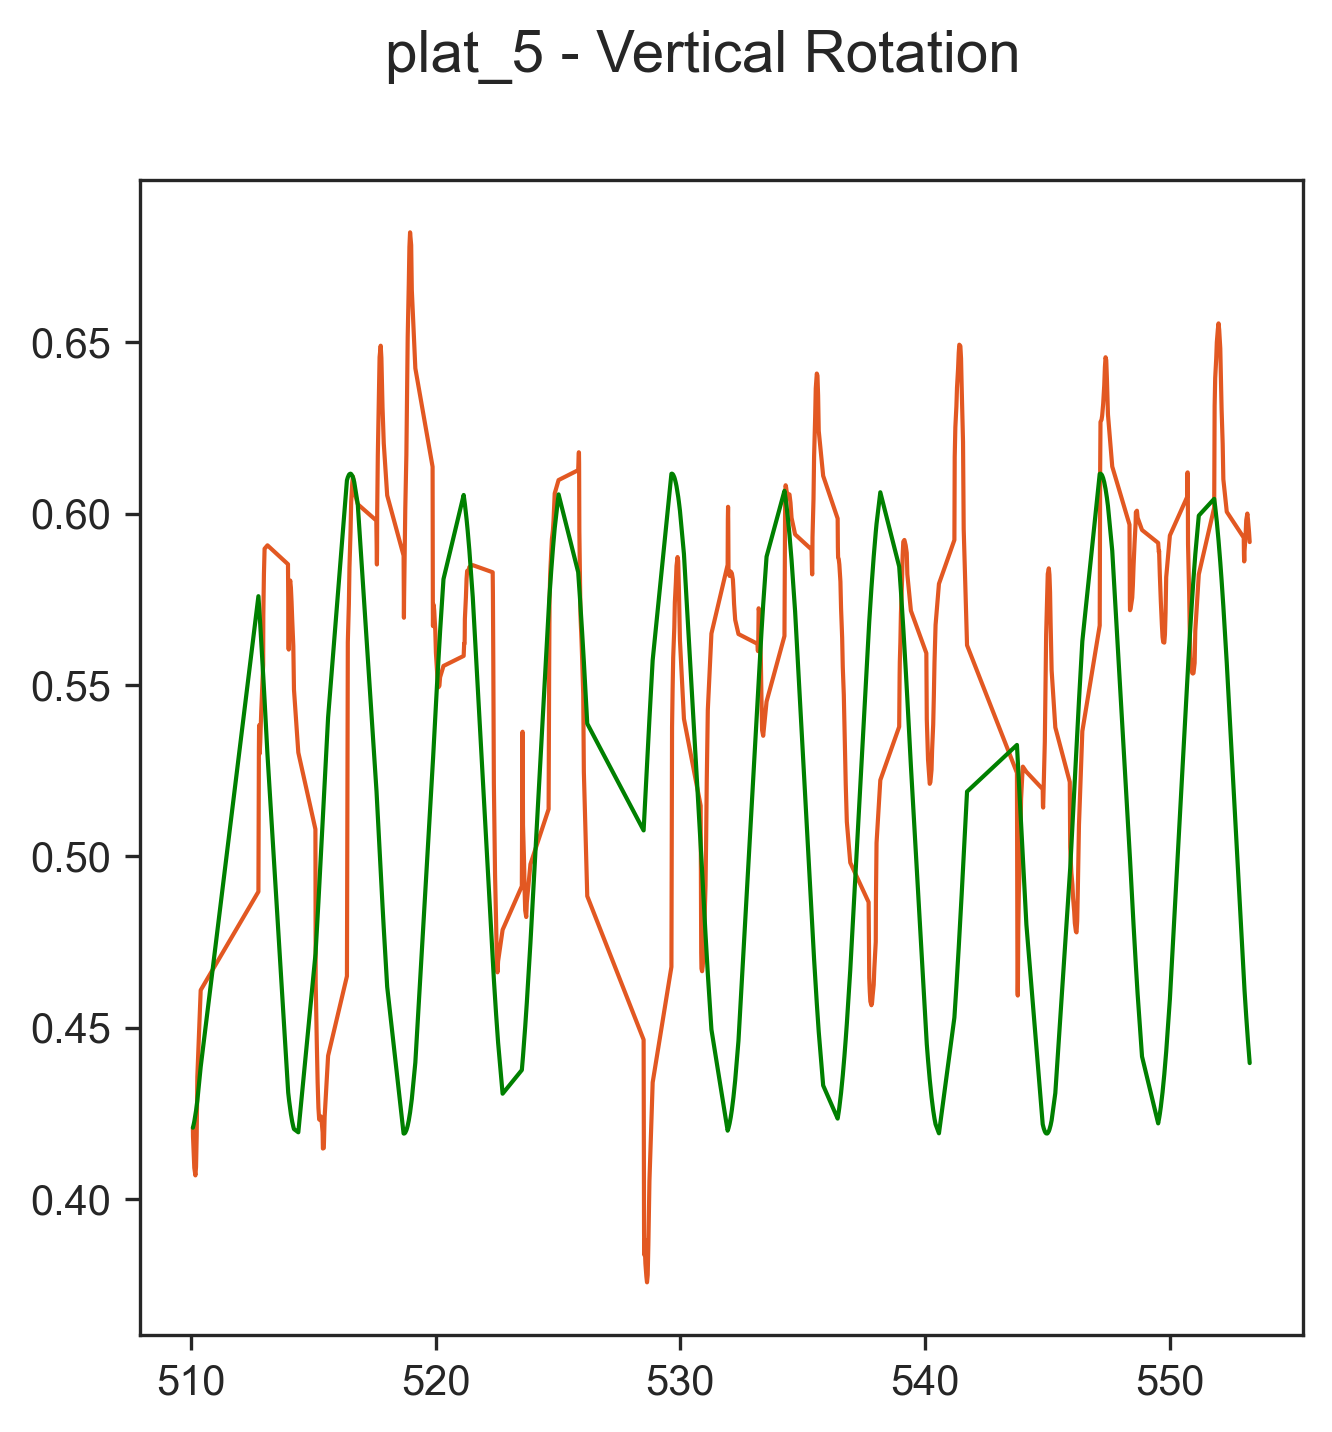

In [ ]:
# Find optimal model parameters for plateau event oscillations, stores params into dictionary
# 
from scipy.optimize import curve_fit
Xtra_smooth = 0 #std 15
Xtra_smooth_Ca = 2 #std 7
t_rel = Time - Time[0]
if Xtra_smooth > 0:
    X_prime_vert = gaussian_filter1d(  x_prime_vert, sigma = Xtra_smooth  )
else:
    X_prime_vert = x_prime_vert
if Xtra_smooth_Ca > 0 :
    Ca_sm = gaussian_filter1d( Ca, sigma = Xtra_smooth_Ca)

dXpr_dt = [0] + [ dY / dt for dY, dt in zip( np.diff( X_prime_vert ), np.diff(Time) ) ]
p="No"
# Helper to express a radian value as a π‐fraction string
from fractions import Fraction
def pi_fraction(val):
    frac = Fraction(val/np.pi).limit_denominator(12)
    n, d = frac.numerator, frac.denominator
    if n == 0:
        return "0"
    if d == 1:
        return f"{n}π"
    return f"{n}π/{d}"

if p == "Yes" or p == "yes":
    fig, ( ax5) = plt.subplots(1, 1, figsize=(5, 5), dpi=300)
    fig.suptitle(f"{run_key}", fontsize=14)
    ax5.plot(x_prime_vert, y_prime_vert, lw=1, color="blue", label="X Prime")
    plt.show()

def model_plat(t_rel, A,  ω, φ ):
    return y0  + A * np.sin(ω*t_rel + φ)

# MODELING POSITION ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# initial‐guesses
pos_mod = True
if pos_mod == True:
    n_wig = 8.0
    ω0   = 2*np.pi*n_wig / (Time[-1] - Time[0])
    φ0 = np.pi/2
    A0 = (X_prime_vert.max() - X_prime_vert.min()) / 2
    y0     = X_prime_vert[0] - A0 * np.sin(ω0*t_rel[0] + φ0)
    p0 = [ ω0, A0, φ0]

    p0_y = [ A0, ω0, φ0 ]
    bounds_y =  ( [0, -2*np.pi, -2*np.pi], [np.inf, 2*np.pi, 2*np.pi] )
    y0     = X_prime_vert[0] - A0 * np.sin(ω0*t_rel[0] + φ0)
    popt_y, _ = curve_fit(model_plat, t_rel, X_prime_vert, p0=p0_y, 
                        bounds=bounds_y,
                        method='trf', maxfev=20000)
    A_fit, ω_fit, φ_fit = popt_y
    A_fit = A_fit*2.5
    ω_fit = ω_fit*1.2
    φ_fit = φ_fit*3
    y0     = X_prime_vert[0] - A_fit * np.sin(ω_fit*t_rel[0] + φ_fit)

    f_fit = ω_fit / (2*np.pi)
    print("Position Model parameters:")
    print(f"  Amplitude         : {A_fit:.6g}")
    print(f"  ω (rad/s)         : {ω_fit:.6g}  ({pi_fraction(ω_fit)})")
    print(f"  f (Hz)            : {f_fit:.6g}")
    print(f"  Phase φ (rad)     : {φ_fit:.6g}  ({pi_fraction(φ_fit)})\n")

    model_plat_fitted = model_plat(t_rel, A_fit, ω_fit, φ_fit)
    print("position model generated")

# MODELING CALCIUM NOW ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
mod_Ca = True
def model_plat_Ca(t_rel, A_Ca,  ω_Ca, φ_Ca ):
    return y0_Ca  + A_Ca * np.sin(ω_Ca*t_rel + φ_Ca)
if mod_Ca == True:
    # initial‐guesses
    n_wig_Ca = 7
    ω0_Ca   = 2*np.pi*n_wig / (Time[-1] - Time[0])
    φ0_Ca = np.pi/6
    A0_Ca = (Ca_sm.max() - Ca_sm.min()) / 2
    y0_Ca     = Ca_sm[0] - A0_Ca * np.sin(ω0_Ca*t_rel[0] + φ0_Ca)
    p0_Ca = [ ω0_Ca, A0_Ca, φ0_Ca]

    p0_y_Ca = [ A0_Ca, ω0_Ca, φ0_Ca ]
    bounds_y =  ( [0, -2*np.pi, -2*np.pi], [np.inf, 2*np.pi, 2*np.pi] )

    popt_y_Ca, _ = curve_fit(model_plat_Ca, t_rel, Ca_sm, p0=p0_y_Ca, 
                        bounds=bounds_y,
                        method='trf', maxfev=10000)
    A_fit_Ca, ω_fit_Ca, φ_fit_Ca = popt_y_Ca
    A_fit_Ca = A_fit_Ca*2.5
    φ_fit_Ca = φ_fit_Ca*0.45
    y0_Ca     = Ca_sm[0] - A_fit_Ca * np.sin( ω_fit_Ca * t_rel[0] + φ_fit_Ca)

    f_fit_Ca = ω_fit_Ca / (2*np.pi)
    model_plat_fitted_Ca = model_plat_Ca(t_rel, A_fit_Ca, ω_fit_Ca, φ_fit_Ca)
    print("Calcium Model parameters:")
    print(f"  Amplitude         : {A_fit_Ca:.6g}")
    print(f"  ω (rad/s)         : {ω_fit_Ca:.6g}  ({pi_fraction(ω_fit)})")
    print(f"  f (Hz)            : {f_fit_Ca:.6g}")
    print(f"  Phase φ (rad)     : {φ_fit_Ca:.6g}  ({pi_fraction(φ_fit)})\n")

#~~~~~~~~~~~~~ PLOTTING~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
plot = "Yes"
both = "no"
only_Ca = True
only_Pos = False
only_models = False
if plot == "yes" or plot == "Yes":
    fig, ( ax5 ) = plt.subplots(1, 1, figsize=(5, 5), dpi=300)
    fig.suptitle(f"{run_key} - Vertical Rotation", fontsize=14)
    if only_Ca == True:
        ax5.plot(Time, Ca_sm, lw=1, color="#E25822", label="AFD Ca2+" )
        ax5.plot(Time, model_plat_fitted_Ca, lw=1, color="g", label="Model")
    elif only_Pos == True:
        ax5.plot(Time, X_prime_vert, lw=1, color="blue", label="X Prime")
        ax5.plot(Time, model_plat_fitted, lw=1, color="g", label="Position Model")
        ax5.set_ylabel("X_Norm Prime Position (um)", color="g")
    elif both == "yes":
        ax5.plot(Time, X_prime_vert, lw=1, color="blue", label="X Prime")
        ax5.plot(Time, model_plat_fitted, lw=1, color="g", label="Model")
        ax5.set_ylabel("X_Norm Prime Position (um)", color="blue")
        ax5b = ax5.twinx()
        ax5b.plot(Time, Ca_sm, lw=1, color="#E25822", label="AFD Ca2+"  )
        ax5b.set_ylabel("AFD Delta R/R", color="#E25822")
        ax5.set_xlabel("Time (s)")
    elif only_models == True:
        ax5.plot(Time, model_plat_fitted, lw=1, color="blue", label="Position Model")
        ax5.set_ylabel("X_Norm Prime Position (um)", color="blue")
        ax5b = ax5.twinx()
        ax5b.plot(Time, model_plat_fitted_Ca, lw=1, color="#E25822", label="AFD Ca2+ Model")
        ax5b.set_ylabel("AFD Delta R/R", color="#E25822")
        
    plt.show()

# Switch save to True and new to True the first time you run this cell to store the parameters
# Then switch new to False to keep adding more plateaus without overwriting the dictionary, and just change the run_key to the new plateau each time.
# Do it once for position, and then for calcium by changing data to Pos and Ca, respectively. 
save = False
data = "Pos"
new = False

if save == True:
    if new == True:
        storage_params_NOSM = {}  # Only reset when `new` is True

    # Ensure `run_key` exists before overwriting it
    if run_key not in storage_params_NOSM:
        storage_params_NOSM[run_key] = {}

    if data == "Pos":
        storage_params_NOSM[run_key]["Pos"] = {
            "Amplitude": A_fit,
            "ω": ω_fit,
            "frequency_Hz": f_fit,
            "φ": φ_fit,
            "y0": y0
        }
    elif data == "Ca":
        storage_params_NOSM[run_key]["Ca"] = {
            "Amplitude": A_fit_Ca,
            "ω": ω_fit_Ca,
            "frequency_Hz": f_fit_Ca,
            "φ": φ_fit_Ca,
            "y0": y0_Ca
        }

    print("saved")

#print( storage_params_NOSM['plat_5']['Pos']['y0'] )
#print( storage_params_NOSM['plat_5']['Pos']['ω'] )
#print( storage_params_NOSM['plat_5']['Ca']['ω'] )
